In [1]:
import numpy as np
from scipy.io import readsav
from datetime import datetime, timedelta
import scipy.integrate as integrate
from scipy.integrate import simpson as simp
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import matplotlib.dates as mdates
import pdb
from scipy.io import loadmat  # but fname_sou = 'alphacen_all_visits.mat'
from scipy.io import savemat, loadmat
from scipy.io import readsav
import numpy as np

In [2]:

#----------------------------
def calculate_time_difference(start_time, end_time):
    """Calculates the time difference between two datetime objects."""

    time_difference = end_time - start_time

    days = time_difference.days
    hours, remainder = divmod(time_difference.seconds, 3600)
    minutes, seconds = divmod(remainder, 60)

    return days, hours, minutes, seconds
#--------------------------------
def smooth(y, box_pts):
    box = np.ones(box_pts)/box_pts
    y_smooth = np.convolve(y, box, mode='same')
    return y_smooth

In [3]:


#---------------------------MAIN PROGRAM-------------------
# Restore the CUTE Alpha Centauri spectra from the .sav files

fname_prof = '/Users/soumit/Downloads/Astronomy/Alpha_Cen/2025/CUTE2025_visit12345678910_reduced_v1.sav'
fname_sou  = '/Users/soumit/Downloads/Astronomy/Alpha_Cen/version_2025.sav'

# Load both files with readsav
sav_data_prof = readsav(fname_prof)
sav_data      = loadmat(fname_sou)

# wavelength solution from professor’s file
cute_wavesol = sav_data_prof['wave_sol']
mxw = cute_wavesol.max()
mnw = cute_wavesol.min()

# Your fluxes (from your sav file)
cute_ff1 = np.array(sav_data_prof['flux_units_star1'])
cute_ff2 = np.array(sav_data_prof['flux_units_star2'])
cute_ff3 = np.array(sav_data_prof['flux_units_star3'])
cute_ff4 = np.array(sav_data_prof['flux_units_star4'])
cute_ff5 = np.array(sav_data_prof['flux_units_star5'])
cute_ff6 = np.array(sav_data_prof['flux_units_star6'])
cute_ff7 = np.array(sav_data_prof['flux_units_star7'])
cute_ff8 = np.array(sav_data_prof['flux_units_star8'])
cute_ff9 = np.array(sav_data_prof['flux_units_star9'])
cute_ff10 = np.array(sav_data_prof['flux_units_star10'])

# Backgrounds and raw spectra (renaming your sigdn/sigup usage)
cute_ff1_sigup = sav_data['spectrum1'] 
cute_ff1_sigdn = sav_data['background1']
cute_ff2_sigup = sav_data['spectrum2'] 
cute_ff2_sigdn = sav_data['background2']
cute_ff3_sigup = sav_data['spectrum3'] 
cute_ff3_sigdn = sav_data['background3']
cute_ff4_sigup = sav_data['spectrum4'] 
cute_ff4_sigdn = sav_data['background4']
cute_ff5_sigup = sav_data['spectrum5'] 
cute_ff5_sigdn = sav_data['background5']
cute_ff6_sigup = sav_data['spectrum6'] 
cute_ff6_sigdn = sav_data['background6']
cute_ff7_sigup = sav_data['spectrum7'] 
cute_ff7_sigdn = sav_data['background7']
cute_ff8_sigup = sav_data['spectrum8'] 
cute_ff8_sigdn = sav_data['background8']
cute_ff9_sigup = sav_data['spectrum9'] 
cute_ff9_sigdn = sav_data['background9']
cute_ff10_sigup = sav_data['spectrum10'] 
cute_ff10_sigdn = sav_data['background10']

# Number of exposures in each visit

nfiles1 = np.shape(cute_ff1)[1]
nfiles2 = np.shape(cute_ff2)[1]
nfiles3 = np.shape(cute_ff3)[1]
nfiles4 = np.shape(cute_ff4)[1]
nfiles5 = np.shape(cute_ff5)[1]
nfiles6 = np.shape(cute_ff6)[1]
nfiles7 = np.shape(cute_ff7)[1]
nfiles8 = np.shape(cute_ff8)[1]
nfiles9 = np.shape(cute_ff9)[1]
nfiles10 = np.shape(cute_ff10)[1]

nfiles4        = np.shape(cute_ff4)[1]
nfiles5        = np.shape(cute_ff5)[1]
nfiles6        = np.shape(cute_ff6)[1]
nfiles7        = np.shape(cute_ff7)[1]

nfiles8        = np.shape(cute_ff8)[1]
dt_arr1        = sav_data_prof['date_obs1']
dt_arr2       = sav_data_prof['date_obs2']
dt_arr3       = sav_data_prof['date_obs3']
dt_arr4        = sav_data_prof['date_obs4']
dt_arr5        = sav_data_prof['date_obs5']
dt_arr6        = sav_data_prof['date_obs6']
dt_arr7        = sav_data_prof['date_obs7']
dt_arr8        = sav_data_prof['date_obs8']
dt_arr9        = sav_data_prof['date_obs9']
dt_arr10        = sav_data_prof['date_obs10']

timearr1       = np.zeros(shape=nfiles1,dtype=float)
timearr2       = np.zeros(shape=nfiles2,dtype=float)
timearr3       = np.zeros(shape=nfiles3,dtype=float)
timearr4       = np.zeros(shape=nfiles4,dtype=float)
timearr5       = np.zeros(shape=nfiles5,dtype=float)
timearr6       = np.zeros(shape=nfiles6,dtype=float)
timearr7       = np.zeros(shape=nfiles7,dtype=float)
timearr8       = np.zeros(shape=nfiles8,dtype=float)
timearr9       = np.zeros(shape=nfiles9,dtype=float)
timearr10       = np.zeros(shape=nfiles10,dtype=float)

orbit_time1    = []
orbit_time2    = []
orbit_time3    = []
orbit_time4    = []
orbit_time5    = []
orbit_time6    = []
orbit_time7    = []
orbit_time8    = []
orbit_time9    = []
orbit_time10   = []
dates1         = []
dates2         = []
dates3         = []
dates4         = []
dates5         = []
dates6         = []
dates7         = []
dates8         = []
dates9         = []
dates10        = []

dt1str         = []
dt2str         = []
dt3str         = []
dt4str         = []
dt5str         = []
dt6str         = []
dt7str         = []
dt8str         = []
dt9str         = []
dt10str        = []

# Time arrays (from professor’s sav, since your file doesn’t have dates)
# dt_arr4 = sav_data_prof['date_obs4']
# dt_arr5 = sav_data_prof['date_obs5']
# dt_arr6 = sav_data_prof['date_obs6']
# dt_arr7 = sav_data_prof['date_obs7']
# dt_arr8 = sav_data_prof['date_obs8']

# timearr4 = np.zeros(shape=nfiles4, dtype=float)
# timearr5 = np.zeros(shape=nfiles5, dtype=float)
# timearr6 = np.zeros(shape=nfiles6, dtype=float)
# timearr7 = np.zeros(shape=nfiles7, dtype=float)
# timearr8 = np.zeros(shape=nfiles8, dtype=float)

# orbit_time4, orbit_time5, orbit_time6, orbit_time7, orbit_time8 = [], [], [], [], []
# dates4, dates5, dates6, dates7, dates8 = [], [], [], [], []
# dt4str, dt5str, dt6str, dt7str, dt8str = [], [], [], [], []


In [4]:
# #Visit 1    
# #Try polyfit for each visit at a time
# for i in range(nfiles1):
#     flux           = cute_ff1[:,i]
#     ww             = cute_wavesol-2
#     ind            = np.where((ww >= 2550) & (ww <= 3255))
#     fluxtot        = integrate.simpsononon(flux[ind],ww[ind])
#     totflux1[i]    = fluxtot
#     ind2           = np.where((ww >= 2550) & (ww < 2790))
#     fluxtot        = integrate.simpsononon(flux[ind2],ww[ind2])
#     phot1_1[i]     = fluxtot
#     flux1          = cute_ff1_sigup[:,i]
#     phot1_1sigup[i]= integrate.simpsononon(flux1[ind2],ww[ind2]) - fluxtot
#     flux2          = cute_ff1_sigdn[:,i]
#     phot1_1sigdn[i]= fluxtot - integrate.simpsononon(flux2[ind2],ww[ind2])
#     ind3           = np.where((ww >= 2790) & (ww <= 2805))
#     fluxtot        = integrate.simpsononon(flux[ind3],ww[ind3])
#     chrom1[i]      = fluxtot
#     chrom1_sigup[i]= integrate.simpsononon(flux1[ind3],ww[ind3]) - fluxtot
#     chrom1_sigdn[i]= fluxtot - integrate.simpsononon(flux2[ind3],ww[ind3])
#     ind4           = np.where((ww > 2805) & (ww <= 3255))
#     fluxtot        = integrate.simpsononon(flux[ind4],ww[ind4])
#     phot2_1[i]     = fluxtot
#     phot2_1sigup[i]= integrate.simpsononon(flux1[ind4],ww[ind4]) - fluxtot
#     phot2_1sigdn[i]= fluxtot - integrate.simpsononon(flux1[ind4],ww[ind4])

# #This is orbit 1
# tarr11   = timearr1[0:4]
# farr11   = phot1_1[0:4]           #Photosphere 1
# farr112  = phot2_1[0:4]           #Photosphere 2
# farr113  = chrom1[0:4]            #Chromosphere
# result11 = np.polyfit(tarr11,farr11,2)
# result12 = np.polyfit(tarr11,farr112,2)
# result13 = np.polyfit(tarr11,farr113,2)
# poly11   = result11[0]*tarr11**2 + result11[1]*tarr11 + result11[2]
# poly112  = result12[0]*tarr11**2 + result12[1]*tarr11 + result12[2]
# poly113  = result13[0]*tarr11**2 + result13[1]*tarr11 + result13[2]
# norm11   = poly11.max()
# norm112  = poly112.max()
# norm113  = poly113.max()
# poly11   = poly11/norm11
# poly112  = poly112/norm112
# poly113  = poly113/norm113
# corr11   = farr11/poly11
# corr112  = farr112/poly112
# corr113  = farr113/poly113

# #This is orbit 2
# tarr21  = timearr1[4:8]
# farr21  = phot1_1[4:8]
# farr212 = phot2_1[4:8]
# farr213 = chrom1[4:8]
# result21 = np.polyfit(tarr21,farr21,2)
# result22 = np.polyfit(tarr21,farr212,2)
# result23 = np.polyfit(tarr21,farr213,2)
# poly21  = result21[0]*tarr21**2 + result21[1]*tarr21 + result21[2]
# poly212 = result22[0]*tarr21**2 + result22[1]*tarr21 + result22[2]
# poly213 = result23[0]*tarr21**2 + result23[1]*tarr21 + result23[2]
# norm21  = poly21.max()
# norm212 = poly212.max()
# norm213 = poly213.max()
# poly21  = poly21/norm21
# poly212 = poly212/norm212 
# poly213 = poly213/norm213 
# corr21  = farr21/poly21
# corr212 = farr212/poly212
# corr213 = farr213/poly213

# #This is orbit 3 (one exposure)
# corr31   = phot1_1[7]
# corr312  = phot2_1[7]
# corr313  = chrom1[7]

# #This is orbit 4
# tarr41  = timearr1[8:10]
# farr41  = phot1_1[8:10]
# farr412 = phot2_1[8:10]
# farr413 = chrom1[8:10]
# result41 = np.polyfit(tarr41,farr41,1)
# result42 = np.polyfit(tarr41,farr412,1)
# result43 = np.polyfit(tarr41,farr413,1)
# poly41   = result41[0]*tarr41 + result41[1]
# poly412  = result42[0]*tarr41 + result42[1]
# poly413  = result43[0]*tarr41 + result43[1]
# norm41  = poly41.max()
# norm412 = poly412.max()
# norm413 = poly413.max()
# poly41  = poly41/norm41
# poly412 = poly412/norm412 
# poly413 = poly413/norm413 
# corr41  = farr41/poly41
# corr412 = farr412/poly412
# corr413 = farr413/poly413

# #This is orbit 5 (single exposure)
# corr51   = phot1_1[10]
# corr512  = phot2_1[10]
# corr513  = chrom1[10]

# 8+9

In [5]:
#Getting the observation dates sorted out for all the visits
for i in range(nfiles1):
    st = dt_arr4[i]
    yr = int(st[0:4])
    mm = int(st[5:7])
    dd = int(st[8:10])
    hr = int(st[11:13])
    mn = int(st[14:16])
    ss = int(st[17:19])
    if (i == 0):
        startval = datetime(yr,mm,dd,hr,mn,ss)
    endval = datetime(yr,mm,dd,hr,mn,ss)
    days,hours,minutes,seconds = calculate_time_difference(startval,endval)
    time_diff   = days*24.*60*60. + hours*60.*60. + minutes*60. + seconds
    timearr1[i] = time_diff
    ddval       = datetime(yr,mm,dd,hr,mn,ss)
    dates1      = np.append(dates1,ddval)
    ddval2      = ddval.strftime("%Y-%m-%d %H:%M")
    dt1str      = np.append(dt1str,ddval2)
 
for i in range(nfiles2):
    st = dt_arr4[i]
    yr = int(st[0:4])
    mm = int(st[5:7])
    dd = int(st[8:10])
    hr = int(st[11:13])
    mn = int(st[14:16])
    ss = int(st[17:19])
    if (i == 0):
        startval = datetime(yr,mm,dd,hr,mn,ss)
    endval = datetime(yr,mm,dd,hr,mn,ss)
    days,hours,minutes,seconds = calculate_time_difference(startval,endval)
    time_diff   = days*24.*60*60. + hours*60.*60. + minutes*60. + seconds
    timearr2[i] = time_diff
    ddval       = datetime(yr,mm,dd,hr,mn,ss)
    dates2      = np.append(dates2,ddval)
    ddval2      = ddval.strftime("%Y-%m-%d %H:%M")
    dt2str      = np.append(dt2str,ddval2)
 
for i in range(nfiles3):
    st = dt_arr4[i]
    yr = int(st[0:4])
    mm = int(st[5:7])
    dd = int(st[8:10])
    hr = int(st[11:13])
    mn = int(st[14:16])
    ss = int(st[17:19])
    if (i == 0):
        startval = datetime(yr,mm,dd,hr,mn,ss)
    endval = datetime(yr,mm,dd,hr,mn,ss)
    days,hours,minutes,seconds = calculate_time_difference(startval,endval)
    time_diff   = days*24.*60*60. + hours*60.*60. + minutes*60. + seconds
    timearr3[i] = time_diff
    ddval       = datetime(yr,mm,dd,hr,mn,ss)
    dates3      = np.append(dates3,ddval)
    ddval2      = ddval.strftime("%Y-%m-%d %H:%M")
    dt3str      = np.append(dt3str,ddval2)
 

for i in range(nfiles4):
    st = dt_arr4[i]
    yr = int(st[0:4])
    mm = int(st[5:7])
    dd = int(st[8:10])
    hr = int(st[11:13])
    mn = int(st[14:16])
    ss = int(st[17:19])
    if (i == 0):
        startval = datetime(yr,mm,dd,hr,mn,ss)
    endval = datetime(yr,mm,dd,hr,mn,ss)
    days,hours,minutes,seconds = calculate_time_difference(startval,endval)
    time_diff   = days*24.*60*60. + hours*60.*60. + minutes*60. + seconds
    timearr4[i] = time_diff
    ddval       = datetime(yr,mm,dd,hr,mn,ss)
    dates4      = np.append(dates4,ddval)
    ddval2      = ddval.strftime("%Y-%m-%d %H:%M")
    dt4str      = np.append(dt4str,ddval2)
 
for i in range(nfiles5):
    st = dt_arr5[i]
    yr = int(st[0:4])
    mm = int(st[5:7])
    dd = int(st[8:10])
    hr = int(st[11:13])
    mn = int(st[14:16])
    ss = int(st[17:19])
    if (i == 0):
        startval = datetime(yr,mm,dd,hr,mn,ss)
    endval = datetime(yr,mm,dd,hr,mn,ss)
    days,hours,minutes,seconds = calculate_time_difference(startval,endval)
    time_diff = days*24.*60*60. + hours*60.*60. + minutes*60. + seconds
    timearr5[i] = time_diff
    ddval       = datetime(yr,mm,dd,hr,mn,ss)
    dates5      = np.append(dates5,ddval)
    ddval2      = ddval.strftime("%Y-%m-%d %H:%M")
    dt5str      = np.append(dt5str,ddval2)
    
for i in range(nfiles6):
    st = dt_arr6[i]
    yr = int(st[0:4])
    mm = int(st[5:7])
    dd = int(st[8:10])
    hr = int(st[11:13])
    mn = int(st[14:16])
    ss = int(st[17:19])
    if (i == 0):
        startval = datetime(yr,mm,dd,hr,mn,ss)
    endval = datetime(yr,mm,dd,hr,mn,ss)
    days,hours,minutes,seconds = calculate_time_difference(startval,endval)
    time_diff = days*24.*60*60. + hours*60.*60. + minutes*60. + seconds
    timearr6[i] = time_diff
    ddval       = datetime(yr,mm,dd,hr,mn,ss)
    dates6      = np.append(dates6,ddval)
    ddval2      = ddval.strftime("%Y-%m-%d %H:%M")
    dt6str      = np.append(dt6str,ddval2)
    
for i in range(nfiles7):
    st = dt_arr7[i]
    yr = int(st[0:4])
    mm = int(st[5:7])
    dd = int(st[8:10])
    hr = int(st[11:13])
    mn = int(st[14:16])
    ss = int(st[17:19])
    if (i == 0):
        startval = datetime(yr,mm,dd,hr,mn,ss)
    endval      = datetime(yr,mm,dd,hr,mn,ss)
    days,hours,minutes,seconds = calculate_time_difference(startval,endval)
    time_diff   = days*24.*60*60. + hours*60.*60. + minutes*60. + seconds
    timearr7[i] = time_diff
    ddval       = datetime(yr,mm,dd,hr,mn,ss)
    dates7      = np.append(dates7,ddval)
    ddval2      = ddval.strftime("%Y-%m-%d %H:%M")
    dt7str      = np.append(dt7str,ddval2)
    
for i in range(nfiles8):
    st = dt_arr8[i]
    yr = int(st[0:4])
    mm = int(st[5:7])
    dd = int(st[8:10])
    hr = int(st[11:13])
    mn = int(st[14:16])
    ss = int(st[17:19])
    if (i == 0):
        startval = datetime(yr,mm,dd,hr,mn,ss)
    endval      = datetime(yr,mm,dd,hr,mn,ss)
    days,hours,minutes,seconds = calculate_time_difference(startval,endval)
    time_diff   = days*24.*60*60. + hours*60.*60. + minutes*60. + seconds
    timearr8[i] = time_diff
    ddval       = datetime(yr,mm,dd,hr,mn,ss)
    dates8      = np.append(dates8,ddval)
    ddval2      = ddval.strftime("%Y-%m-%d %H:%M")
    dt8str      = np.append(dt8str,ddval2)

for i in range(nfiles9):
    st = dt_arr4[i]
    yr = int(st[0:4])
    mm = int(st[5:7])
    dd = int(st[8:10])
    hr = int(st[11:13])
    mn = int(st[14:16])
    ss = int(st[17:19])
    if (i == 0):
        startval = datetime(yr,mm,dd,hr,mn,ss)
    endval = datetime(yr,mm,dd,hr,mn,ss)
    days,hours,minutes,seconds = calculate_time_difference(startval,endval)
    time_diff   = days*24.*60*60. + hours*60.*60. + minutes*60. + seconds
    timearr9[i] = time_diff
    ddval       = datetime(yr,mm,dd,hr,mn,ss)
    dates9      = np.append(dates9,ddval)
    ddval2      = ddval.strftime("%Y-%m-%d %H:%M")
    dt9str      = np.append(dt9str,ddval2)
 
for i in range(nfiles10):
    st = dt_arr4[i]
    yr = int(st[0:4])
    mm = int(st[5:7])
    dd = int(st[8:10])
    hr = int(st[11:13])
    mn = int(st[14:16])
    ss = int(st[17:19])
    if (i == 0):
        startval = datetime(yr,mm,dd,hr,mn,ss)
    endval = datetime(yr,mm,dd,hr,mn,ss)
    days,hours,minutes,seconds = calculate_time_difference(startval,endval)
    time_diff   = days*24.*60*60. + hours*60.*60. + minutes*60. + seconds
    timearr10[i] = time_diff
    ddval       = datetime(yr,mm,dd,hr,mn,ss)
    dates10      = np.append(dates10,ddval)
    ddval2      = ddval.strftime("%Y-%m-%d %H:%M")
    dt10str      = np.append(dt10str,ddval2)
 


In [6]:
# import numpy as np
# import matplotlib.pyplot as plt

# # Example for visit 4
# times = dates4  # use your actual array (in JD or MJD or seconds)

# # Compute time differences between exposures
# dt = np.diff(times)

# # Look for gaps larger than, say, 500 seconds (tune threshold)
# orbit_breaks = np.where(dt > 500)[0]

# print("Orbit break indices:", orbit_breaks)
# print("Number of orbits in Visit 4:", len(orbit_breaks) + 1)

# # Optional: visualize
# plt.plot(times, marker='o')
# for b in orbit_breaks:
#     plt.axvline(b, color='r', linestyle='--')
# plt.title("Visit 4 exposure times with orbit breaks")
# plt.show()
8+9

17

In [7]:
#-----------------Assign the variable and the arrays
totflux1 = np.zeros(shape=nfiles1,dtype=float)    
totflux2 = np.zeros(shape=nfiles2,dtype=float)
totflux3 = np.zeros(shape=nfiles3,dtype=float)
totflux4 = np.zeros(shape=nfiles4,dtype=float)    
totflux5 = np.zeros(shape=nfiles5,dtype=float)
totflux6 = np.zeros(shape=nfiles6,dtype=float)
totflux7 = np.zeros(shape=nfiles7,dtype=float)
totflux8 = np.zeros(shape=nfiles8,dtype=float)
totflux9 = np.zeros(shape=nfiles9,dtype=float)    
totflux10 = np.zeros(shape=nfiles10,dtype=float)


# Photosphere 1
phot1_1      = np.zeros(shape=nfiles1,dtype=float)
phot1_1sigup = np.zeros(shape=nfiles1,dtype=float)
phot1_1sigdn = np.zeros(shape=nfiles1,dtype=float)

phot1_2      = np.zeros(shape=nfiles2,dtype=float)
phot1_2sigup = np.zeros(shape=nfiles2,dtype=float)
phot1_2sigdn = np.zeros(shape=nfiles2,dtype=float)

phot1_3      = np.zeros(shape=nfiles3,dtype=float)
phot1_3sigup = np.zeros(shape=nfiles3,dtype=float)
phot1_3sigdn = np.zeros(shape=nfiles3,dtype=float)

phot1_4      = np.zeros(shape=nfiles4,dtype=float)
phot1_4sigup = np.zeros(shape=nfiles4,dtype=float)
phot1_4sigdn = np.zeros(shape=nfiles4,dtype=float)

phot1_5      = np.zeros(shape=nfiles5,dtype=float)
phot1_5sigup = np.zeros(shape=nfiles5,dtype=float)
phot1_5sigdn = np.zeros(shape=nfiles5,dtype=float)

phot1_6      = np.zeros(shape=nfiles6,dtype=float)
phot1_6sigup = np.zeros(shape=nfiles6,dtype=float)
phot1_6sigdn = np.zeros(shape=nfiles6,dtype=float)

phot1_7      = np.zeros(shape=nfiles7,dtype=float) 
phot1_7sigup = np.zeros(shape=nfiles7,dtype=float)
phot1_7sigdn = np.zeros(shape=nfiles7,dtype=float)

phot1_8      = np.zeros(shape=nfiles8,dtype=float)
phot1_8sigup = np.zeros(shape=nfiles8,dtype=float)
phot1_8sigdn = np.zeros(shape=nfiles8,dtype=float)

phot1_9      = np.zeros(shape=nfiles9,dtype=float) 
phot1_9sigup = np.zeros(shape=nfiles9,dtype=float)
phot1_9sigdn = np.zeros(shape=nfiles9,dtype=float)

phot1_10      = np.zeros(shape=nfiles10,dtype=float)
phot1_10sigup = np.zeros(shape=nfiles10,dtype=float)
phot1_10sigdn = np.zeros(shape=nfiles10,dtype=float)

#Chromosphere 
chrom1       = np.zeros(shape=nfiles1,dtype=float)
chrom1_sigup = np.zeros(shape=nfiles1,dtype=float)
chrom1_sigdn = np.zeros(shape=nfiles1,dtype=float)

chrom2       = np.zeros(shape=nfiles2,dtype=float)
chrom2_sigup = np.zeros(shape=nfiles2,dtype=float)
chrom2_sigdn = np.zeros(shape=nfiles2,dtype=float)

chrom3       = np.zeros(shape=nfiles3,dtype=float)
chrom3_sigup = np.zeros(shape=nfiles3,dtype=float)
chrom3_sigdn = np.zeros(shape=nfiles3,dtype=float)

chrom4       = np.zeros(shape=nfiles4,dtype=float)
chrom4_sigup = np.zeros(shape=nfiles4,dtype=float)
chrom4_sigdn = np.zeros(shape=nfiles4,dtype=float)

chrom5       = np.zeros(shape=nfiles5,dtype=float)
chrom5_sigup = np.zeros(shape=nfiles5,dtype=float)
chrom5_sigdn = np.zeros(shape=nfiles5,dtype=float)

chrom6       = np.zeros(shape=nfiles6,dtype=float)
chrom6_sigup = np.zeros(shape=nfiles6,dtype=float)
chrom6_sigdn = np.zeros(shape=nfiles6,dtype=float)

chrom7       = np.zeros(shape=nfiles7,dtype=float)
chrom7_sigup = np.zeros(shape=nfiles7,dtype=float)
chrom7_sigdn = np.zeros(shape=nfiles7,dtype=float)

chrom8       = np.zeros(shape=nfiles8,dtype=float)
chrom8_sigup = np.zeros(shape=nfiles8,dtype=float)
chrom8_sigdn = np.zeros(shape=nfiles8,dtype=float)

chrom9       = np.zeros(shape=nfiles9,dtype=float)
chrom9_sigup = np.zeros(shape=nfiles9,dtype=float)
chrom9_sigdn = np.zeros(shape=nfiles9,dtype=float)

chrom10       = np.zeros(shape=nfiles10,dtype=float)
chrom10_sigup = np.zeros(shape=nfiles10,dtype=float)
chrom10_sigdn = np.zeros(shape=nfiles10,dtype=float)

#Photosphere 2
phot2_1      = np.zeros(shape=nfiles1,dtype=float)
phot2_1sigup = np.zeros(shape=nfiles1,dtype=float)
phot2_1sigdn = np.zeros(shape=nfiles1,dtype=float)

phot2_2      = np.zeros(shape=nfiles2,dtype=float)
phot2_2sigup = np.zeros(shape=nfiles2,dtype=float)
phot2_2sigdn = np.zeros(shape=nfiles2,dtype=float)

phot2_3      = np.zeros(shape=nfiles3,dtype=float)
phot2_3sigup = np.zeros(shape=nfiles3,dtype=float)
phot2_3sigdn = np.zeros(shape=nfiles3,dtype=float)

phot2_4      = np.zeros(shape=nfiles4,dtype=float)
phot2_4sigup = np.zeros(shape=nfiles4,dtype=float)
phot2_4sigdn = np.zeros(shape=nfiles4,dtype=float)

phot2_5      = np.zeros(shape=nfiles5,dtype=float)
phot2_5sigup = np.zeros(shape=nfiles5,dtype=float)
phot2_5sigdn = np.zeros(shape=nfiles5,dtype=float)

phot2_6      = np.zeros(shape=nfiles6,dtype=float)
phot2_6sigup = np.zeros(shape=nfiles6,dtype=float)
phot2_6sigdn = np.zeros(shape=nfiles6,dtype=float)

phot2_7      = np.zeros(shape=nfiles7,dtype=float)
phot2_7sigup = np.zeros(shape=nfiles7,dtype=float)
phot2_7sigdn = np.zeros(shape=nfiles7,dtype=float)

phot2_8      = np.zeros(shape=nfiles8,dtype=float)
phot2_8sigup = np.zeros(shape=nfiles8,dtype=float)
phot2_8sigdn = np.zeros(shape=nfiles8,dtype=float)

phot2_9      = np.zeros(shape=nfiles9,dtype=float)
phot2_9sigup = np.zeros(shape=nfiles9,dtype=float)
phot2_9sigdn = np.zeros(shape=nfiles9,dtype=float)

phot2_10      = np.zeros(shape=nfiles10,dtype=float)
phot2_10sigup = np.zeros(shape=nfiles10,dtype=float)
phot2_10sigdn = np.zeros(shape=nfiles10,dtype=float)

8+9

17

## Visit 1

In [8]:
# #Visit 1    
# #Try polyfit for each visit at a time
# for i in range(nfiles1):
#     flux           = cute_ff1[:,i]
#     ww             = cute_wavesol-2
#     ind            = np.where((ww >= 2550) & (ww <= 3255))
#     fluxtot        = integrate.simpsononon(flux[ind],ww[ind])
#     totflux1[i]    = fluxtot
#     ind2           = np.where((ww >= 2550) & (ww < 2790))
#     fluxtot        = integrate.simpsononon(flux[ind2],ww[ind2])
#     phot1_1[i]     = fluxtot
#     flux1          = cute_ff1_sigup[:,i]
#     phot1_1sigup[i]= integrate.simpsononon(flux1[ind2],ww[ind2]) - fluxtot
#     flux2          = cute_ff1_sigdn[:,i]
#     phot1_1sigdn[i]= fluxtot - integrate.simpsononon(flux2[ind2],ww[ind2])
#     ind3           = np.where((ww >= 2790) & (ww <= 2805))
#     fluxtot        = integrate.simpsononon(flux[ind3],ww[ind3])
#     chrom1[i]      = fluxtot
#     chrom1_sigup[i]= integrate.simpsononon(flux1[ind3],ww[ind3]) - fluxtot
#     chrom1_sigdn[i]= fluxtot - integrate.simpsononon(flux2[ind3],ww[ind3])
#     ind4           = np.where((ww > 2805) & (ww <= 3255))
#     fluxtot        = integrate.simpsononon(flux[ind4],ww[ind4])
#     phot2_1[i]     = fluxtot
#     phot2_1sigup[i]= integrate.simpsononon(flux1[ind4],ww[ind4]) - fluxtot
#     phot2_1sigdn[i]= fluxtot - integrate.simpsononon(flux1[ind4],ww[ind4])

# #This is orbit 1
# tarr11   = timearr1[0:4]
# farr11   = phot1_1[0:4]           #Photosphere 1
# farr112  = phot2_1[0:4]           #Photosphere 2
# farr113  = chrom1[0:4]            #Chromosphere
# result11 = np.polyfit(tarr11,farr11,2)
# result12 = np.polyfit(tarr11,farr112,2)
# result13 = np.polyfit(tarr11,farr113,2)
# poly11   = result11[0]*tarr11**2 + result11[1]*tarr11 + result11[2]
# poly112  = result12[0]*tarr11**2 + result12[1]*tarr11 + result12[2]
# poly113  = result13[0]*tarr11**2 + result13[1]*tarr11 + result13[2]
# norm11   = poly11.max()
# norm112  = poly112.max()
# norm113  = poly113.max()
# poly11   = poly11/norm11
# poly112  = poly112/norm112
# poly113  = poly113/norm113
# corr11   = farr11/poly11
# corr112  = farr112/poly112
# corr113  = farr113/poly113

# #This is orbit 2
# tarr21  = timearr1[4:8]
# farr21  = phot1_1[4:8]
# farr212 = phot2_1[4:8]
# farr213 = chrom1[4:8]
# result21 = np.polyfit(tarr21,farr21,2)
# result22 = np.polyfit(tarr21,farr212,2)
# result23 = np.polyfit(tarr21,farr213,2)
# poly21  = result21[0]*tarr21**2 + result21[1]*tarr21 + result21[2]
# poly212 = result22[0]*tarr21**2 + result22[1]*tarr21 + result22[2]
# poly213 = result23[0]*tarr21**2 + result23[1]*tarr21 + result23[2]
# norm21  = poly21.max()
# norm212 = poly212.max()
# norm213 = poly213.max()
# poly21  = poly21/norm21
# poly212 = poly212/norm212 
# poly213 = poly213/norm213 
# corr21  = farr21/poly21
# corr212 = farr212/poly212
# corr213 = farr213/poly213

# #This is orbit 3 (one exposure)
# corr31   = phot1_1[7]
# corr312  = phot2_1[7]
# corr313  = chrom1[7]

# #This is orbit 4
# tarr41  = timearr1[8:10]
# farr41  = phot1_1[8:10]
# farr412 = phot2_1[8:10]
# farr413 = chrom1[8:10]
# result41 = np.polyfit(tarr41,farr41,1)
# result42 = np.polyfit(tarr41,farr412,1)
# result43 = np.polyfit(tarr41,farr413,1)
# poly41   = result41[0]*tarr41 + result41[1]
# poly412  = result42[0]*tarr41 + result42[1]
# poly413  = result43[0]*tarr41 + result43[1]
# norm41  = poly41.max()
# norm412 = poly412.max()
# norm413 = poly413.max()
# poly41  = poly41/norm41
# poly412 = poly412/norm412 
# poly413 = poly413/norm413 
# corr41  = farr41/poly41
# corr412 = farr412/poly412
# corr413 = farr413/poly413

# #This is orbit 5 (single exposure)
# corr51   = phot1_1[10]
# corr512  = phot2_1[10]
# corr513  = chrom1[10]

# 9+9

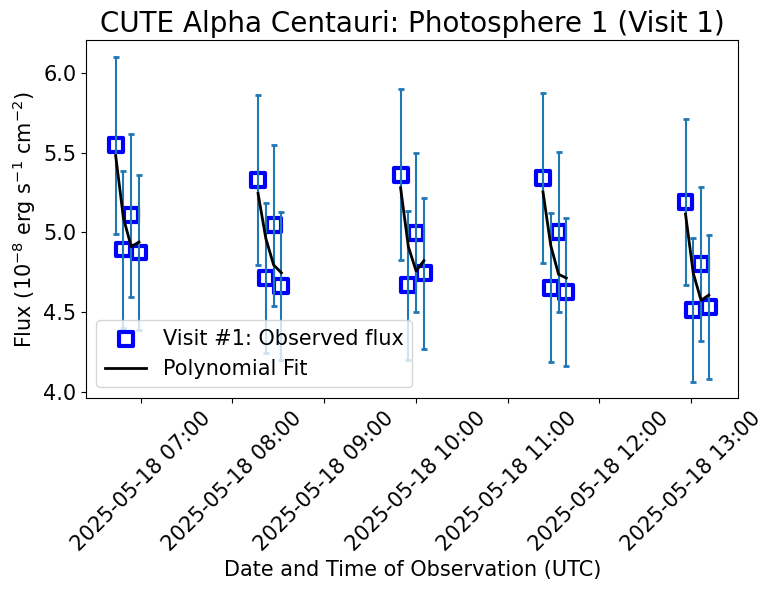

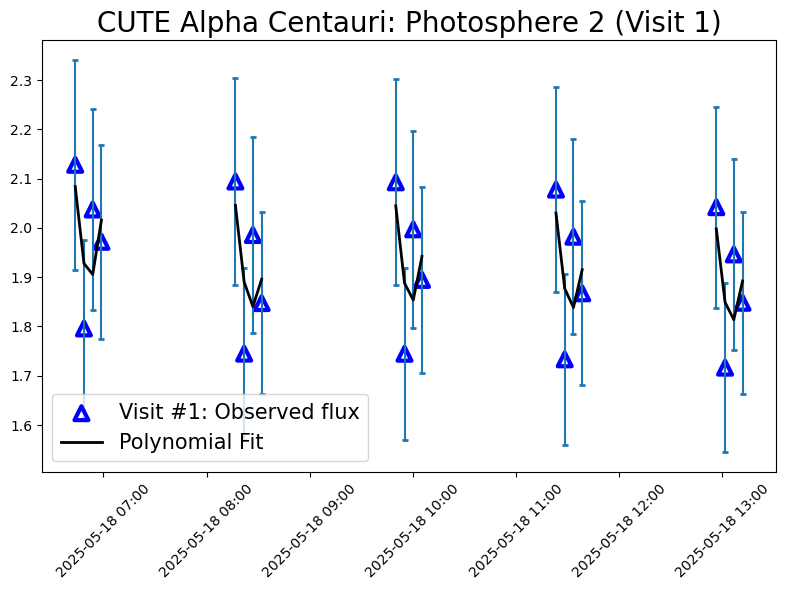

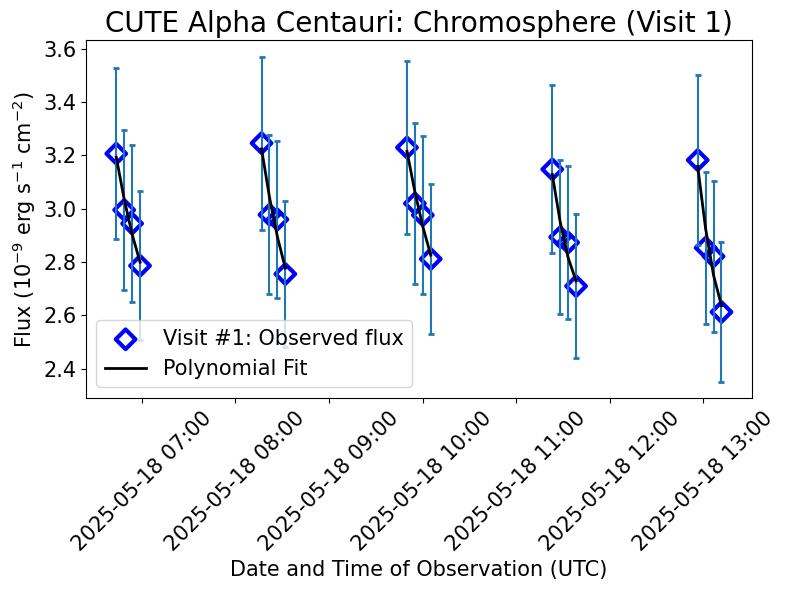

In [9]:
#Visit 1    
#Try polyfit for each visit at a time

for i in range(nfiles1):
    flux        = cute_ff1[:, i]
    ww          = cute_wavesol - 8
    ind         = np.where((ww >= 2550) & (ww <= 3255))
    fluxtot     = integrate.simpson(flux[ind], ww[ind])
    totflux1[i] = fluxtot

    ind2        = np.where((ww >= 2550) & (ww < 2790))
    fluxtot     = integrate.simpson(flux[ind2], ww[ind2])
    phot1_1[i]  = fluxtot

    ind3        = np.where((ww >= 2790) & (ww <= 2805))
    fluxtot     = integrate.simpson(flux[ind3], ww[ind3])
    chrom1[i]   = fluxtot

    ind4        = np.where((ww > 2805) & (ww <= 3255))
    fluxtot     = integrate.simpson(flux[ind4], ww[ind4])
    phot2_1[i]  = fluxtot

#Refer to Visit 1 for an explanation of the arrays and the steps
tarr11   = timearr1[0:4]
farr11   = phot1_1[0:4] 
farr112  = phot2_1[0:4]
farr113  = chrom1[0:4]
result11 = np.polyfit(tarr11, farr11, 2) 
result21 = np.polyfit(tarr11, farr112, 2)
result31 = np.polyfit(tarr11, farr113, 2)
poly11   = result11[0]*tarr11**2 + result11[1]*tarr11 + result11[2]
poly112  = result21[0]*tarr11**2 + result21[1]*tarr11 + result21[2]
poly113  = result31[0]*tarr11**2 + result31[1]*tarr11 + result31[2]
norm11   = poly11.max()
norm112  = poly112.max()
norm113  = poly113.max()
poly11   = poly11 / norm11 
poly112  = poly112 / norm112 
poly113  = poly113 / norm113 
corr11   = farr11 / poly11
corr112  = farr112 / poly112
corr113  = farr113 / poly113

tarr21   = timearr1[4:8]
farr21   = phot1_1[4:8] 
farr212  = phot2_1[4:8]
farr213  = chrom1[4:8]
result121 = np.polyfit(tarr21, farr21, 2) 
result221 = np.polyfit(tarr21, farr212, 2)
result321 = np.polyfit(tarr21, farr213, 2)
poly21   = result121[0]*tarr21**2 + result121[1]*tarr21 + result121[2]
poly212  = result221[0]*tarr21**2 + result221[1]*tarr21 + result221[2]
poly213  = result321[0]*tarr21**2 + result321[1]*tarr21 + result321[2]
norm21   = poly21.max()
norm212  = poly212.max()
norm213  = poly213.max()
poly21   = poly21 / norm21
poly212  = poly212 / norm212 
poly213  = poly213 / norm213 
corr21   = farr21 / poly21
corr212  = farr212 / poly212
corr213  = farr213 / poly213

tarr31   = timearr1[8:12]
farr31   = phot1_1[8:12] 
farr312  = phot2_1[8:12]
farr313  = chrom1[8:12]
result131 = np.polyfit(tarr31, farr31, 2)
result231 = np.polyfit(tarr31, farr312, 2)
result331 = np.polyfit(tarr31, farr313, 2) 
poly31   = result131[0]*tarr31**2 + result131[1]*tarr31 + result131[2]
poly312  = result231[0]*tarr31**2 + result231[1]*tarr31 + result231[2]
poly313  = result331[0]*tarr31**2 + result331[1]*tarr31 + result331[2]
norm31   = poly31.max()
norm312  = poly312.max()
norm313  = poly313.max()
poly31   = poly31 / norm31
poly312  = poly312 / norm312 
poly313  = poly313 / norm313 
corr31   = farr31 / poly31
corr312  = farr312 / poly312
corr313  = farr313 / poly313

tarr41   = timearr1[12:16]
farr41   = phot1_1[12:16] 
farr412  = phot2_1[12:16]
farr413  = chrom1[12:16]
result141 = np.polyfit(tarr41, farr41, 2) 
result241 = np.polyfit(tarr41, farr412, 2)
result341 = np.polyfit(tarr41, farr413, 2)
poly41   = result141[0]*tarr41**2 + result141[1]*tarr41 + result141[2]
poly412  = result241[0]*tarr41**2 + result241[1]*tarr41 + result241[2]
poly413  = result341[0]*tarr41**2 + result341[1]*tarr41 + result341[2]
norm41   = poly41.max()
norm412  = poly412.max()
norm413  = poly413.max()
poly41   = poly41 / norm41
poly412  = poly412 / norm412 
poly413  = poly413 / norm413 
corr41   = farr41 / poly41
corr412  = farr412 / poly412
corr413  = farr413 / poly413

tarr51   = timearr1[16:20]
farr51   = phot1_1[16:20]
farr512  = phot2_1[16:20]
farr513  = chrom1[16:20]
result151 = np.polyfit(tarr51, farr51, 2)
result251 = np.polyfit(tarr51, farr512, 2)
result351 = np.polyfit(tarr51, farr513, 2) 
poly51   = result151[0]*tarr51**2 + result151[1]*tarr51 + result151[2]
poly512  = result251[0]*tarr51**2 + result251[1]*tarr51 + result251[2]
poly513  = result351[0]*tarr51**2 + result351[1]*tarr51 + result351[2]
norm51   = poly51.max()
norm512  = poly512.max()
norm513  = poly513.max()
poly51   = poly51 / norm51
poly512  = poly512 / norm512 
poly513  = poly513 / norm513 
corr51   = farr51 / poly51
corr512  = farr512 / poly512
corr513  = farr513 / poly513

corflux1  = np.concatenate((corr11, corr21, corr31))
corflux12 = np.concatenate((corr112, corr212, corr312))
corflux13 = np.concatenate((corr113, corr213, corr313))
corflux1  = np.append(corflux1, corr41) 
corflux12 = np.append(corflux12, corr412)
corflux13 = np.append(corflux13, corr413) 
corflux1  = np.append(corflux1, corr51) 
corflux12 = np.append(corflux12, corr512)
corflux13 = np.append(corflux13, corr513) 

#Photosphere 1
fig, ax = plt.subplots(figsize=(8,6))
title  = 'CUTE Alpha Centauri: Photosphere 1 (Visit 1)'
ax.set_title(title, fontsize=20)
ax.tick_params(axis='both', which='major', labelsize=15) 
ax.set_xlabel('Date and Time of Observation (UTC)', fontsize=15)
ax.set_ylabel('Flux (10$^{-8}$ erg s$^{-1}$ cm$^{-2}$)', fontsize=15)
ax.scatter(dates1, phot1_1*1.e8, label='Visit #1: Observed flux', marker='s', edgecolors='blue', s=100, facecolors='none', linewidths=3)
ax.errorbar(dates1, phot1_1*1.e8, yerr=0.1*phot1_1*1.e8, linestyle='none', capthick=2, capsize=2)
ax.plot(dates1[0:4], poly11*norm11*1.e8, color='black', label='Polynomial Fit', lw=2)
ax.plot(dates1[4:8], poly21*norm21*1.e8, color='black', lw=2)
ax.plot(dates1[8:12], poly31*norm31*1.e8, color='black', lw=2)
ax.plot(dates1[12:16], poly41*norm41*1.e8, color='black', lw=2)
ax.plot(dates1[16:20], poly51*norm51*1.e8, color='black', lw=2)
date_format = mdates.DateFormatter("%Y-%m-%d %H:%M")
ax.xaxis.set_major_formatter(date_format)
plt.xticks(rotation=45)
ax.legend(fontsize=15, loc=3)
fig.tight_layout()
plt.show()

#Photosphere 2
fig, ax = plt.subplots(figsize=(8,6))
title  = 'CUTE Alpha Centauri: Photosphere 2 (Visit 1)'
ax.set_title(title, fontsize=20)
ax.scatter(dates1, phot2_1*1.e7, label='Visit #1: Observed flux', marker='^', edgecolors='blue', s=100, facecolors='none', linewidths=3)
ax.errorbar(dates1, phot2_1*1.e7, yerr=0.1*phot2_1*1.e7, linestyle='none', capthick=2, capsize=2)
ax.plot(dates1[0:4], poly112*norm112*1.e7, color='black', label='Polynomial Fit', lw=2)
ax.plot(dates1[4:8], poly212*norm212*1.e7, color='black', lw=2)
ax.plot(dates1[8:12], poly312*norm312*1.e7, color='black', lw=2)
ax.plot(dates1[12:16], poly412*norm412*1.e7, color='black', lw=2)
ax.plot(dates1[16:20], poly512*norm512*1.e7, color='black', lw=2)
ax.xaxis.set_major_formatter(date_format)
plt.xticks(rotation=45)
ax.legend(fontsize=15, loc=3)
fig.tight_layout()
plt.show()

#Chromosphere
fig, ax = plt.subplots(figsize=(8,6))
title  = 'CUTE Alpha Centauri: Chromosphere (Visit 1)'
ax.set_title(title, fontsize=20)
ax.tick_params(axis='both', which='major', labelsize=15) 
ax.set_xlabel('Date and Time of Observation (UTC)', fontsize=15)
ax.set_ylabel('Flux (10$^{-9}$ erg s$^{-1}$ cm$^{-2}$)', fontsize=15)
ax.scatter(dates1, chrom1*1.e9, label='Visit #1: Observed flux', marker='D', edgecolors='blue', s=100, facecolors='none', linewidths=3)
ax.errorbar(dates1, chrom1*1.e9, yerr=0.1*chrom1*1.e9, linestyle='none', capthick=2, capsize=2)
ax.plot(dates1[0:4], poly113*norm113*1.e9, color='black', label='Polynomial Fit', lw=2)
ax.plot(dates1[4:8], poly213*norm213*1.e9, color='black', lw=2)
ax.plot(dates1[8:12], poly313*norm313*1.e9, color='black', lw=2)
ax.plot(dates1[12:16], poly413*norm413*1.e9, color='black', lw=2)
ax.plot(dates1[16:20], poly513*norm513*1.e9, color='black', lw=2)
ax.xaxis.set_major_formatter(date_format)
plt.xticks(rotation=45)
ax.legend(fontsize=15, loc=3)
fig.tight_layout()
plt.show()


# Visit 2

In [10]:
# #Visit 1    
# #Try polyfit for each visit at a time
# for i in range(nfiles2):
#     flux           = cute_ff2[:,i]
#     ww             = cute_wavesol-8
#     ind            = np.where((ww >= 2550) & (ww <= 3255))
#     fluxtot        = integrate.simpson(flux[ind],ww[ind])
#     totflux1[i]    = fluxtot
#     ind2           = np.where((ww >= 2550) & (ww < 2790))
#     fluxtot        = integrate.simpson(flux[ind2],ww[ind2])
#     phot1_2[i]     = fluxtot
#     flux1          = cute_ff2_sigup[:,i]
#     phot1_2sigup[i]= integrate.simpson(flux1[ind2],ww[ind2]) - fluxtot
#     flux2          = cute_ff4_sigdn[:,i]
#     phot1_2sigdn[i]= fluxtot - integrate.simpson(flux2[ind2],ww[ind2])
#     ind3           = np.where((ww >= 2790) & (ww <= 2805))
#     fluxtot        = integrate.simpson(flux[ind3],ww[ind3])
#     chrom2[i]      = fluxtot
#     chrom2_sigup[i]= integrate.simpson(flux1[ind3],ww[ind3]) - fluxtot
#     chrom2_sigdn[i]= fluxtot - integrate.simpson(flux2[ind3],ww[ind3])
#     ind1           = np.where((ww > 2805) & (ww <= 3255))
#     fluxtot        = integrate.simpson(flux[ind4],ww[ind4])
#     phot2_2[i]     = fluxtot
#     phot2_2sigup[i]= integrate.simpson(flux1[ind4],ww[ind4]) - fluxtot
#     phot2_2sigdn[i]= fluxtot - integrate.simpson(flux1[ind4],ww[ind4])

# #This is orbit 1
# tarr12   = timearr2[0:4]
# farr12   = phot1_2[0:4]           #This is photosphere 1
# farr122  = phot2_2[0:4]           #This is photosphere 2
# farr123  = chrom1[0:4]            #This is the chromosphere
# result12 = np.polyfit(tarr12,farr12,2)   #Get the polynomial parameters to best-fit the data
# result22 = np.polyfit(tarr12,farr122,2)
# result32 = np.polyfit(tarr12,farr123,2)
# poly12   = result12[0]*tarr12**2 + result12[1]*tarr12 + result12[2] #Create the polynomial that fits the data best
# poly122  = result22[0]*tarr12**2 + result22[1]*tarr12 + result22[2]
# poly123  = result32[0]*tarr12**2 + result32[1]*tarr12 + result32[2]
# norm12   = poly12.max()     #Get the max value of the function
# norm122  = poly122.max()    
# norm123  = poly123.max()
# poly12   = poly12/norm12    #Divide the polynomial by the max value to normalize it
# poly122  = poly122/norm122 
# poly123  = poly123/norm123 
# corr12   = farr12/poly12     #Apply the correction to the orbit by dividing it with the normalized polynomial function
# corr122  = farr122/poly122
# corr123  = farr123/poly123

# #This is orbit 2
# tarr22  = timearr2[4:8]
# farr22  = phot1_2[4:8] 
# farr222 = phot2_2[4:8]
# farr223 = chrom2[4:8]
# result12 = np.polyfit(tarr22,farr22,2) 
# result22 = np.polyfit(tarr22,farr222,2)
# result32 = np.polyfit(tarr22,farr223,2)
# poly22  = result12[0]*tarr22**2 + result12[1]*tarr22 + result12[2]
# poly222 = result22[0]*tarr22**2 + result22[1]*tarr22 + result22[2]
# poly223 = result32[0]*tarr22**2 + result32[1]*tarr22 + result32[2]
# norm21  = poly22.max()
# norm222 = poly222.max()
# norm223 = poly223.max()
# poly22  = poly22/norm21
# poly222 = poly222/norm222 
# poly223 = poly223/norm223 
# corr22  = farr22/poly22
# corr222 = farr222/poly222
# corr223 = farr223/poly223

# #This is orbit 3 which has only one exposure
# tarr32  = timearr2[8:12]
# farr32  = phot1_2[8:12] 
# farr322 = phot2_2[8:12]
# farr323 = chrom2[8:12]
# result12 = np.polyfit(tarr32,farr32,2) 
# result22 = np.polyfit(tarr32,farr322,2)
# result32 = np.polyfit(tarr32,farr323,2)
# poly32  = result12[0]*tarr32**2 + result12[1]*tarr32 + result12[2]
# poly322 = result22[0]*tarr32**2 + result22[1]*tarr32 + result22[2]
# poly323 = result32[0]*tarr32**2 + result32[1]*tarr32 + result32[2]
# norm31  = poly32.max()
# norm322 = poly322.max()
# norm323 = poly323.max()
# poly32  = poly32/norm31
# poly322 = poly322/norm322 
# poly323 = poly323/norm323 
# corr32  = farr32/poly32
# corr322 = farr322/poly322
# corr323 = farr323/poly323


# #This is orbit 4
# tarr42  = timearr4[12:16]
# farr42  = phot1_4[12:16] 
# farr422 = phot2_4[12:16]
# farr423 = chrom4[12:16]
# result12 = np.polyfit(tarr42,farr42,1) 
# result22 = np.polyfit(tarr42,farr422,1)
# result32 = np.polyfit(tarr42,farr423,1)
# #poly44  = result14[0]*tarr44**2 + result14[1]*tarr44 + result14[2]
# #poly442 = result24[0]*tarr44**2 + result24[1]*tarr44 + result24[2]
# #poly443 = result34[0]*tarr44**2 + result34[1]*tarr44 + result34[2]
# poly42   = result12[0]*tarr42 + result12[1]
# poly422  = result22[0]*tarr42 + result22[1]
# poly423  = result32[0]*tarr42 + result32[1]
# norm42  = poly42.max()
# norm422 = poly422.max()
# norm423 = poly423.max()
# poly42  = poly42/norm42
# poly422 = poly422/norm422 
# poly423 = poly423/norm423 
# corr42  = farr42/poly42
# corr422 = farr422/poly422
# corr423 = farr423/poly423

# #This is orbit 5 which also has one exposure
# tarr52  = timearr2[16:20]
# farr52  = phot1_2[16:20] 
# farr522 = phot2_2[16:20]
# farr523 = chrom2[16:20]
# result12 = np.polyfit(tarr52,farr52,2) 
# result22 = np.polyfit(tarr52,farr522,2)
# result32 = np.polyfit(tarr52,farr523,2)
# poly52  = result12[0]*tarr52**2 + result12[1]*tarr52 + result12[2]
# poly522 = result22[0]*tarr52**2 + result22[1]*tarr52 + result22[2]
# poly523 = result32[0]*tarr52**2 + result32[1]*tarr52 + result32[2]
# norm51  = poly52.max()
# norm522 = poly522.max()
# norm523 = poly523.max()
# poly52  = poly52/norm51
# poly522 = poly522/norm522 
# poly523 = poly523/norm523 
# corr52  = farr52/poly52
# corr522 = farr522/poly522
# corr523 = farr523/poly523


# corflux2  = np.concatenate((corr15,corr25,corr35))
# corflux22 = np.concatenate((corr152,corr252,corr352))
# corflux23 = np.concatenate((corr153,corr253,corr353))
# corflux2  = np.append(corflux5,corr45) 
# corflux2  = np.append(corflux5,corr55) 

# corflux22 = np.append(corflux52,corr452)
# corflux22 = np.append(corflux52,corr552)

# corflux22 = np.append(corflux52,phot2_5)
# corflux23 = np.append(corflux53,corr453) 
# corflux23 = np.append(corflux53,corr553) 
 
# corflux53 = np.append(corflux53,chrom5)# Photosphere 1
# # #Plot the uncorrected vs corrected flux for all orbits in visit 5
# y_err = [phot1_5sigdn*1.E8,phot1_5sigup*1.E8]
# fig,ax = plt.subplots(figsize=(8,6))
# title  = 'CUTE Alpha Centauri: Photosphere 1'
# ax.set_title(title,fontsize=20)
# ax.tick_params(axis='both', which='major', labelsize=15) 
# ax.set_xlabel('Date and Time of Observation (UTC)',fontsize=15)
# ax.set_ylabel('Flux (10$^{-8}$ erg s$^{-1}$ cm$^{-2}$)',fontsize=15)
# # # ax.set_ylim(0,7)
# ax.scatter(dates2,phot1_2*1.e7, label='Visit #5: Observed flux', marker='s',edgecolors='magenta',s=50,facecolors='none',linewidths=3)
# ax.errorbar(dates2,phot1_2*1.e7, yerr=0.1*phot1_5*1.E8,linestyle='none',capthick=2,capsize=2)
# ax.plot(dates2[0:4], poly12*norm12*1.e7, color='black', label='Polynomial Fit',lw=4)
# ax.plot(dates2[4:8], poly22*norm222*1.e7, color='black',lw=4)
# ax.plot(dates2[8:12], poly32*norm322*1.e7, color='black',lw=4)
# ax.plot(dates2[12:16], poly42*norm422*1.e7, color='black',lw=4)
# ax.plot(dates2[16:20], poly52*norm522*1.e7, color='black',lw=4)
# # ax.scatter(dates5,corflux5*1.3*1.e7, label='Corrected Flux x 1.3', marker='s',edgecolors='cyan',s=50,facecolors='none',linewidths=3)
# # ax.errorbar(dates5,corflux5*1.3*1.e7, yerr=0.1*corflux5*1.3*1.E8,linestyle='none',capthick=2,capsize=2)
# # # Format x-axis
# date_format = mdates.DateFormatter("%Y-%m-%d %H:%M")  # Customize format as needed
# ax.xaxis.set_major_formatter(date_format)
# plt.xticks(rotation=45)  # Rotate labels if needed
# ax.legend(fontsize=15,loc=3)
# # fig.tight_layout()
# # figname='Phot1_fluxCUTE_visit5_polyfit.jpeg'
# # # plt.savefig(figname,format='jpeg',dpi=200)
# # #plt.show()

# # print(len(dates5))
# # print(len(corflux5))

# len(poly353)

# #Photosphere 2
# #Plot the uncorrected vs corrected flux for all orbits in visit 5
# fig,ax = plt.subplots(figsize=(8,6))
# title  = 'CUTE Alpha Centauri: Photosphere 2'
# ax.set_title(title,fontsize=20)
# ax.tick_params(axis='both', which='major', labelsize=15) 
# ax.set_xlabel('Date and Time of Observation (UTC)',fontsize=15)
# ax.set_ylabel('Flux (10$^{-7}$ erg s$^{-1}$ cm$^{-2}$)',fontsize=15)
# # ax.set_ylim(0,3.0)
# ax.scatter(dates2,phot2_2*1.e7, label='Visit #5: Observed flux', marker='^',edgecolors='magenta',s=100,facecolors='none',linewidths=3)
# ax.errorbar(dates2,phot2_2*1.e7, yerr=0.1*phot2_5*1.E7,linestyle='none',capthick=2,capsize=2)
# ax.plot(dates2[0:4], poly12*norm152*1.e7, color='black', label='Polynomial Fit',lw=4)
# ax.plot(dates2[4:8], poly222*norm252*1.e7, color='black',lw=4)
# ax.plot(dates2[8:12], poly322*norm352*1.e7, color='black',lw=4)
# ax.plot(dates2[12:16], poly422*norm452*1.e7, color='black',lw=4)
# ax.plot(dates2[16:20], poly522*norm552*1.e7, color='black',lw=4)
# # ax.plot(dates5[19:23], poly652*norm652*1.e7, color='black',lw=4)
# # ax.plot(dates5[23:27], poly752*norm752*1.e7, color='black',lw=4)
# # ax.scatter(dates5,corflux52*1.3*1.e7, label='Corrected Flux x 1.3', marker='^',edgecolors='cyan',s=100,facecolors='none',linewidths=3)
# # ax.errorbar(dates5,corflux52*1.3*1.e7, yerr=0.1*corflux52*1.3*1.E7,linestyle='none',capthick=2,capsize=2)
# # Format x-axis
# date_format = mdates.DateFormatter("%Y-%m-%d %H:%M")  # Customize format as needed
# ax.xaxis.set_major_formatter(date_format)
# plt.xticks(rotation=45)  # Rotate labels if needed
# ax.legend(fontsize=15,loc=3)
# fig.tight_layout()
# # figname='/Users/dobh6980/Projects/Kevin_projects/CUTE/Alpha_Cen/plots/visit5_fit/Phot2_fluxCUTE_visit5_polyfit_werr2.jpeg'
# # plt.savefig(figname,format='jpeg',dpi=200)
# plt.show()


# #Chromosphere
# fig,ax = plt.subplots(figsize=(8,6))
# title  = 'CUTE Alpha Centauri: Chromosphere'
# ax.set_title(title,fontsize=20)
# ax.tick_params(axis='both', which='major', labelsize=15) 
# ax.set_xlabel('Date and Time of Observation (UTC)',fontsize=15)
# ax.set_ylabel('Flux (10$^{-9}$ erg s$^{-1}$ cm$^{-2}$)',fontsize=15)
# # ax.set_ylim(0,3.0)
# ax.scatter(dates5,chrom5*1.e9, label='Visit #5: Observed flux', marker='D',edgecolors='magenta',s=100,facecolors='none',linewidths=3)
# ax.errorbar(dates5,chrom5*1.e9, yerr=0.1*chrom5*1.E9,linestyle='none',capthick=2,capsize=2)
# ax.plot(dates2[0:4], poly123*norm123*1.e9, color='black', label='Polynomial Fit',lw=4)
# ax.plot(dates2[4:8], poly223*norm223*1.e9, color='black',lw=4)
# ax.plot(dates2[8:12], poly323*norm323*1.e9, color='black',lw=4)
# ax.plot(dates2[12:16], poly423*norm423*1.e9, color='black',lw=4)
# ax.plot(dates2[16:20], poly523*norm523*1.e9, color='black',lw=4)
# # ax.plot(dates5[19:23], poly653*norm653*1.e9, color='black',lw=4)
# # ax.plot(dates5[23:27], poly753*norm753*1.e9, color='black',lw=4)
# # ax.scatter(dates5,corflux53*1.3*1.e9, label='Corrected Flux x 1.3', marker='D',edgecolors='cyan',s=100,facecolors='none',linewidths=3)
# # ax.errorbar(dates5,corflux53*1.3*1.e9, yerr=0.1*corflux53*1.3*1.E9,linestyle='none',capthick=2,capsize=2)
# # Format x-axis
# date_format = mdates.DateFormatter("%Y-%m-%d %H:%M")  # Customize format as needed
# ax.xaxis.set_major_formatter(date_format)
# plt.xticks(rotation=45)  # Rotate labels if needed
# ax.legend(fontsize=15,loc=3)
# fig.tight_layout()
# # figname='/Users/dobh6980/Projects/Kevin_projects/CUTE/Alpha_Cen/plots/visit5_fit/Chrom_fluxCUTE_visit5_polyfit_werr2.jpeg'
# # plt.savefig(figname,format='jpeg',dpi=200)
# plt.show()




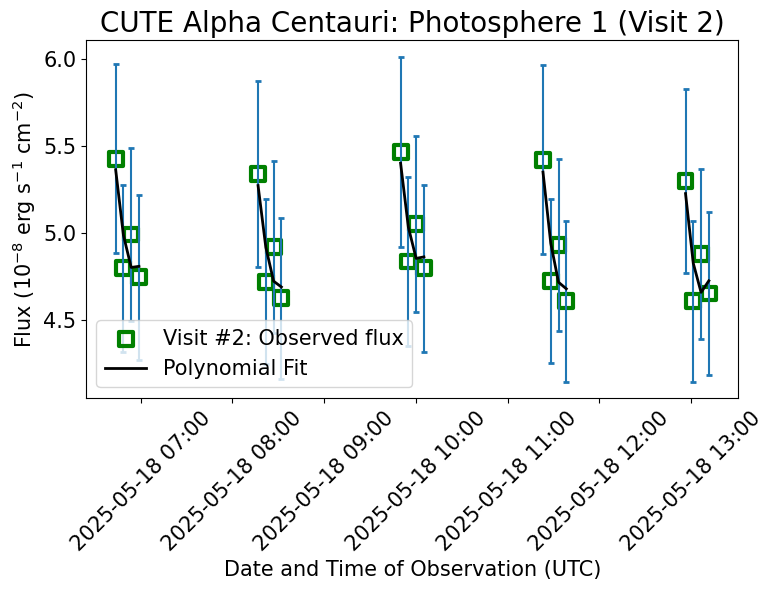

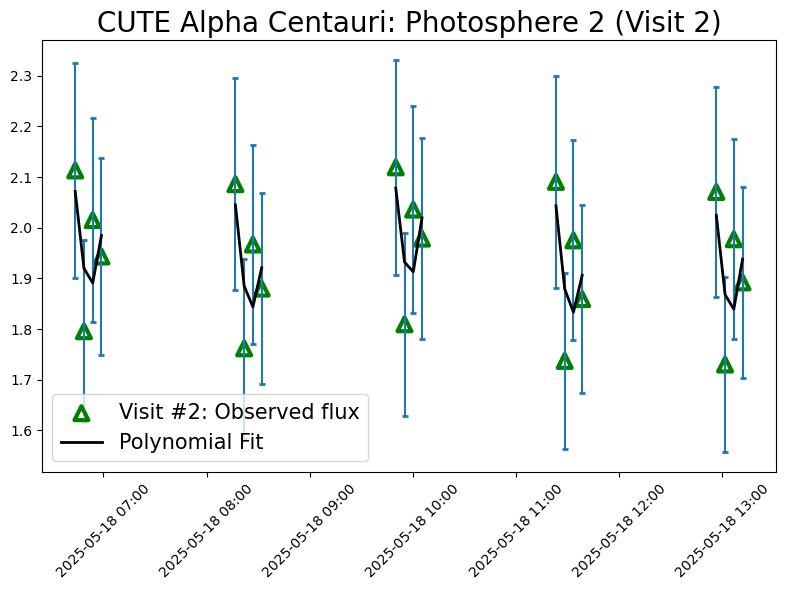

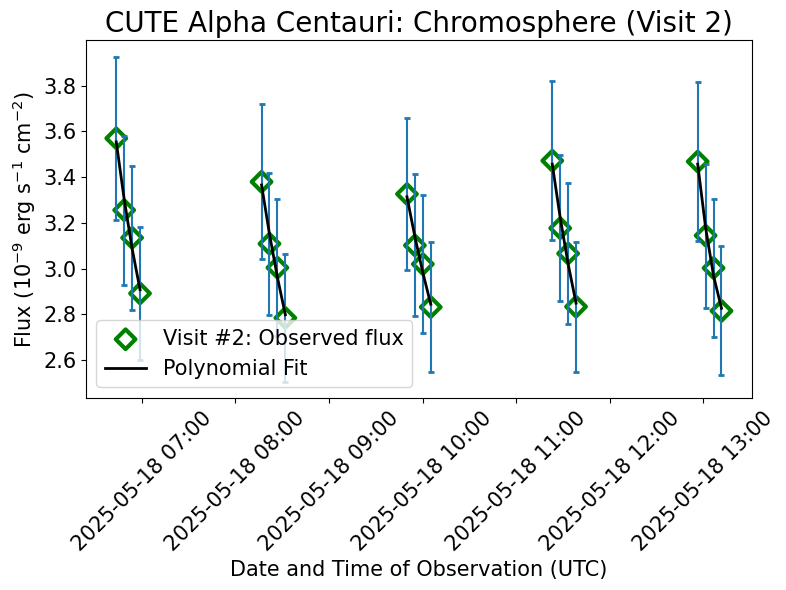

In [11]:
#Visit 2    
#Try polyfit for each visit at a time

for i in range(nfiles2):
    flux        = cute_ff2[:, i]
    ww          = cute_wavesol - 9
    ind         = np.where((ww >= 2550) & (ww <= 3255))
    fluxtot     = integrate.simpson(flux[ind], ww[ind])
    totflux2[i] = fluxtot

    ind2        = np.where((ww >= 2550) & (ww < 2790))
    fluxtot     = integrate.simpson(flux[ind2], ww[ind2])
    phot1_2[i]  = fluxtot

    ind3        = np.where((ww >= 2790) & (ww <= 2805))
    fluxtot     = integrate.simpson(flux[ind3], ww[ind3])
    chrom2[i]   = fluxtot

    ind4        = np.where((ww > 2805) & (ww <= 3255))
    fluxtot     = integrate.simpson(flux[ind4], ww[ind4])
    phot2_2[i]  = fluxtot

#Refer to Visit 2 for an explanation of the arrays and the steps
tarr12   = timearr2[0:4]
farr12   = phot1_2[0:4] 
farr122  = phot2_2[0:4]
farr123  = chrom2[0:4]
result12 = np.polyfit(tarr12, farr12, 2) 
result22 = np.polyfit(tarr12, farr122, 2)
result32 = np.polyfit(tarr12, farr123, 2)
poly12   = result12[0]*tarr12**2 + result12[1]*tarr12 + result12[2]
poly122  = result22[0]*tarr12**2 + result22[1]*tarr12 + result22[2]
poly123  = result32[0]*tarr12**2 + result32[1]*tarr12 + result32[2]
norm12   = poly12.max()
norm122  = poly122.max()
norm123  = poly123.max()
poly12   = poly12 / norm12 
poly122  = poly122 / norm122 
poly123  = poly123 / norm123 
corr12   = farr12 / poly12
corr122  = farr122 / poly122
corr123  = farr123 / poly123

tarr22   = timearr2[4:8]
farr22   = phot1_2[4:8] 
farr222  = phot2_2[4:8]
farr223  = chrom2[4:8]
result1222 = np.polyfit(tarr22, farr22, 2) 
result2222 = np.polyfit(tarr22, farr222, 2)
result3222 = np.polyfit(tarr22, farr223, 2)
poly22   = result1222[0]*tarr22**2 + result1222[1]*tarr22 + result1222[2]
poly222  = result2222[0]*tarr22**2 + result2222[1]*tarr22 + result2222[2]
poly223  = result3222[0]*tarr22**2 + result3222[1]*tarr22 + result3222[2]
norm22   = poly22.max()
norm222  = poly222.max()
norm223  = poly223.max()
poly22   = poly22 / norm22
poly222  = poly222 / norm222 
poly223  = poly223 / norm223 
corr22   = farr22 / poly22
corr222  = farr222 / poly222
corr223  = farr223 / poly223

tarr32   = timearr2[8:12]
farr32   = phot1_2[8:12] 
farr322  = phot2_2[8:12]
farr323  = chrom2[8:12]
result132 = np.polyfit(tarr32, farr32, 2)
result232 = np.polyfit(tarr32, farr322, 2)
result332 = np.polyfit(tarr32, farr323, 2) 
poly32   = result132[0]*tarr32**2 + result132[1]*tarr32 + result132[2]
poly322  = result232[0]*tarr32**2 + result232[1]*tarr32 + result232[2]
poly323  = result332[0]*tarr32**2 + result332[1]*tarr32 + result332[2]
norm32   = poly32.max()
norm322  = poly322.max()
norm323  = poly323.max()
poly32   = poly32 / norm32
poly322  = poly322 / norm322 
poly323  = poly323 / norm323 
corr32   = farr32 / poly32
corr322  = farr322 / poly322
corr323  = farr323 / poly323

tarr42   = timearr2[12:16]
farr42   = phot1_2[12:16] 
farr422  = phot2_2[12:16]
farr423  = chrom2[12:16]
result142 = np.polyfit(tarr42, farr42, 2) 
result242 = np.polyfit(tarr42, farr422, 2)
result342 = np.polyfit(tarr42, farr423, 2)
poly42   = result142[0]*tarr42**2 + result142[1]*tarr42 + result142[2]
poly422  = result242[0]*tarr42**2 + result242[1]*tarr42 + result242[2]
poly423  = result342[0]*tarr42**2 + result342[1]*tarr42 + result342[2]
norm42   = poly42.max()
norm422  = poly422.max()
norm423  = poly423.max()
poly42   = poly42 / norm42
poly422  = poly422 / norm422 
poly423  = poly423 / norm423 
corr42   = farr42 / poly42
corr422  = farr422 / poly422
corr423  = farr423 / poly423

tarr52   = timearr2[16:20]
farr52   = phot1_2[16:20]
farr522  = phot2_2[16:20]
farr523  = chrom2[16:20]
result152 = np.polyfit(tarr52, farr52, 2)
result252 = np.polyfit(tarr52, farr522, 2)
result352 = np.polyfit(tarr52, farr523, 2) 
poly52   = result152[0]*tarr52**2 + result152[1]*tarr52 + result152[2]
poly522  = result252[0]*tarr52**2 + result252[1]*tarr52 + result252[2]
poly523  = result352[0]*tarr52**2 + result352[1]*tarr52 + result352[2]
norm52   = poly52.max()
norm522  = poly522.max()
norm523  = poly523.max()
poly52   = poly52 / norm52
poly522  = poly522 / norm522 
poly523  = poly523 / norm523 
corr52   = farr52 / poly52
corr522  = farr522 / poly522
corr523  = farr523 / poly523

corflux2  = np.concatenate((corr12, corr22, corr32))
corflux22 = np.concatenate((corr122, corr222, corr322))
corflux23 = np.concatenate((corr123, corr223, corr323))
corflux2  = np.append(corflux2, corr42) 
corflux22 = np.append(corflux22, corr422)
corflux23 = np.append(corflux23, corr423) 
corflux2  = np.append(corflux2, corr52) 
corflux22 = np.append(corflux22, corr522)
corflux23 = np.append(corflux23, corr523) 

#Photosphere 1
fig, ax = plt.subplots(figsize=(8,6))
title  = 'CUTE Alpha Centauri: Photosphere 1 (Visit 2)'
ax.set_title(title, fontsize=20)
ax.tick_params(axis='both', which='major', labelsize=15) 
ax.set_xlabel('Date and Time of Observation (UTC)', fontsize=15)
ax.set_ylabel('Flux (10$^{-8}$ erg s$^{-1}$ cm$^{-2}$)', fontsize=15)
ax.scatter(dates2, phot1_2*1.e8, label='Visit #2: Observed flux', marker='s', edgecolors='green', s=100, facecolors='none', linewidths=3)
ax.errorbar(dates2, phot1_2*1.e8, yerr=0.1*phot1_2*1.e8, linestyle='none', capthick=2, capsize=2)
ax.plot(dates2[0:4], poly12*norm12*1.e8, color='black', label='Polynomial Fit', lw=2)
ax.plot(dates2[4:8], poly22*norm22*1.e8, color='black', lw=2)
ax.plot(dates2[8:12], poly32*norm32*1.e8, color='black', lw=2)
ax.plot(dates2[12:16], poly42*norm42*1.e8, color='black', lw=2)
ax.plot(dates2[16:20], poly52*norm52*1.e8, color='black', lw=2)
date_format = mdates.DateFormatter("%Y-%m-%d %H:%M")
ax.xaxis.set_major_formatter(date_format)
plt.xticks(rotation=45)
ax.legend(fontsize=15, loc=3)
fig.tight_layout()
plt.show()

#Photosphere 2
fig, ax = plt.subplots(figsize=(8,6))
title  = 'CUTE Alpha Centauri: Photosphere 2 (Visit 2)'
ax.set_title(title, fontsize=20)
ax.scatter(dates2, phot2_2*1.e7, label='Visit #2: Observed flux', marker='^', edgecolors='green', s=100, facecolors='none', linewidths=3)
ax.errorbar(dates2, phot2_2*1.e7, yerr=0.1*phot2_2*1.e7, linestyle='none', capthick=2, capsize=2)
ax.plot(dates2[0:4], poly122*norm122*1.e7, color='black', label='Polynomial Fit', lw=2)
ax.plot(dates2[4:8], poly222*norm222*1.e7, color='black', lw=2)
ax.plot(dates2[8:12], poly322*norm322*1.e7, color='black', lw=2)
ax.plot(dates2[12:16], poly422*norm422*1.e7, color='black', lw=2)
ax.plot(dates2[16:20], poly522*norm522*1.e7, color='black', lw=2)
ax.xaxis.set_major_formatter(date_format)
plt.xticks(rotation=45)
ax.legend(fontsize=15, loc=3)
fig.tight_layout()
plt.show()

#Chromosphere
fig, ax = plt.subplots(figsize=(8,6))
title  = 'CUTE Alpha Centauri: Chromosphere (Visit 2)'
ax.set_title(title, fontsize=20)
ax.tick_params(axis='both', which='major', labelsize=15) 
ax.set_xlabel('Date and Time of Observation (UTC)', fontsize=15)
ax.set_ylabel('Flux (10$^{-9}$ erg s$^{-1}$ cm$^{-2}$)', fontsize=15)
ax.scatter(dates2, chrom2*1.e9, label='Visit #2: Observed flux', marker='D', edgecolors='green', s=100, facecolors='none', linewidths=3)
ax.errorbar(dates2, chrom2*1.e9, yerr=0.1*chrom2*1.e9, linestyle='none', capthick=2, capsize=2)
ax.plot(dates2[0:4], poly123*norm123*1.e9, color='black', label='Polynomial Fit', lw=2)
ax.plot(dates2[4:8], poly223*norm223*1.e9, color='black', lw=2)
ax.plot(dates2[8:12], poly323*norm323*1.e9, color='black', lw=2)
ax.plot(dates2[12:16], poly423*norm423*1.e9, color='black', lw=2)
ax.plot(dates2[16:20], poly523*norm523*1.e9, color='black', lw=2)
ax.xaxis.set_major_formatter(date_format)
plt.xticks(rotation=45)
ax.legend(fontsize=15, loc=3)
fig.tight_layout()
plt.show()


# My mental buffer

# Visit 3

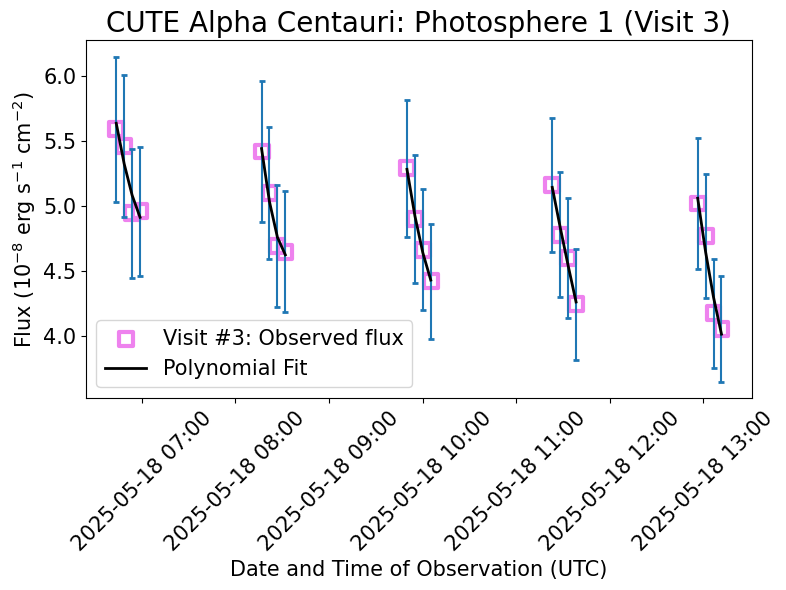

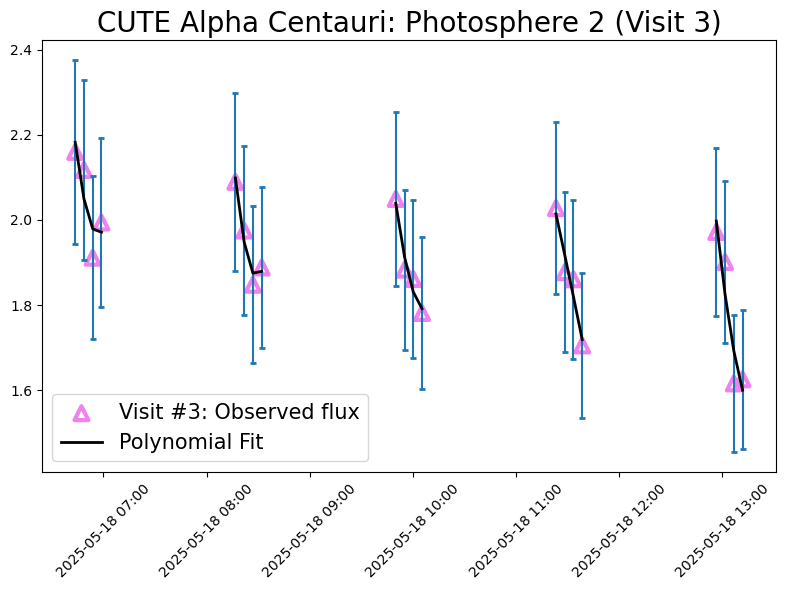

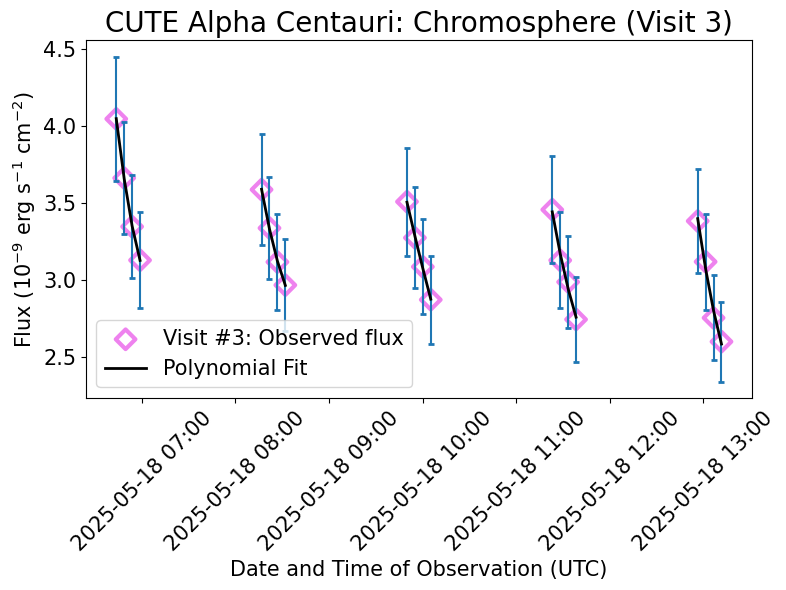

In [12]:
#Visit 3    
#Try polyfit for each visit at a time

for i in range(nfiles3):
    flux        = cute_ff3[:, i]
    ww          = cute_wavesol - 9
    ind         = np.where((ww >= 2550) & (ww <= 3255))
    fluxtot     = integrate.simpson(flux[ind], ww[ind])
    totflux3[i] = fluxtot

    ind2        = np.where((ww >= 2550) & (ww < 2790))
    fluxtot     = integrate.simpson(flux[ind2], ww[ind2])
    phot1_3[i]  = fluxtot

    ind3        = np.where((ww >= 2790) & (ww <= 2805))
    fluxtot     = integrate.simpson(flux[ind3], ww[ind3])
    chrom3[i]   = fluxtot

    ind4        = np.where((ww > 2805) & (ww <= 3255))
    fluxtot     = integrate.simpson(flux[ind4], ww[ind4])
    phot2_3[i]  = fluxtot

#Refer to Visit 3 for an explanation of the arrays and the steps
tarr13   = timearr3[0:4]
farr13   = phot1_3[0:4] 
farr132  = phot2_3[0:4]
farr133  = chrom3[0:4]
result13 = np.polyfit(tarr13, farr13, 2) 
result23 = np.polyfit(tarr13, farr132, 2)
result33 = np.polyfit(tarr13, farr133, 2)
poly13   = result13[0]*tarr13**2 + result13[1]*tarr13 + result13[2]
poly132  = result23[0]*tarr13**2 + result23[1]*tarr13 + result23[2]
poly133  = result33[0]*tarr13**2 + result33[1]*tarr13 + result33[2]
norm13   = poly13.max()
norm132  = poly132.max()
norm133  = poly133.max()
poly13   = poly13 / norm13 
poly132  = poly132 / norm132 
poly133  = poly133 / norm133 
corr13   = farr13 / poly13
corr132  = farr132 / poly132
corr133  = farr133 / poly133

tarr23   = timearr3[4:8]
farr23   = phot1_3[4:8] 
farr232  = phot2_3[4:8]
farr233  = chrom3[4:8]
result123 = np.polyfit(tarr23, farr23, 2) 
result223 = np.polyfit(tarr23, farr232, 2)
result323 = np.polyfit(tarr23, farr233, 2)
poly23   = result123[0]*tarr23**2 + result123[1]*tarr23 + result123[2]
poly232  = result223[0]*tarr23**2 + result223[1]*tarr23 + result223[2]
poly233  = result323[0]*tarr23**2 + result323[1]*tarr23 + result323[2]
norm23   = poly23.max()
norm232  = poly232.max()
norm233  = poly233.max()
poly23   = poly23 / norm23
poly232  = poly232 / norm232 
poly233  = poly233 / norm233 
corr23   = farr23 / poly23
corr232  = farr232 / poly232
corr233   = farr233 / poly233

tarr33   = timearr3[8:12]
farr33   = phot1_3[8:12] 
farr332  = phot2_3[8:12]
farr333  = chrom3[8:12]
result133 = np.polyfit(tarr33, farr33, 2)
result233 = np.polyfit(tarr33, farr332, 2)
result333 = np.polyfit(tarr33, farr333, 2) 
poly33   = result133[0]*tarr33**2 + result133[1]*tarr33 + result133[2]
poly332  = result233[0]*tarr33**2 + result233[1]*tarr33 + result233[2]
poly333  = result333[0]*tarr33**2 + result333[1]*tarr33 + result333[2]
norm33   = poly33.max()
norm332  = poly332.max()
norm333  = poly333.max()
poly33   = poly33 / norm33
poly332  = poly332 / norm332 
poly333  = poly333 / norm333 
corr33   = farr33 / poly33
corr332  = farr332 / poly332
corr333  = farr333 / poly333

tarr43   = timearr3[12:16]
farr43   = phot1_3[12:16] 
farr432  = phot2_3[12:16]
farr433  = chrom3[12:16]
result143 = np.polyfit(tarr43, farr43, 2) 
result243 = np.polyfit(tarr43, farr432, 2)
result343 = np.polyfit(tarr43, farr433, 2)
poly43   = result143[0]*tarr43**2 + result143[1]*tarr43 + result143[2]
poly432  = result243[0]*tarr43**2 + result243[1]*tarr43 + result243[2]
poly433  = result343[0]*tarr43**2 + result343[1]*tarr43 + result343[2]
norm43   = poly43.max()
norm432  = poly432.max()
norm433  = poly433.max()
poly43   = poly43 / norm43
poly432  = poly432 / norm432 
poly433  = poly433 / norm433 
corr43   = farr43 / poly43
corr432  = farr432 / poly432
corr433  = farr433 / poly433

tarr53   = timearr3[16:20]
farr53   = phot1_3[16:20]
farr532  = phot2_3[16:20]
farr533  = chrom3[16:20]
result153 = np.polyfit(tarr53, farr53, 2)
result253 = np.polyfit(tarr53, farr532, 2)
result353 = np.polyfit(tarr53, farr533, 2) 
poly53   = result153[0]*tarr53**2 + result153[1]*tarr53 + result153[2]
poly532  = result253[0]*tarr53**2 + result253[1]*tarr53 + result253[2]
poly533  = result353[0]*tarr53**2 + result353[1]*tarr53 + result353[2]
norm53   = poly53.max()
norm532  = poly532.max()
norm533  = poly533.max()
poly53   = poly53 / norm53
poly532  = poly532 / norm532 
poly533  = poly533 / norm533 
corr53   = farr53 / poly53
corr532  = farr532 / poly532
corr533  = farr533 / poly533

corflux3  = np.concatenate((corr13, corr23, corr33))
corflux32 = np.concatenate((corr132, corr232, corr332))
corflux33 = np.concatenate((corr133, corr233, corr333))
corflux3  = np.append(corflux3, corr43) 
corflux32 = np.append(corflux32, corr432)
corflux33 = np.append(corflux33, corr433) 
corflux3  = np.append(corflux3, corr53) 
corflux32 = np.append(corflux32, corr532)
corflux33 = np.append(corflux33, corr533) 

#Photosphere 1
fig, ax = plt.subplots(figsize=(8,6))
title  = 'CUTE Alpha Centauri: Photosphere 1 (Visit 3)'
ax.set_title(title, fontsize=20)
ax.tick_params(axis='both', which='major', labelsize=15) 
ax.set_xlabel('Date and Time of Observation (UTC)', fontsize=15)
ax.set_ylabel('Flux (10$^{-8}$ erg s$^{-1}$ cm$^{-2}$)', fontsize=15)
ax.scatter(dates3, phot1_3*1.e8, label='Visit #3: Observed flux', marker='s', edgecolors='violet', s=100, facecolors='none', linewidths=3)
ax.errorbar(dates3, phot1_3*1.e8, yerr=0.1*phot1_3*1.e8, linestyle='none', capthick=2, capsize=2)
ax.plot(dates3[0:4], poly13*norm13*1.e8, color='black', label='Polynomial Fit', lw=2)
ax.plot(dates3[4:8], poly23*norm23*1.e8, color='black', lw=2)
ax.plot(dates3[8:12], poly33*norm33*1.e8, color='black', lw=2)
ax.plot(dates3[12:16], poly43*norm43*1.e8, color='black', lw=2)
ax.plot(dates3[16:20], poly53*norm53*1.e8, color='black', lw=2)
date_format = mdates.DateFormatter("%Y-%m-%d %H:%M")
ax.xaxis.set_major_formatter(date_format)
plt.xticks(rotation=45)
ax.legend(fontsize=15, loc=3)
fig.tight_layout()
plt.show()

#Photosphere 2
fig, ax = plt.subplots(figsize=(8,6))
title  = 'CUTE Alpha Centauri: Photosphere 2 (Visit 3)'
ax.set_title(title, fontsize=20)
ax.scatter(dates3, phot2_3*1.e7, label='Visit #3: Observed flux', marker='^', edgecolors='violet', s=100, facecolors='none', linewidths=3)
ax.errorbar(dates3, phot2_3*1.e7, yerr=0.1*phot2_3*1.e7, linestyle='none', capthick=2, capsize=2)
ax.plot(dates3[0:4], poly132*norm132*1.e7, color='black', label='Polynomial Fit', lw=2)
ax.plot(dates3[4:8], poly232*norm232*1.e7, color='black', lw=2)
ax.plot(dates3[8:12], poly332*norm332*1.e7, color='black', lw=2)
ax.plot(dates3[12:16], poly432*norm432*1.e7, color='black', lw=2)
ax.plot(dates3[16:20], poly532*norm532*1.e7, color='black', lw=2)
ax.xaxis.set_major_formatter(date_format)
plt.xticks(rotation=45)
ax.legend(fontsize=15, loc=3)
fig.tight_layout()
plt.show()

#Chromosphere
fig, ax = plt.subplots(figsize=(8,6))
title  = 'CUTE Alpha Centauri: Chromosphere (Visit 3)'
ax.set_title(title, fontsize=20)
ax.tick_params(axis='both', which='major', labelsize=15) 
ax.set_xlabel('Date and Time of Observation (UTC)', fontsize=15)
ax.set_ylabel('Flux (10$^{-9}$ erg s$^{-1}$ cm$^{-2}$)', fontsize=15)
ax.scatter(dates3, chrom3*1.e9, label='Visit #3: Observed flux', marker='D', edgecolors='violet', s=100, facecolors='none', linewidths=3)
ax.errorbar(dates3, chrom3*1.e9, yerr=0.1*chrom3*1.e9, linestyle='none', capthick=2, capsize=2)
ax.plot(dates3[0:4], poly133*norm133*1.e9, color='black', label='Polynomial Fit', lw=2)
ax.plot(dates3[4:8], poly233*norm233*1.e9, color='black', lw=2)
ax.plot(dates3[8:12], poly333*norm333*1.e9, color='black', lw=2)
ax.plot(dates3[12:16], poly433*norm433*1.e9, color='black', lw=2)
ax.plot(dates3[16:20], poly533*norm533*1.e9, color='black', lw=2)
ax.xaxis.set_major_formatter(date_format)
plt.xticks(rotation=45)
ax.legend(fontsize=15, loc=3)
fig.tight_layout()
plt.show()


# Visit 4

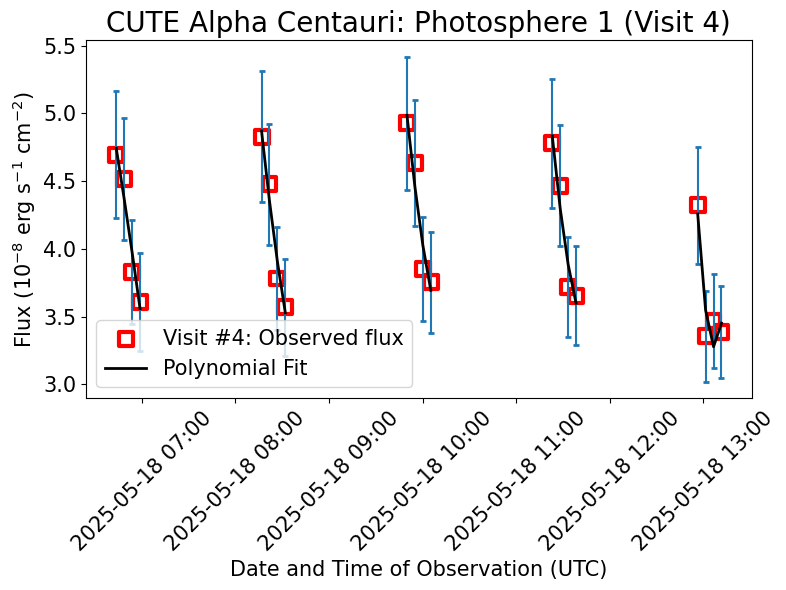

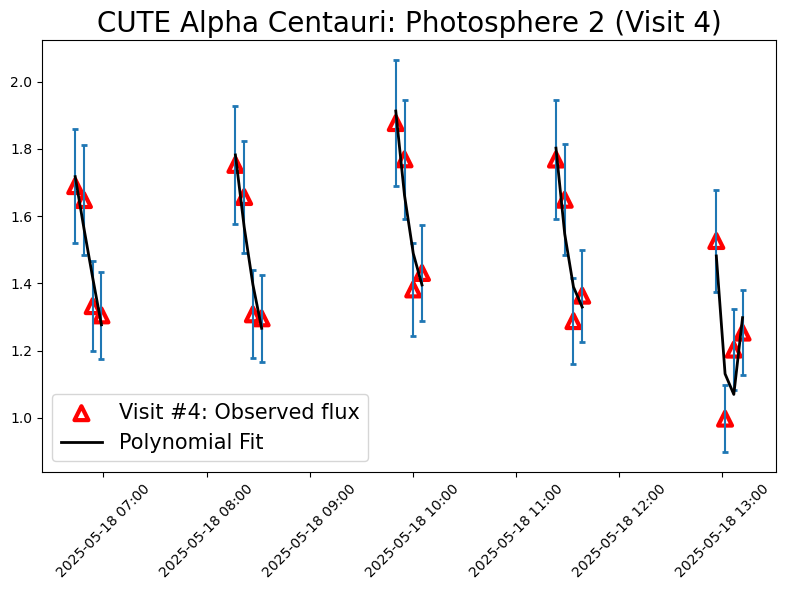

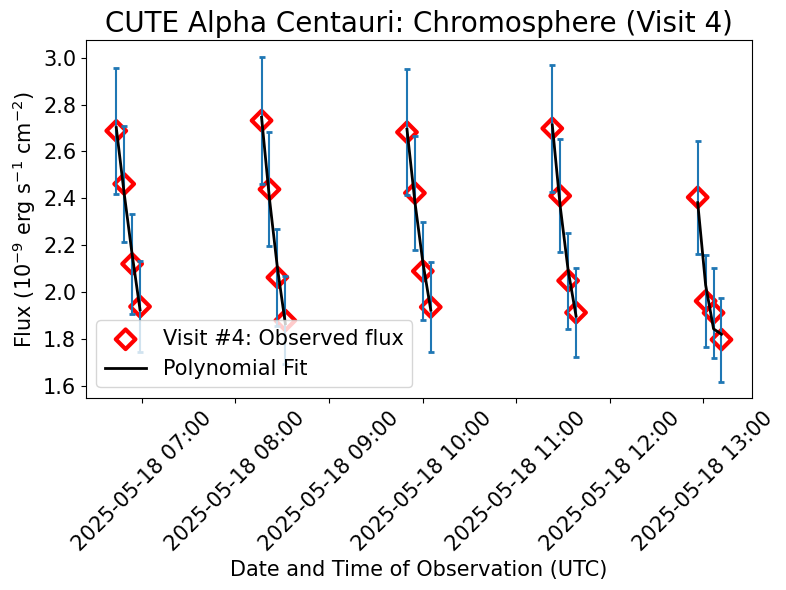

In [13]:
#Visit 4    
#Try polyfit for each visit at a time

for i in range(nfiles4):
    flux        = cute_ff4[:, i]
    ww          = cute_wavesol - 12
    ind         = np.where((ww >= 2550) & (ww <= 3255))
    fluxtot     = integrate.simpson(flux[ind], ww[ind])
    totflux4[i] = fluxtot

    ind2        = np.where((ww >= 2550) & (ww < 2790))
    fluxtot     = integrate.simpson(flux[ind2], ww[ind2])
    phot1_4[i]  = fluxtot

    ind3        = np.where((ww >= 2790) & (ww <= 2805))
    fluxtot     = integrate.simpson(flux[ind3], ww[ind3])
    chrom4[i]   = fluxtot

    ind4        = np.where((ww > 2805) & (ww <= 3255))
    fluxtot     = integrate.simpson(flux[ind4], ww[ind4])
    phot2_4[i]  = fluxtot

#Refer to Visit 4 for an explanation of the arrays and the steps
tarr14   = timearr4[0:4]
farr14   = phot1_4[0:4] 
farr142  = phot2_4[0:4]
farr143  = chrom4[0:4]
result14 = np.polyfit(tarr14, farr14, 2) 
result24 = np.polyfit(tarr14, farr142, 2)
result34 = np.polyfit(tarr14, farr143, 2)
poly14   = result14[0]*tarr14**2 + result14[1]*tarr14 + result14[2]
poly142  = result24[0]*tarr14**2 + result24[1]*tarr14 + result24[2]
poly143  = result34[0]*tarr14**2 + result34[1]*tarr14 + result34[2]
norm14   = poly14.max()
norm142  = poly142.max()
norm143  = poly143.max()
poly14   = poly14 / norm14 
poly142  = poly142 / norm142 
poly143  = poly143 / norm143 
corr14   = farr14 / poly14
corr142  = farr142 / poly142
corr143  = farr143 / poly143

tarr24   = timearr4[4:8]
farr24   = phot1_4[4:8] 
farr242  = phot2_4[4:8]
farr243  = chrom4[4:8]
result124 = np.polyfit(tarr24, farr24, 2) 
result224 = np.polyfit(tarr24, farr242, 2)
result324 = np.polyfit(tarr24, farr243, 2)
poly24   = result124[0]*tarr24**2 + result124[1]*tarr24 + result124[2]
poly242  = result224[0]*tarr24**2 + result224[1]*tarr24 + result224[2]
poly243  = result324[0]*tarr24**2 + result324[1]*tarr24 + result324[2]
norm24   = poly24.max()
norm242  = poly242.max()
norm243  = poly243.max()
poly24   = poly24 / norm24
poly242  = poly242 / norm242 
poly243  = poly243 / norm243 
corr24   = farr24 / poly24
corr242  = farr242 / poly242
corr243  = farr243 / poly243

tarr34   = timearr4[8:12]
farr34   = phot1_4[8:12] 
farr342  = phot2_4[8:12]
farr343  = chrom4[8:12]
result134 = np.polyfit(tarr34, farr34, 2)
result234 = np.polyfit(tarr34, farr342, 2)
result334 = np.polyfit(tarr34, farr343, 2) 
poly34   = result134[0]*tarr34**2 + result134[1]*tarr34 + result134[2]
poly342  = result234[0]*tarr34**2 + result234[1]*tarr34 + result234[2]
poly343  = result334[0]*tarr34**2 + result334[1]*tarr34 + result334[2]
norm34   = poly34.max()
norm342  = poly342.max()
norm343  = poly343.max()
poly34   = poly34 / norm34
poly342  = poly342 / norm342 
poly343  = poly343 / norm343 
corr34   = farr34 / poly34
corr342  = farr342 / poly342
corr343  = farr343 / poly343

tarr44   = timearr4[12:16]
farr44   = phot1_4[12:16] 
farr442  = phot2_4[12:16]
farr443  = chrom4[12:16]
result144 = np.polyfit(tarr44, farr44, 2) 
result244 = np.polyfit(tarr44, farr442, 2)
result344 = np.polyfit(tarr44, farr443, 2)
poly44   = result144[0]*tarr44**2 + result144[1]*tarr44 + result144[2]
poly442  = result244[0]*tarr44**2 + result244[1]*tarr44 + result244[2]
poly443  = result344[0]*tarr44**2 + result344[1]*tarr44 + result344[2]
norm44   = poly44.max()
norm442  = poly442.max()
norm443  = poly443.max()
poly44   = poly44 / norm44
poly442  = poly442 / norm442 
poly443  = poly443 / norm443 
corr44   = farr44 / poly44
corr442  = farr442 / poly442
corr443  = farr443 / poly443

tarr54   = timearr4[16:20]
farr54   = phot1_4[16:20]
farr542  = phot2_4[16:20]
farr543  = chrom4[16:20]
result154 = np.polyfit(tarr54, farr54, 2)
result254 = np.polyfit(tarr54, farr542, 2)
result354 = np.polyfit(tarr54, farr543, 2) 
poly54   = result154[0]*tarr54**2 + result154[1]*tarr54 + result154[2]
poly542  = result254[0]*tarr54**2 + result254[1]*tarr54 + result254[2]
poly543  = result354[0]*tarr54**2 + result354[1]*tarr54 + result354[2]
norm54   = poly54.max()
norm542  = poly542.max()
norm543  = poly543.max()
poly54   = poly54 / norm54
poly542  = poly542 / norm542 
poly543  = poly543 / norm543 
corr54   = farr54 / poly54
corr542  = farr542 / poly542
corr543  = farr543 / poly543

corflux4  = np.concatenate((corr14, corr24, corr34))
corflux42 = np.concatenate((corr142, corr242, corr342))
corflux43 = np.concatenate((corr143, corr243, corr343))
corflux4  = np.append(corflux4, corr44) 
corflux42 = np.append(corflux42, corr442)
corflux43 = np.append(corflux43, corr443) 
corflux4  = np.append(corflux4, corr54) 
corflux42 = np.append(corflux42, corr542)
corflux43 = np.append(corflux43, corr543) 

#Photosphere 1
fig, ax = plt.subplots(figsize=(8,6))
title  = 'CUTE Alpha Centauri: Photosphere 1 (Visit 4)'
ax.set_title(title, fontsize=20)
ax.tick_params(axis='both', which='major', labelsize=15) 
ax.set_xlabel('Date and Time of Observation (UTC)', fontsize=15)
ax.set_ylabel('Flux (10$^{-8}$ erg s$^{-1}$ cm$^{-2}$)', fontsize=15)
ax.scatter(dates4, phot1_4*1.e8, label='Visit #4: Observed flux', marker='s', edgecolors='red', s=100, facecolors='none', linewidths=3)
ax.errorbar(dates4, phot1_4*1.e8, yerr=0.1*phot1_4*1.e8, linestyle='none', capthick=2, capsize=2)
ax.plot(dates4[0:4], poly14*norm14*1.e8, color='black', label='Polynomial Fit', lw=2)
ax.plot(dates4[4:8], poly24*norm24*1.e8, color='black', lw=2)
ax.plot(dates4[8:12], poly34*norm34*1.e8, color='black', lw=2)
ax.plot(dates4[12:16], poly44*norm44*1.e8, color='black', lw=2)
ax.plot(dates4[16:20], poly54*norm54*1.e8, color='black', lw=2)
date_format = mdates.DateFormatter("%Y-%m-%d %H:%M")
ax.xaxis.set_major_formatter(date_format)
plt.xticks(rotation=45)
ax.legend(fontsize=15, loc=3)
fig.tight_layout()
plt.show()

#Photosphere 2
fig, ax = plt.subplots(figsize=(8,6))
title  = 'CUTE Alpha Centauri: Photosphere 2 (Visit 4)'
ax.set_title(title, fontsize=20)
ax.scatter(dates4, phot2_4*1.e7, label='Visit #4: Observed flux', marker='^', edgecolors='red', s=100, facecolors='none', linewidths=3)
ax.errorbar(dates4, phot2_4*1.e7, yerr=0.1*phot2_4*1.e7, linestyle='none', capthick=2, capsize=2)
ax.plot(dates4[0:4], poly142*norm142*1.e7, color='black', label='Polynomial Fit', lw=2)
ax.plot(dates4[4:8], poly242*norm242*1.e7, color='black', lw=2)
ax.plot(dates4[8:12], poly342*norm342*1.e7, color='black', lw=2)
ax.plot(dates4[12:16], poly442*norm442*1.e7, color='black', lw=2)
ax.plot(dates4[16:20], poly542*norm542*1.e7, color='black', lw=2)
ax.xaxis.set_major_formatter(date_format)
plt.xticks(rotation=45)
ax.legend(fontsize=15, loc=3)
fig.tight_layout()
plt.show()

#Chromosphere
fig, ax = plt.subplots(figsize=(8,6))
title  = 'CUTE Alpha Centauri: Chromosphere (Visit 4)'
ax.set_title(title, fontsize=20)
ax.tick_params(axis='both', which='major', labelsize=15) 
ax.set_xlabel('Date and Time of Observation (UTC)', fontsize=15)
ax.set_ylabel('Flux (10$^{-9}$ erg s$^{-1}$ cm$^{-2}$)', fontsize=15)
ax.scatter(dates4, chrom4*1.e9, label='Visit #4: Observed flux', marker='D', edgecolors='red', s=100, facecolors='none', linewidths=3)
ax.errorbar(dates4, chrom4*1.e9, yerr=0.1*chrom4*1.e9, linestyle='none', capthick=2, capsize=2)
ax.plot(dates4[0:4], poly143*norm143*1.e9, color='black', label='Polynomial Fit', lw=2)
ax.plot(dates4[4:8], poly243*norm243*1.e9, color='black', lw=2)
ax.plot(dates4[8:12], poly343*norm343*1.e9, color='black', lw=2)
ax.plot(dates4[12:16], poly443*norm443*1.e9, color='black', lw=2)
ax.plot(dates4[16:20], poly543*norm543*1.e9, color='black', lw=2)
ax.xaxis.set_major_formatter(date_format)
plt.xticks(rotation=45)
ax.legend(fontsize=15, loc=3)
fig.tight_layout()
plt.show()


In [14]:
#Visit 4    
#Try polyfit for each visit at a time
for i in range(nfiles4):
    flux           = cute_ff4[:,i]
    ww             = cute_wavesol-2
    ind            = np.where((ww >= 2550) & (ww <= 3255))
    fluxtot        = integrate.simpson(flux[ind],ww[ind])
    totflux4[i]    = fluxtot
    ind2           = np.where((ww >= 2550) & (ww < 2790))
    fluxtot        = integrate.simpson(flux[ind2],ww[ind2])
    phot1_4[i]     = fluxtot
    flux1          = cute_ff4_sigup[:,i]
    phot1_4sigup[i]= integrate.simpson(flux1[ind2],ww[ind2]) - fluxtot
    flux2          = cute_ff4_sigdn[:,i]
    phot1_4sigdn[i]= fluxtot - integrate.simpson(flux2[ind2],ww[ind2])
    ind3           = np.where((ww >= 2790) & (ww <= 2805))
    fluxtot        = integrate.simpson(flux[ind3],ww[ind3])
    chrom4[i]      = fluxtot
    chrom4_sigup[i]= integrate.simpson(flux1[ind3],ww[ind3]) - fluxtot
    chrom4_sigdn[i]= fluxtot - integrate.simpson(flux2[ind3],ww[ind3])
    ind4           = np.where((ww > 2805) & (ww <= 3255))
    fluxtot        = integrate.simpson(flux[ind4],ww[ind4])
    phot2_4[i]     = fluxtot
    phot2_4sigup[i]= integrate.simpson(flux1[ind4],ww[ind4]) - fluxtot
    phot2_4sigdn[i]= fluxtot - integrate.simpson(flux1[ind4],ww[ind4])

#This is orbit 1
tarr11   = timearr4[0:4]
farr14   = phot1_4[0:4]           #This is photosphere 1
farr142  = phot2_4[0:4]           #This is photosphere 2
farr143  = chrom4[0:4]            #This is the chromosphere
result11 = np.polyfit(tarr11,farr14,2)   #Get the polynomial parameters to best-fit the data
result21 = np.polyfit(tarr11,farr142,2)
result31 = np.polyfit(tarr11,farr143,2)
poly14   = result11[0]*tarr11**2 + result11[1]*tarr11 + result11[2] #Create the polynomial that fits the data best
poly142  = result21[0]*tarr11**2 + result21[1]*tarr11 + result21[2]
poly143  = result31[0]*tarr11**2 + result31[1]*tarr11 + result31[2]
norm14   = poly14.max()     #Get the max value of the function
norm142  = poly142.max()    
norm143  = poly143.max()
poly14   = poly14/norm14    #Divide the polynomial by the max value to normalize it
poly142  = poly142/norm142 
poly143  = poly143/norm143 
corr14   = farr14/poly14     #Apply the correction to the orbit by dividing it with the normalized polynomial function
corr142  = farr142/poly142
corr143  = farr143/poly143

#This is orbit 2
tarr24  = timearr4[4:8]
farr24  = phot1_4[4:8] 
farr242 = phot2_4[4:8]
farr243 = chrom4[4:8]
result12 = np.polyfit(tarr24,farr24,2) 
result22 = np.polyfit(tarr24,farr242,2)
result32 = np.polyfit(tarr24,farr243,2)
poly24  = result12[0]*tarr24**2 + result12[1]*tarr24 + result12[2]
poly242 = result22[0]*tarr24**2 + result22[1]*tarr24 + result22[2]
poly243 = result32[0]*tarr24**2 + result32[1]*tarr24 + result32[2]
norm24  = poly24.max()
norm242 = poly242.max()
norm243 = poly243.max()
poly24  = poly24/norm24
poly242 = poly242/norm242 
poly243 = poly243/norm243 
corr24  = farr24/poly24
corr242 = farr242/poly242
corr243 = farr243/poly243

#This is orbit 3 which has only one exposure
corr34    = phot1_4[8:12]
corr342   = phot2_4[8:12]
corr343   = chrom4[8:12]

#This is orbit 4
tarr44  = timearr4[12:16]
farr44  = phot1_4[12:16] 
farr442 = phot2_4[12:16]
farr443 = chrom4[12:16]
result14 = np.polyfit(tarr44,farr44,1) 
result24 = np.polyfit(tarr44,farr442,1)
result34 = np.polyfit(tarr44,farr443,1)
#poly44  = result14[0]*tarr44**2 + result14[1]*tarr44 + result14[2]
#poly442 = result24[0]*tarr44**2 + result24[1]*tarr44 + result24[2]
#poly443 = result34[0]*tarr44**2 + result34[1]*tarr44 + result34[2]
poly44   = result14[0]*tarr44 + result14[1]
poly442  = result24[0]*tarr44 + result24[1]
poly443  = result34[0]*tarr44 + result34[1]
norm44  = poly44.max()
norm442 = poly442.max()
norm443 = poly443.max()
poly44  = poly44/norm44
poly442 = poly442/norm442 
poly443 = poly443/norm443 
corr44  = farr44/poly44
corr442 = farr442/poly442
corr443 = farr443/poly443

#This is orbit 5 which also has one exposure
corr54    = phot1_4[16:20]
corr542   = phot2_4[16:20]
corr543   = chrom4[16:20]

9+0


9

20
20


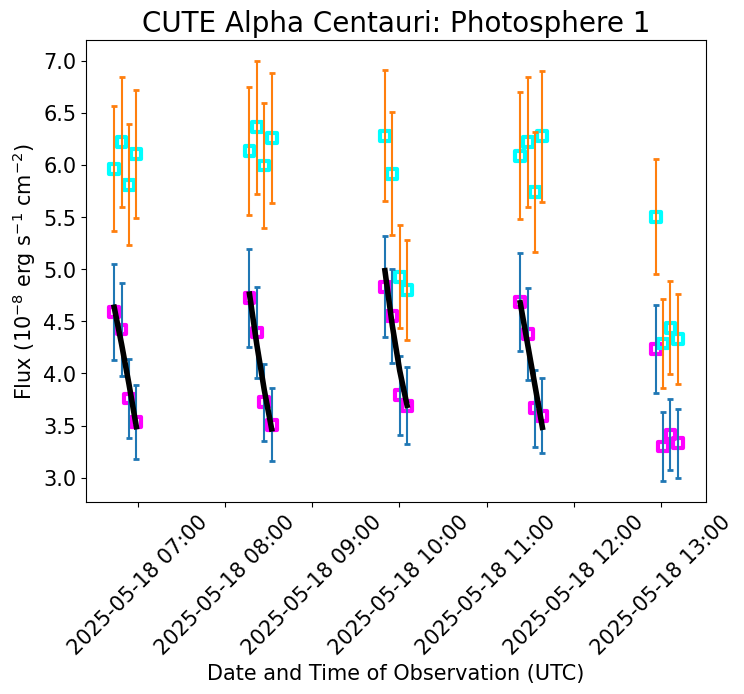

In [15]:
#Combine all the corrected flux values from all the orbits
#Photosphere 1
corflux4  = corr14
corflux4  = np.append(corflux4,corr24) 
corflux4  = np.append(corflux4,corr34)
corflux4  = np.append(corflux4,corr44) 
corflux4  = np.append(corflux4,corr54) 
#Photosphere 2
corflux42 = corr142 
corflux42 = np.append(corflux42,corr242)
corflux42 = np.append(corflux42,corr342)
corflux42 = np.append(corflux42,corr442)
corflux42 = np.append(corflux42,corr542)
#Chromosphe

corflux43 = corr143
corflux43 = np.append(corflux43,corr243) 
corflux43 = np.append(corflux43,corr343)
corflux43 = np.append(corflux43,corr443)
corflux43 = np.append(corflux43,corr543)

# print(len(corflux4))
# # Photosphere 1
# # Plot the uncorrected vs corrected flux for all orbits in visit 4
fig,ax = plt.subplots(figsize=(8,6))
title  = 'CUTE Alpha Centauri: Photosphere 1'
ax.set_title(title,fontsize=20)
ax.tick_params(axis='both', which='major', labelsize=15) 
ax.set_xlabel('Date and Time of Observation (UTC)',fontsize=15)
ax.set_ylabel('Flux (10$^{-8}$ erg s$^{-1}$ cm$^{-2}$)',fontsize=15)
# ax.set_ylim(0,7)
ax.scatter(dates4,phot1_4*1.e8, label='Visit #4: Observed flux', marker='s',edgecolors='magenta',s=50,facecolors='none',linewidths=3)
ax.errorbar(dates4,phot1_4*1.e8, yerr=0.1*phot1_4*1.e8,linestyle='none',capthick=2,capsize=2)
ax.plot(dates4[0:4], poly14*norm14*1.e8, color='black', label='Polynomial Fit',lw=4)
ax.plot(dates4[4:8], poly24*norm24*1.e8, color='black',lw=4)
ax.plot(dates4[8:12], poly34*norm34*1.e8, color='black',lw=4)
ax.plot(dates4[12:16], poly44*norm44*1.e8, color='black',lw=4)
ax.scatter(dates4,corflux4*1.3*1.e8, label='Corrected Flux x 1.3', marker='s',edgecolors='cyan',s=50,facecolors='none',linewidths=3)
ax.errorbar(dates4,corflux4*1.3*1.e8, yerr=0.1*corflux4*1.3*1.E8,linestyle='none',capthick=2,capsize=2)
# # Format x-axis
date_format = mdates.DateFormatter("%Y-%m-%d %H:%M")  # Customize format as needed
ax.xaxis.set_major_formatter(date_format)
plt.xticks(rotation=45)  # Rotate labels if needed
# ax.legend(fontsize=15,loc=3)
# fig.tight_layout()
# figname='Phot1_fluxCUTE_visit4_polyfit_werr2.jpeg'
# # plt.savefig(figname,format='jpeg',dpi=200)
# plt.show()

print(len(dates4))
print(len(corflux4))

In [16]:
8+9

17

# Visit 5

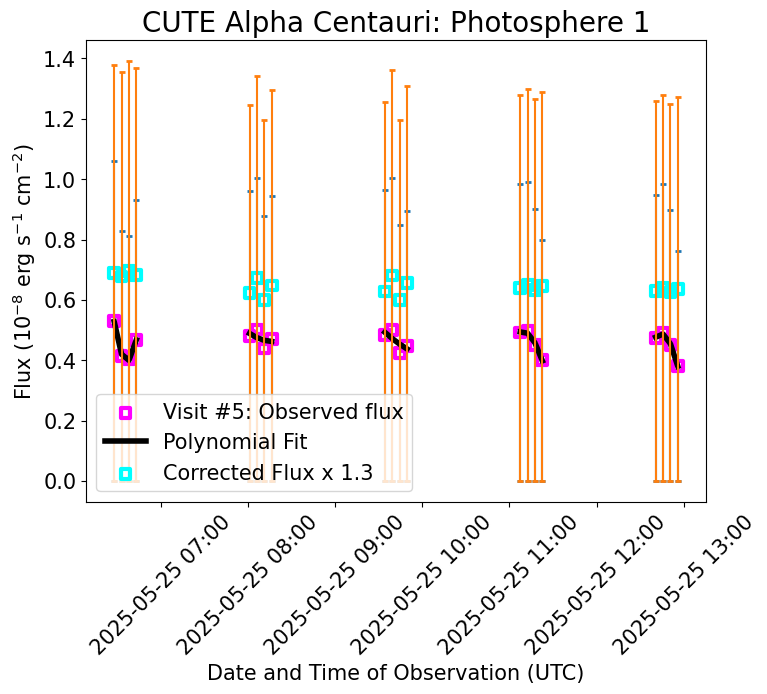

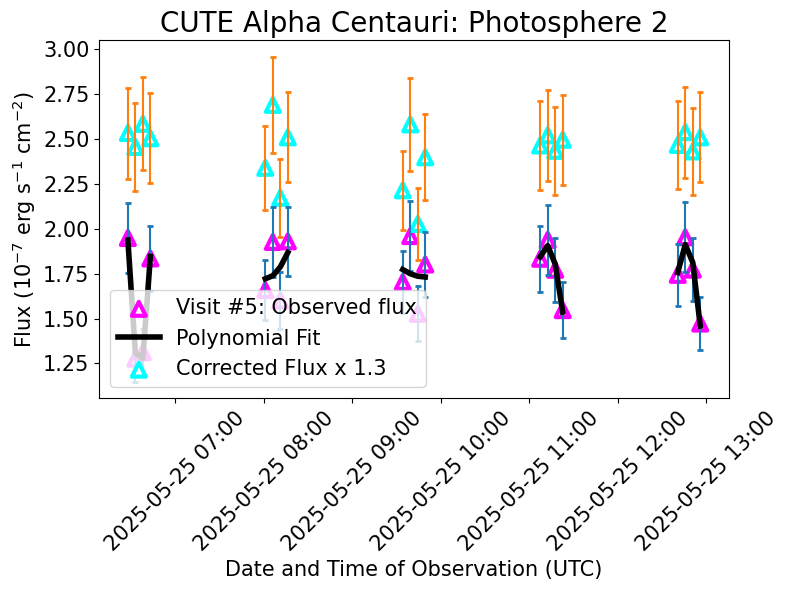

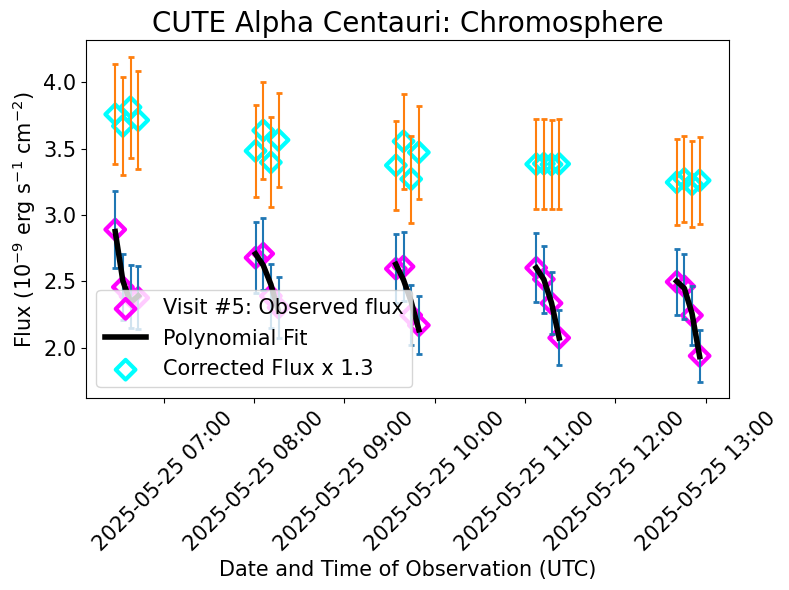

In [17]:
#---------------------------------------------    
#Visit 5    
#Try polyfit for each visit at a time
for i in range(nfiles5):
    flux           = cute_ff5[:,i]
    ww             = cute_wavesol - 2
    ind            = np.where((ww >= 2550) & (ww <= 3255))
    fluxtot        = integrate.simpson(flux[ind],ww[ind])
    totflux5[i]    = fluxtot
    ind2           = np.where((ww >= 2550) & (ww < 2790))
    fluxtot        = integrate.simpson(flux[ind2],ww[ind2])
    phot1_5[i]     = fluxtot
    flux1          = cute_ff5_sigup[:,i]
    phot1_5sigup[i]= integrate.simpson(flux1[ind2],ww[ind2]) - fluxtot
    flux2          = cute_ff5_sigdn[:,i]
    phot1_5sigdn[i]= fluxtot - integrate.simpson(flux2[ind2],ww[ind2])
    ind3           = np.where((ww >= 2790) & (ww <= 2805))
    fluxtot        = integrate.simpson(flux[ind3],ww[ind3])
    chrom5[i]      = fluxtot
    chrom5_sigup[i]= integrate.simpson(flux1[ind3],ww[ind3]) - fluxtot
    chrom5_sigdn[i]= fluxtot - integrate.simpson(flux2[ind3],ww[ind3])
    ind4           = np.where((ww > 2805) & (ww <= 3255))
    fluxtot        = integrate.simpson(flux[ind4],ww[ind4])
    phot2_5[i]     = fluxtot
    phot2_5sigup[i]= integrate.simpson(flux1[ind4],ww[ind4]) - fluxtot
    phot2_5sigdn[i]= fluxtot - integrate.simpson(flux1[ind4],ww[ind4])


#Refer to Visit 4 for an explanation of the arrays and the steps
tarr15   = timearr5[0:4]
farr15   = phot1_5[0:4] 
farr152  = phot2_5[0:4]
farr153  = chrom5[0:4]
result11 = np.polyfit(tarr15,farr15,2) 
result21 = np.polyfit(tarr15,farr152,2)
result31 = np.polyfit(tarr15,farr153,2)
poly15   = result11[0]*tarr15**2 + result11[1]*tarr15 + result11[2]
poly152  = result21[0]*tarr15**2 + result21[1]*tarr15 + result21[2]
poly153  = result31[0]*tarr15**2 + result31[1]*tarr15 + result31[2]
norm15   = poly15.max()
norm152  = poly152.max()
norm153  = poly153.max()
poly15   = poly15/norm15 
poly152  = poly152/norm152 
poly153  = poly153/norm153 
corr15   = farr15/poly15
corr152  = farr152/poly152
corr153  = farr153/poly153

tarr25  = timearr5[4:8]
farr25  = phot1_5[4:8] 
farr252 = phot2_5[4:8]
farr253 = chrom5[4:8]
result12 = np.polyfit(tarr25,farr25,2) 
result22 = np.polyfit(tarr25,farr252,2)
result32 = np.polyfit(tarr25,farr253,2)
poly25  = result12[0]*tarr25**2 + result12[1]*tarr25 + result12[2]
poly252 = result22[0]*tarr25**2 + result22[1]*tarr25 + result22[2]
poly253 = result32[0]*tarr25**2 + result32[1]*tarr25 + result32[2]
norm25  = poly25.max()
norm252 = poly252.max()
norm253 = poly253.max()
poly25  = poly25/norm25
poly252 = poly252/norm252 
poly253 = poly253/norm253 
corr25  = farr25/poly25
corr252 = farr252/poly252
corr253 = farr253/poly253

tarr35  = timearr5[8:12]
farr35  = phot1_5[8:12] 
farr352 = phot2_5[8:12]
farr353 = chrom5[8:12]
result13 = np.polyfit(tarr35,farr35,2)
result23 = np.polyfit(tarr35,farr352,2)
result33 = np.polyfit(tarr35,farr353,2) 
poly35  = result13[0]*tarr35**2 + result13[1]*tarr35 + result13[2]
poly352 = result23[0]*tarr35**2 + result23[1]*tarr35 + result23[2]
poly353 = result33[0]*tarr35**2 + result33[1]*tarr35 + result33[2]
norm35  = poly35.max()
norm352 = poly352.max()
norm353 = poly353.max()
poly35  = poly35/norm35
poly352 = poly352/norm352 
poly353 = poly353/norm353 
corr35  = farr35/poly35
corr352 = farr352/poly352
corr353 = farr353/poly353

tarr45  = timearr5[12:16]
farr45  = phot1_5[12:16] 
farr452 = phot2_5[12:16]
farr453 = chrom5[12:16]
result14 = np.polyfit(tarr45,farr45,2) 
result24 = np.polyfit(tarr45,farr452,2)
result34 = np.polyfit(tarr45,farr453,2)
poly45  = result14[0]*tarr45**2 + result14[1]*tarr45 + result14[2]
poly452 = result24[0]*tarr45**2 + result24[1]*tarr45 + result24[2]
poly453 = result34[0]*tarr45**2 + result34[1]*tarr45 + result34[2]
norm45  = poly45.max()
norm452 = poly452.max()
norm453 = poly453.max()
poly45  = poly45/norm45
poly452 = poly452/norm452 
poly453 = poly453/norm453 
corr45  = farr45/poly45
corr452 = farr452/poly452
corr453 = farr453/poly453

tarr55  = timearr5[16:20]
farr55  = phot1_5[16:20] 
farr552 = phot2_5[16:20]
farr553 = chrom5[16:20]
result15 = np.polyfit(tarr55,farr55,2) 
result25 = np.polyfit(tarr55,farr552,2)
result35 = np.polyfit(tarr55,farr553,2)
poly55  = result15[0]*tarr55**2 + result15[1]*tarr55 + result15[2]
poly552 = result25[0]*tarr55**2 + result25[1]*tarr55 + result25[2]
poly553 = result35[0]*tarr55**2 + result35[1]*tarr55 + result35[2]
norm55  = poly55.max()
norm552 = poly552.max()
norm553 = poly553.max()
poly55  = poly55/norm55
poly552 = poly552/norm552 
poly553 = poly553/norm553 
corr55  = farr55/poly55
corr552 = farr552/poly552
corr553 = farr553/poly553

# corflux =[]
# corflux5  = np.concatenate((corr15,corr25,corr35,corr45,corr55))
# corflux52 = np.concatenate((corr152,corr252,corr352))
# corflux53 = np.concatenate((corr153,corr253,corr353))
# corflux5  = np.append(corflux5,corr45) 
# corflux5  = np.append(corflux5,corr55) 

# corflux52 = np.append(corflux52,corr452)
# corflux52 = np.append(corflux52,corr552)

# corflux52 = np.append(corflux52,phot2_5)
# corflux53 = np.append(corflux53,corr453) 
# corflux53 = np.append(corflux53,corr553) 
 
# corflux53 = np.append(corflux53,chrom5)

corflux5  = np.concatenate((corr15,corr25,corr35))
corflux52 = np.concatenate((corr152,corr252,corr352))
corflux53 = np.concatenate((corr153,corr253,corr353))
corflux5  = np.append(corflux5,corr45) 
corflux5  = np.append(corflux5,corr55) 
corflux52 = np.append(corflux52,corr452)
corflux52 = np.append(corflux52,corr552)
corflux53 = np.append(corflux53,corr453) 
corflux53 = np.append(corflux53,corr553) 







# Photosphere 1
# #Plot the uncorrected vs corrected flux for all orbits in visit 5
y_err = [phot1_5sigdn*1.E8,phot1_5sigup*1.E8]
fig,ax = plt.subplots(figsize=(8,6))
title  = 'CUTE Alpha Centauri: Photosphere 1'
ax.set_title(title,fontsize=20)
ax.tick_params(axis='both', which='major', labelsize=15) 
ax.set_xlabel('Date and Time of Observation (UTC)',fontsize=15)
ax.set_ylabel('Flux (10$^{-8}$ erg s$^{-1}$ cm$^{-2}$)',fontsize=15)
# # ax.set_ylim(0,7)
ax.scatter(dates5,phot1_5*1.e7, label='Visit #5: Observed flux', marker='s',edgecolors='magenta',s=50,facecolors='none',linewidths=3)
ax.errorbar(dates5,phot1_5*1.e7, yerr=0.1*phot1_5*1.E8,linestyle='none',capthick=2,capsize=2)
ax.plot(dates5[0:4], poly15*norm15*1.e7, color='black', label='Polynomial Fit',lw=4)
ax.plot(dates5[4:8], poly25*norm25*1.e7, color='black',lw=4)
ax.plot(dates5[8:12], poly35*norm35*1.e7, color='black',lw=4)
ax.plot(dates5[12:16], poly45*norm45*1.e7, color='black',lw=4)
ax.plot(dates5[16:20], poly55*norm55*1.e7, color='black',lw=4)
ax.scatter(dates5,corflux5*1.3*1.e7, label='Corrected Flux x 1.3', marker='s',edgecolors='cyan',s=50,facecolors='none',linewidths=3)
ax.errorbar(dates5,corflux5*1.3*1.e7, yerr=0.1*corflux5*1.3*1.E8,linestyle='none',capthick=2,capsize=2)
# # Format x-axis
date_format = mdates.DateFormatter("%Y-%m-%d %H:%M")  # Customize format as needed
ax.xaxis.set_major_formatter(date_format)
plt.xticks(rotation=45)  # Rotate labels if needed
ax.legend(fontsize=15,loc=3)
# fig.tight_layout()
# figname='Phot1_fluxCUTE_visit5_polyfit.jpeg'
# # plt.savefig(figname,format='jpeg',dpi=200)
# #plt.show()

# print(len(dates5))
# print(len(corflux5))

len(poly353)

#Photosphere 2
#Plot the uncorrected vs corrected flux for all orbits in visit 5
fig,ax = plt.subplots(figsize=(8,6))
title  = 'CUTE Alpha Centauri: Photosphere 2'
ax.set_title(title,fontsize=20)
ax.tick_params(axis='both', which='major', labelsize=15) 
ax.set_xlabel('Date and Time of Observation (UTC)',fontsize=15)
ax.set_ylabel('Flux (10$^{-7}$ erg s$^{-1}$ cm$^{-2}$)',fontsize=15)
# ax.set_ylim(0,3.0)
ax.scatter(dates5,phot2_5*1.e7, label='Visit #5: Observed flux', marker='^',edgecolors='magenta',s=100,facecolors='none',linewidths=3)
ax.errorbar(dates5,phot2_5*1.e7, yerr=0.1*phot2_5*1.E7,linestyle='none',capthick=2,capsize=2)
ax.plot(dates5[0:4], poly152*norm152*1.e7, color='black', label='Polynomial Fit',lw=4)
ax.plot(dates5[4:8], poly252*norm252*1.e7, color='black',lw=4)
ax.plot(dates5[8:12], poly352*norm352*1.e7, color='black',lw=4)
ax.plot(dates5[12:16], poly452*norm452*1.e7, color='black',lw=4)
ax.plot(dates5[16:20], poly552*norm552*1.e7, color='black',lw=4)
ax.scatter(dates5,corflux52*1.3*1.e7, label='Corrected Flux x 1.3', marker='^',edgecolors='cyan',s=100,facecolors='none',linewidths=3)
ax.errorbar(dates5,corflux52*1.3*1.e7, yerr=0.1*corflux52*1.3*1.E7,linestyle='none',capthick=2,capsize=2)
# Format x-axis
date_format = mdates.DateFormatter("%Y-%m-%d %H:%M")  # Customize format as needed
ax.xaxis.set_major_formatter(date_format)
plt.xticks(rotation=45)  # Rotate labels if needed
ax.legend(fontsize=15,loc=3)
fig.tight_layout()
# figname='/Users/dobh6980/Projects/Kevin_projects/CUTE/Alpha_Cen/plots/visit5_fit/Phot2_fluxCUTE_visit5_polyfit_werr2.jpeg'
# plt.savefig(figname,format='jpeg',dpi=200)
plt.show()


#Chromosphere
fig,ax = plt.subplots(figsize=(8,6))
title  = 'CUTE Alpha Centauri: Chromosphere'
ax.set_title(title,fontsize=20)
ax.tick_params(axis='both', which='major', labelsize=15) 
ax.set_xlabel('Date and Time of Observation (UTC)',fontsize=15)
ax.set_ylabel('Flux (10$^{-9}$ erg s$^{-1}$ cm$^{-2}$)',fontsize=15)
# ax.set_ylim(0,3.0)
ax.scatter(dates5,chrom5*1.e9, label='Visit #5: Observed flux', marker='D',edgecolors='magenta',s=100,facecolors='none',linewidths=3)
ax.errorbar(dates5,chrom5*1.e9, yerr=0.1*chrom5*1.E9,linestyle='none',capthick=2,capsize=2)
ax.plot(dates5[0:4], poly153*norm153*1.e9, color='black', label='Polynomial Fit',lw=4)
ax.plot(dates5[4:8], poly253*norm253*1.e9, color='black',lw=4)
ax.plot(dates5[8:12], poly353*norm353*1.e9, color='black',lw=4)
ax.plot(dates5[12:16], poly453*norm453*1.e9, color='black',lw=4)
ax.plot(dates5[16:20], poly553*norm553*1.e9, color='black',lw=4)
ax.scatter(dates5,corflux53*1.3*1.e9, label='Corrected Flux x 1.3', marker='D',edgecolors='cyan',s=100,facecolors='none',linewidths=3)
ax.errorbar(dates5,corflux53*1.3*1.e9, yerr=0.1*corflux53*1.3*1.E9,linestyle='none',capthick=2,capsize=2)
# Format x-axis
date_format = mdates.DateFormatter("%Y-%m-%d %H:%M")  # Customize format as needed
ax.xaxis.set_major_formatter(date_format)
plt.xticks(rotation=45)  # Rotate labels if needed
ax.legend(fontsize=15,loc=3)
fig.tight_layout()
# figname='/Users/dobh6980/Projects/Kevin_projects/CUTE/Alpha_Cen/plots/visit5_fit/Chrom_fluxCUTE_visit5_polyfit_werr2.jpeg'
# plt.savefig(figname,format='jpeg',dpi=200)
plt.show()



# Visit 6

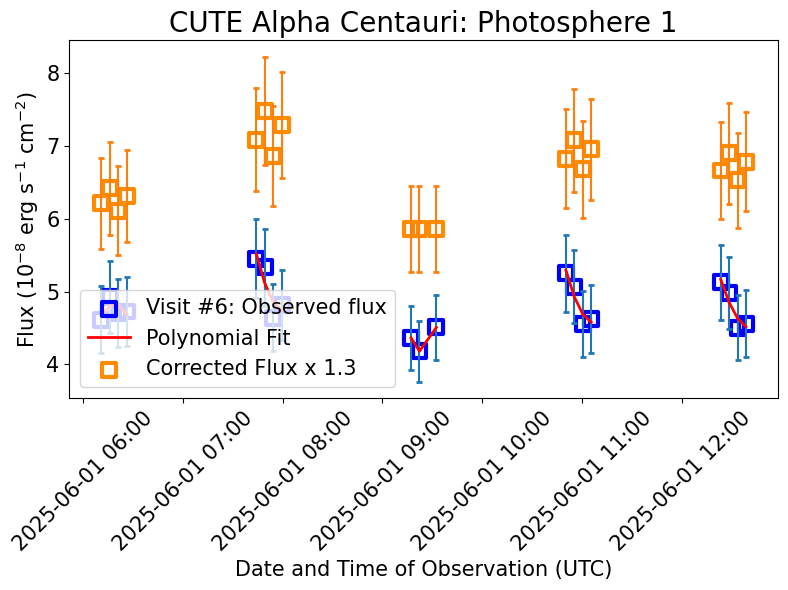

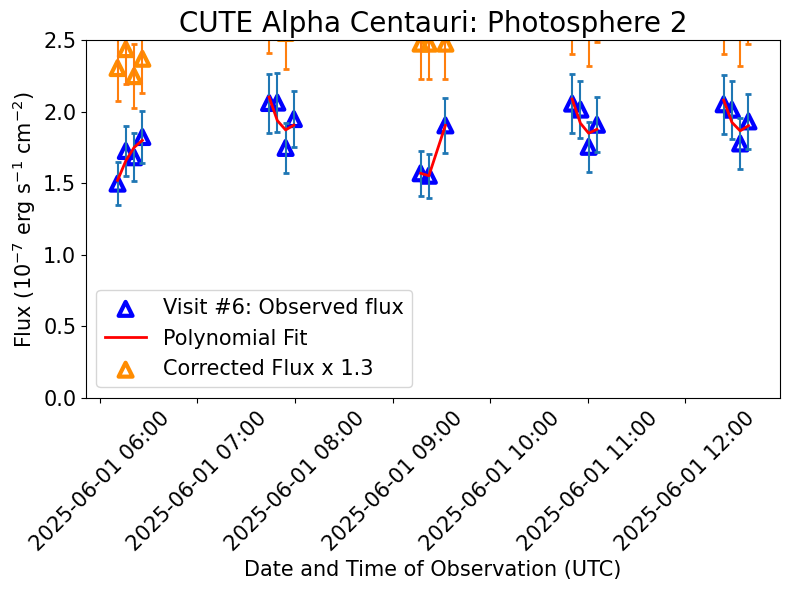

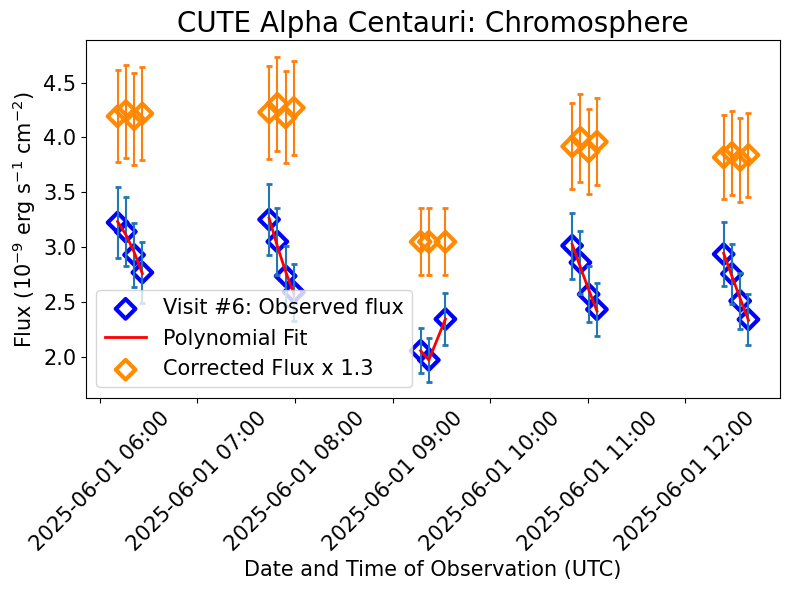

In [18]:
#Visit 6    
#Try polyfit for each visit at a time
for i in range(nfiles6):
    flux        = cute_ff6[:,i]
    ww          = cute_wavesol-2
    ind         = np.where((ww >= 2550) & (ww <= 3255))
    fluxtot     = integrate.simpson(flux[ind],ww[ind])
    totflux6[i] = fluxtot
    ind2        = np.where((ww >= 2550) & (ww < 2790))
    fluxtot     = integrate.simpson(flux[ind2],ww[ind2])
    phot1_6[i]  = fluxtot
    ind3        = np.where((ww >= 2790) & (ww <= 2805))
    fluxtot     = integrate.simpson(flux[ind3],ww[ind3])
    chrom6[i]   = fluxtot
    ind4        = np.where((ww > 2805) & (ww <= 3255))
    fluxtot     = integrate.simpson(flux[ind4],ww[ind4])
    phot2_6[i]  = fluxtot

#Refer to Visit 4 for an explanation of the arrays and the steps
tarr16   = timearr6[0:4]
farr16   = phot1_6[0:4] 
farr162  = phot2_6[0:4]
farr163  = chrom6[0:4]
result11 = np.polyfit(tarr16,farr16,2) 
result21 = np.polyfit(tarr16,farr162,2)
result31 = np.polyfit(tarr16,farr163,2)
poly16   = result11[0]*tarr16**2 + result11[1]*tarr16 + result11[2]
poly162  = result21[0]*tarr16**2 + result21[1]*tarr16 + result21[2]
poly163  = result31[0]*tarr16**2 + result31[1]*tarr16 + result31[2]
norm16   = poly16.max()
norm162  = poly162.max()
norm163  = poly163.max()
poly16   = poly16/norm16 
poly162  = poly162/norm162 
poly163  = poly163/norm163 
corr16   = farr16/poly16
corr162  = farr162/poly162
corr163  = farr163/poly163

tarr26  = timearr6[4:8]
farr26  = phot1_6[4:8] 
farr262 = phot2_6[4:8]
farr263 = chrom6[4:8]
result12 = np.polyfit(tarr26,farr26,2) 
result22 = np.polyfit(tarr26,farr262,2)
result32 = np.polyfit(tarr26,farr263,2)
poly26  = result12[0]*tarr26**2 + result12[1]*tarr26 + result12[2]
poly262 = result22[0]*tarr26**2 + result22[1]*tarr26 + result22[2]
poly263 = result32[0]*tarr26**2 + result32[1]*tarr26 + result32[2]
norm26  = poly26.max()
norm262 = poly262.max()
norm263 = poly263.max()
poly26  = poly26/norm26
poly262 = poly262/norm262 
poly263 = poly263/norm263 
corr26  = farr26/poly26
corr262 = farr262/poly262
corr263 = farr263/poly263

tarr36  = timearr6[8:11]
farr36  = phot1_6[8:11] 
farr362 = phot2_6[8:11]
farr363 = chrom6[8:11]
result13 = np.polyfit(tarr36,farr36,2)
result23 = np.polyfit(tarr36,farr362,2)
result33 = np.polyfit(tarr36,farr363,2) 
poly36  = result13[0]*tarr36**2 + result13[1]*tarr36 + result13[2]
poly362 = result23[0]*tarr36**2 + result23[1]*tarr36 + result23[2]
poly363 = result33[0]*tarr36**2 + result33[1]*tarr36 + result33[2]
norm36  = poly36.max()
norm362 = poly362.max()
norm363 = poly363.max()
poly36  = poly36/norm36
poly362 = poly362/norm362 
poly363 = poly363/norm363 
corr36  = farr36/poly36
corr362 = farr362/poly362
corr363 = farr363/poly363

tarr46  = timearr6[11:15]
farr46  = phot1_6[11:15] 
farr462 = phot2_6[11:15]
farr463 = chrom6[11:15]
result14 = np.polyfit(tarr46,farr46,2) 
result24 = np.polyfit(tarr46,farr462,2)
result34 = np.polyfit(tarr46,farr463,2)
poly46  = result14[0]*tarr46**2 + result14[1]*tarr46 + result14[2]
poly462 = result24[0]*tarr46**2 + result24[1]*tarr46 + result24[2]
poly463 = result34[0]*tarr46**2 + result34[1]*tarr46 + result34[2]
norm46  = poly46.max()
norm462 = poly462.max()
norm463 = poly463.max()
poly46  = poly46/norm46
poly462 = poly462/norm462 
poly463 = poly463/norm463 
corr46  = farr46/poly46
corr462 = farr462/poly462
corr463 = farr463/poly463

tarr56  = timearr6[15:19]
farr56  = phot1_6[15:19] 
farr562 = phot2_6[15:19]
farr563 = chrom6[15:19]
result15 = np.polyfit(tarr56,farr56,2) 
result25 = np.polyfit(tarr56,farr562,2)
result35 = np.polyfit(tarr56,farr563,2)
poly56  = result15[0]*tarr56**2 + result15[1]*tarr56 + result15[2]
poly562 = result25[0]*tarr56**2 + result25[1]*tarr56 + result25[2]
poly563 = result35[0]*tarr56**2 + result35[1]*tarr56 + result35[2]
norm56  = poly56.max()
norm562 = poly562.max()
norm563 = poly563.max()
poly56  = poly56/norm56
poly562 = poly562/norm562 
poly563 = poly563/norm563 
corr56  = farr56/poly56
corr562 = farr562/poly562
corr563 = farr563/poly563



corflux6  = np.concatenate((corr16,corr26,corr36))
corflux62 = np.concatenate((corr162,corr262,corr362))
corflux63 = np.concatenate((corr163,corr263,corr363))
corflux6  = np.append(corflux6,corr46) 
corflux6  = np.append(corflux6,corr56) 
corflux62 = np.append(corflux62,corr462)
corflux62 = np.append(corflux62,corr562)
corflux63 = np.append(corflux63,corr463) 
corflux63 = np.append(corflux63,corr563) 

 
#Photosphere 1
#Plot the uncorrected vs corrected flux for all orbits in visit 6
fig,ax = plt.subplots(figsize=(8,6))
title  = 'CUTE Alpha Centauri: Photosphere 1'
ax.set_title(title,fontsize=20)
ax.tick_params(axis='both', which='major', labelsize=15) 
ax.set_xlabel('Date and Time of Observation (UTC)',fontsize=15)
ax.set_ylabel('Flux (10$^{-8}$ erg s$^{-1}$ cm$^{-2}$)',fontsize=15)
# ax.set_ylim(0,6)
ax.scatter(dates6,phot1_6*1.e8, label='Visit #6: Observed flux', marker='s',edgecolors='blue',s=100,facecolors='none',linewidths=3)
ax.errorbar(dates6,phot1_6*1.e8, yerr=0.1*phot1_6*1.e8,linestyle='none',capthick=2,capsize=2)
ax.plot(dates6[0:4], poly16*norm16*1.e8, color='red', label='Polynomial Fit',lw=2)
ax.plot(dates6[4:8], poly26*norm26*1.e8, color='red',lw=2)
ax.plot(dates6[8:11], poly36*norm36*1.e8, color='red',lw=2)
ax.plot(dates6[11:15], poly46*norm46*1.e8, color='red',lw=2)
ax.plot(dates6[15:19], poly56*norm56*1.e8, color='red',lw=2)
ax.scatter(dates6,corflux6*1.3*1.e8, label='Corrected Flux x 1.3', marker='s',edgecolors='darkorange',s=100,facecolors='none',linewidths=3)
ax.errorbar(dates6,corflux6*1.3*1.e8, yerr=0.1*corflux6*1.3*1.e8,linestyle='none',capthick=2,capsize=2)
# Format x-axis
date_format = mdates.DateFormatter("%Y-%m-%d %H:%M")  # Customize format as needed
ax.xaxis.set_major_formatter(date_format)
plt.xticks(rotation=45)  # Rotate labels if needed
ax.legend(fontsize=15,loc=3)
fig.tight_layout()
plt.show()

#Photosphere 2
#Plot the uncorrected vs corrected flux for all orbits in visit 6
fig,ax = plt.subplots(figsize=(8,6))
title  = 'CUTE Alpha Centauri: Photosphere 2'
ax.set_title(title,fontsize=20)
ax.tick_params(axis='both', which='major', labelsize=15) 
ax.set_xlabel('Date and Time of Observation (UTC)',fontsize=15)
ax.set_ylabel('Flux (10$^{-7}$ erg s$^{-1}$ cm$^{-2}$)',fontsize=15)
ax.set_ylim(0,2.5)
ax.scatter(dates6,phot2_6*1.e7, label='Visit #6: Observed flux', marker='^',edgecolors='blue',s=100,facecolors='none',linewidths=3)
ax.errorbar(dates6,phot2_6*1.e7, yerr=0.1*phot2_6*1.e7,linestyle='none',capthick=2,capsize=2)
ax.plot(dates6[0:4], poly162*norm162*1.e7, color='red', label='Polynomial Fit',lw=2)
ax.plot(dates6[4:8], poly262*norm262*1.e7, color='red',lw=2)
ax.plot(dates6[8:11], poly362*norm362*1.e7, color='red',lw=2)
ax.plot(dates6[11:15], poly462*norm462*1.e7, color='red',lw=2)
ax.plot(dates6[15:19], poly562*norm562*1.e7, color='red',lw=2)
ax.scatter(dates6,corflux62*1.3*1.e7, label='Corrected Flux x 1.3', marker='^',edgecolors='darkorange',s=100,facecolors='none',linewidths=3)
ax.errorbar(dates6,corflux62*1.3*1.e7, yerr=0.1*corflux62*1.3*1.e7,linestyle='none',capthick=2,capsize=2)
# Format x-axis
date_format = mdates.DateFormatter("%Y-%m-%d %H:%M")  # Customize format as needed
ax.xaxis.set_major_formatter(date_format)
plt.xticks(rotation=45)  # Rotate labels if needed
ax.legend(fontsize=15,loc=3)
fig.tight_layout()

plt.show()

#Chromosphere
fig,ax = plt.subplots(figsize=(8,6))
title  = 'CUTE Alpha Centauri: Chromosphere'
ax.set_title(title,fontsize=20)
ax.tick_params(axis='both', which='major', labelsize=15) 
ax.set_xlabel('Date and Time of Observation (UTC)',fontsize=15)
ax.set_ylabel('Flux (10$^{-9}$ erg s$^{-1}$ cm$^{-2}$)',fontsize=15)
# ax.set_ylim(0,3.0)
ax.scatter(dates6,chrom6*1.e9, label='Visit #6: Observed flux', marker='D',edgecolors='blue',s=100,facecolors='none',linewidths=3)
ax.errorbar(dates6,chrom6*1.e9, yerr=0.1*chrom6*1.e9,linestyle='none',capthick=2,capsize=2)
ax.plot(dates6[0:4], poly163*norm163*1.e9, color='red', label='Polynomial Fit',lw=2)
ax.plot(dates6[4:8], poly263*norm263*1.e9, color='red',lw=2)
ax.plot(dates6[8:11], poly363*norm363*1.e9, color='red',lw=2)
ax.plot(dates6[11:15], poly463*norm463*1.e9, color='red',lw=2)
ax.plot(dates6[15:19], poly563*norm563*1.e9, color='red',lw=2)
ax.scatter(dates6,corflux63*1.3*1.e9, label='Corrected Flux x 1.3', marker='D',edgecolors='darkorange',s=100,facecolors='none',linewidths=3)
ax.errorbar(dates6,corflux63*1.3*1.e9, yerr=0.1*corflux63*1.3*1.e9,linestyle='none',capthick=2,capsize=2)
# Format x-axis
date_format = mdates.DateFormatter("%Y-%m-%d %H:%M")  # Customize format as needed
ax.xaxis.set_major_formatter(date_format)
plt.xticks(rotation=45)  # Rotate labels if needed
ax.legend(fontsize=15,loc=3)
fig.tight_layout()

plt.show()

# #Plotting the corrected Photosphere 1, Photosphere 2 and Chromosphere for visit 6
# fig,ax = plt.subplots(figsize=(8,6))
# title  = 'CUTE Alpha Centauri Observations: Visit #6'
# ax.set_title(title,fontsize=20)
# ax.tick_params(axis='both', which='major', labelsize=15) 
# ax.set_xlabel('Date and Time of Observation (UTC)',fontsize=15)
# ax.set_ylabel('Flux (erg s$^{-1}$ cm$^{-2}$)',fontsize=15)
# ax.set_yscale('log')
# ax.scatter(dates6,corflux6, label='Photosphere 1', marker='s',edgecolors='cyan',s=100,facecolors='none',linewidths=3)
# ax.errorbar(dates6,corflux6, yerr=0.1*corflux6,linestyle='none',capthick=2,capsize=2)
# ax.scatter(dates6,corflux62, label='Photosphere 2', marker='^',edgecolors='magenta',s=100,facecolors='none',linewidths=3)
# ax.errorbar(dates6,corflux62, yerr=0.1*corflux62,linestyle='none',capthick=2,capsize=2)
# ax.scatter(dates6,corflux63, label='Chromosphere', marker='D',edgecolors='darkorange',s=100,facecolors='none',linewidths=3)
# ax.errorbar(dates6,corflux63, yerr=0.1*corflux63,linestyle='none',capthick=2,capsize=2)
# # Format x-axis
# date_format = mdates.DateFormatter("%Y-%m-%d %H:%M")  # Customize format as needed
# ax.xaxis.set_major_formatter(date_format)
# plt.xticks(rotation=45)  # Rotate labels if needed
# ax.legend(fontsize=15,bbox_to_anchor=(0.4,0.5))
# fig.tight_layout()
# plt.show()

# Visit 7

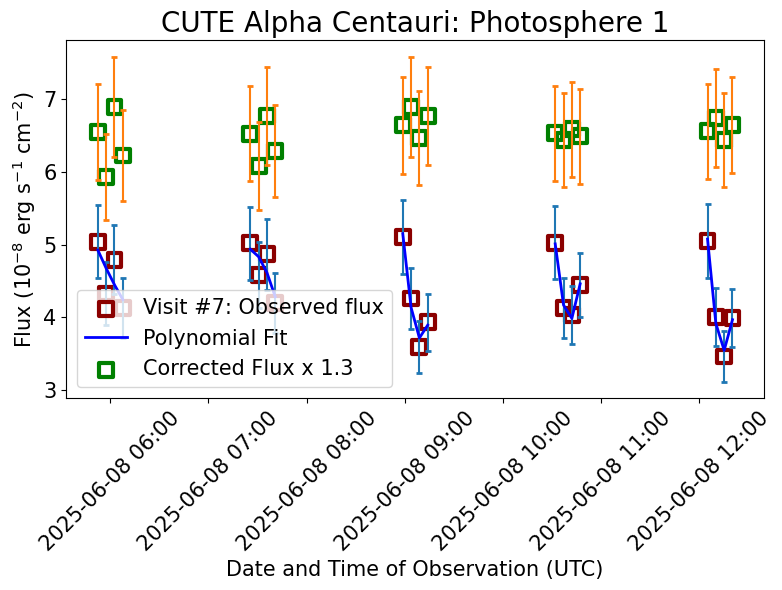

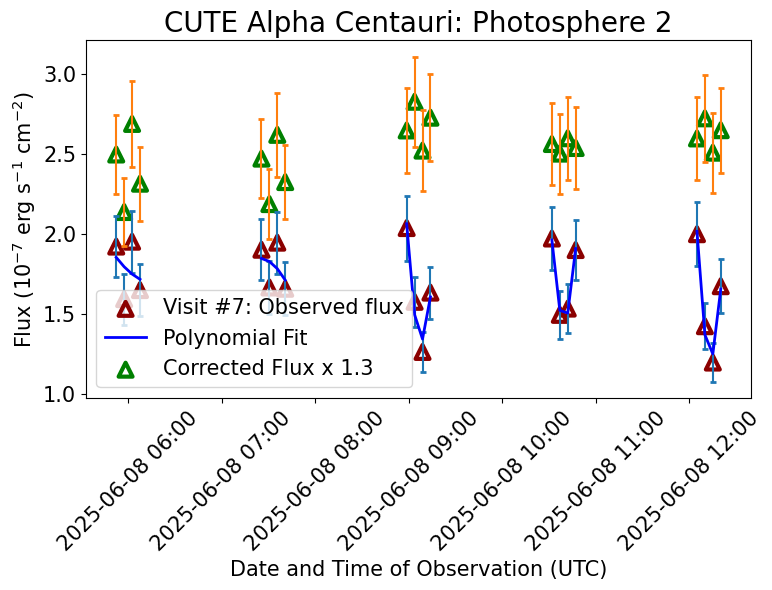

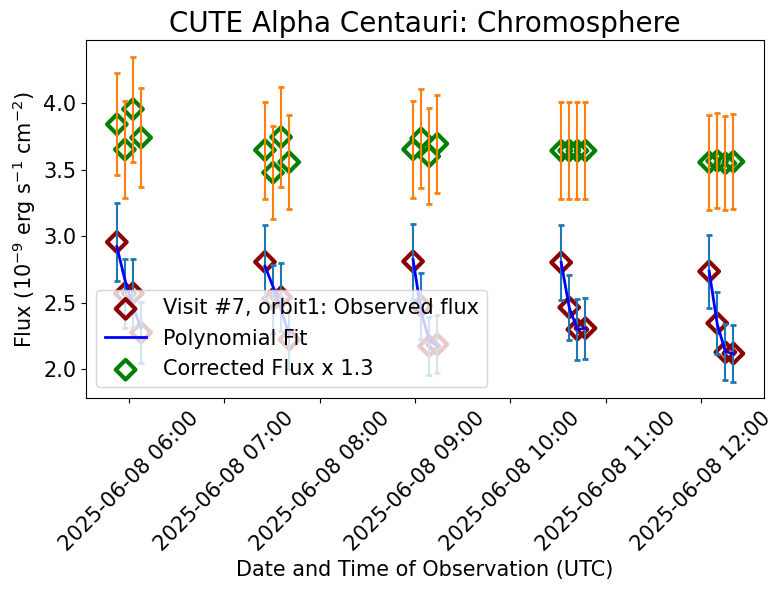

20

In [19]:
#Visit 7    
#Try polyfit for each visit at a time

for i in range(nfiles7):
    flux        = cute_ff7[:,i]
    ww          = cute_wavesol - 2
    ind         = np.where((ww >= 2550) & (ww <= 3255))
    fluxtot     = integrate.simpson(flux[ind],ww[ind])
    totflux7[i] = fluxtot
    ind2        = np.where((ww >= 2550) & (ww < 2790))
    fluxtot     = integrate.simpson(flux[ind2],ww[ind2])
    phot1_7[i]  = fluxtot
    ind3        = np.where((ww >= 2790) & (ww <= 2805))
    fluxtot     = integrate.simpson(flux[ind3],ww[ind3])
    chrom7[i]   = fluxtot
    ind4        = np.where((ww > 2805) & (ww <= 3255))
    fluxtot     = integrate.simpson(flux[ind4],ww[ind4])
    phot2_7[i]  = fluxtot
    
#Refer to Visit 4 for an explanation of the arrays and the steps
tarr17   = timearr7[0:4]
farr17   = phot1_7[0:4] 
farr172  = phot2_7[0:4]
farr173  = chrom7[0:4]
result11 = np.polyfit(tarr17,farr17,2) 
result21 = np.polyfit(tarr17,farr172,2)
result31 = np.polyfit(tarr17,farr173,2)
poly17   = result11[0]*tarr17**2 + result11[1]*tarr17 + result11[2]
poly172  = result21[0]*tarr17**2 + result21[1]*tarr17 + result21[2]
poly173  = result31[0]*tarr17**2 + result31[1]*tarr17 + result31[2]
norm17   = poly17.max()
norm172  = poly172.max()
norm173  = poly173.max()
poly17   = poly17/norm17 
poly172  = poly172/norm172 
poly173  = poly173/norm173 
corr17   = farr17/poly17
corr172  = farr172/poly172
corr173  = farr173/poly173

tarr27   = timearr7[4:8]
farr27   = phot1_7[4:8] 
farr272  = phot2_7[4:8]
farr273  = chrom7[4:8]
result12 = np.polyfit(tarr27,farr27,2) 
result22 = np.polyfit(tarr27,farr272,2)
result32 = np.polyfit(tarr27,farr273,2)
poly27   = result12[0]*tarr27**2 + result12[1]*tarr27 + result12[2]
poly272  = result22[0]*tarr27**2 + result22[1]*tarr27 + result22[2]
poly273  = result32[0]*tarr27**2 + result32[1]*tarr27 + result32[2]
norm27   = poly27.max()
norm272  = poly272.max()
norm273  = poly273.max()
poly27   = poly27/norm27
poly272  = poly272/norm272 
poly273  = poly273/norm273 
corr27   = farr27/poly27
corr272  = farr272/poly272
corr273  = farr273/poly273

tarr37   = timearr7[8:12]
farr37   = phot1_7[8:12] 
farr372  = phot2_7[8:12]
farr373  = chrom7[8:12]
result13 = np.polyfit(tarr37,farr37,2)
result23 = np.polyfit(tarr37,farr372,2)
result33 = np.polyfit(tarr37,farr373,2) 
poly37   = result13[0]*tarr37**2 + result13[1]*tarr37 + result13[2]
poly372  = result23[0]*tarr37**2 + result23[1]*tarr37 + result23[2]
poly373  = result33[0]*tarr37**2 + result33[1]*tarr37 + result33[2]
norm37   = poly37.max()
norm372  = poly372.max()
norm373  = poly373.max()
poly37   = poly37/norm37
poly372  = poly372/norm372 
poly373  = poly373/norm373 
corr37   = farr37/poly37
corr372  = farr372/poly372
corr373  = farr373/poly373

tarr47   = timearr7[12:16]
farr47   = phot1_7[12:16] 
farr472  = phot2_7[12:16]
farr473  = chrom7[12:16]
result14 = np.polyfit(tarr47,farr47,2) 
result24 = np.polyfit(tarr47,farr472,2)
result34 = np.polyfit(tarr47,farr473,2)
poly47   = result14[0]*tarr47**2 + result14[1]*tarr47 + result14[2]
poly472  = result24[0]*tarr47**2 + result24[1]*tarr47 + result24[2]
poly473  = result34[0]*tarr47**2 + result34[1]*tarr47 + result34[2]
norm47   = poly47.max()
norm472  = poly472.max()
norm473  = poly473.max()
poly47   = poly47/norm47
poly472  = poly472/norm472 
poly473  = poly473/norm473 
corr47   = farr47/poly47
corr472  = farr472/poly472
corr473  = farr473/poly473

tarr57   = timearr7[16:20]
farr57   = phot1_7[16:20] 
farr572  = phot2_7[16:20]
farr573  = chrom7[16:20]
result15 = np.polyfit(tarr57,farr57,2) 
result25 = np.polyfit(tarr57,farr572,2)
result35 = np.polyfit(tarr57,farr573,2)
poly57   = result15[0]*tarr57**2 + result15[1]*tarr57 + result15[2]
poly572  = result25[0]*tarr57**2 + result25[1]*tarr57 + result25[2]
poly573  = result35[0]*tarr57**2 + result35[1]*tarr57 + result35[2]
norm57   = poly57.max()
norm572  = poly572.max()
norm573  = poly573.max()
poly57   = poly57/norm57
poly572  = poly572/norm572 
poly573  = poly573/norm573 
corr57   = farr57/poly57
corr572  = farr572/poly572
corr573  = farr573/poly573




# corflux7  = np.concatenate((corr17,corr27,corr37,corr47,corr57))
# corflux72 = np.concatenate((corr172,corr272,corr372,corr472,corr572))
# corflux73 = np.concatenate((corr173,corr273,corr373,corr473,corr573))

corflux7  = np.concatenate((corr17,corr27,corr37,corr47,corr57))
corflux72 = np.concatenate((corr172,corr272,corr372,corr472,corr572))
corflux73 = np.concatenate((corr173,corr273,corr373,corr473,corr573))
# corflux7  = np.append(corflux7,corr87) 
# corflux72 = np.append(corflux72,corr872)
# corflux73 = np.append(corflux73,corr873)  



#Photosphere 1
#Plot the uncorrected vs corrected flux for all orbits in visit 7
fig,ax = plt.subplots(figsize=(8,6))
title  = 'CUTE Alpha Centauri: Photosphere 1'
ax.set_title(title,fontsize=20)
ax.tick_params(axis='both', which='major', labelsize=15) 
ax.set_xlabel('Date and Time of Observation (UTC)',fontsize=15)
ax.set_ylabel('Flux (10$^{-8}$ erg s$^{-1}$ cm$^{-2}$)',fontsize=15)
# ax.set_ylim(0,6)
ax.scatter(dates7,phot1_7*1.e8, label='Visit #7: Observed flux', marker='s',edgecolors='darkred',s=100,facecolors='none',linewidths=3)
ax.errorbar(dates7,phot1_7*1.e8, yerr=0.1*phot1_7*1.e8,linestyle='none',capthick=2,capsize=2)
ax.plot(dates7[0:4], poly17*norm17*1.e8, color='blue', label='Polynomial Fit',lw=2)
ax.plot(dates7[4:8], poly27*norm27*1.e8, color='blue',lw=2)
ax.plot(dates7[8:12], poly37*norm37*1.e8, color='blue',lw=2)
ax.plot(dates7[12:16], poly47*norm47*1.e8, color='blue',lw=2)
ax.plot(dates7[16:20], poly57*norm57*1.e8, color='blue',lw=2)
ax.scatter(dates7,corflux7*1.3*1.e8, label='Corrected Flux x 1.3', marker='s',edgecolors='green',s=100,facecolors='none',linewidths=3)
ax.errorbar(dates7,corflux7*1.3*1.e8, yerr=0.1*corflux7*1.3*1.e8,linestyle='none',capthick=2,capsize=2)
# Format x-axis
date_format = mdates.DateFormatter("%Y-%m-%d %H:%M")  # Customize format as needed
ax.xaxis.set_major_formatter(date_format)
plt.xticks(rotation=45)  # Rotate labels if needed
ax.legend(fontsize=15,loc=3)
fig.tight_layout()
plt.show()

#Photosphere 2
#Plot the uncorrected vs corrected flux for all orbits in visit 7
fig,ax = plt.subplots(figsize=(8,6))
title  = 'CUTE Alpha Centauri: Photosphere 2'
ax.set_title(title,fontsize=20)
ax.tick_params(axis='both', which='major', labelsize=15) 
ax.set_xlabel('Date and Time of Observation (UTC)',fontsize=15)
ax.set_ylabel('Flux (10$^{-7}$ erg s$^{-1}$ cm$^{-2}$)',fontsize=15)
# ax.set_ylim(0,2.5)
ax.scatter(dates7,phot2_7*1.e7, label='Visit #7: Observed flux', marker='^',edgecolors='darkred',s=100,facecolors='none',linewidths=3)
ax.errorbar(dates7,phot2_7*1.e7, yerr=0.1*phot2_7*1.e7,linestyle='none',capthick=2,capsize=2)
ax.plot(dates7[0:4], poly172*norm172*1.e7, color='blue', label='Polynomial Fit',lw=2)
ax.plot(dates7[4:8], poly272*norm272*1.e7, color='blue',lw=2)
ax.plot(dates7[8:12], poly372*norm372*1.e7, color='blue',lw=2)
ax.plot(dates7[12:16], poly472*norm472*1.e7, color='blue',lw=2)
ax.plot(dates7[16:20], poly572*norm572*1.e7, color='blue',lw=2)
ax.scatter(dates7,corflux72*1.3*1.e7, label='Corrected Flux x 1.3', marker='^',edgecolors='green',s=100,facecolors='none',linewidths=3)
ax.errorbar(dates7,corflux72*1.3*1.e7, yerr=0.1*corflux72*1.3*1.e7,linestyle='none',capthick=2,capsize=2)
# Format x-axis
date_format = mdates.DateFormatter("%Y-%m-%d %H:%M")  # Customize format as needed
ax.xaxis.set_major_formatter(date_format)
plt.xticks(rotation=45)  # Rotate labels if needed
ax.legend(fontsize=15,loc=3)
fig.tight_layout()
plt.show()

#Chromosphere
fig,ax = plt.subplots(figsize=(8,6))
title  = 'CUTE Alpha Centauri: Chromosphere'
ax.set_title(title,fontsize=20)
ax.tick_params(axis='both', which='major', labelsize=15) 
ax.set_xlabel('Date and Time of Observation (UTC)',fontsize=15)
ax.set_ylabel('Flux (10$^{-9}$ erg s$^{-1}$ cm$^{-2}$)',fontsize=15)
# ax.set_ylim(0,3.0)
ax.scatter(dates7,chrom7*1.e9, label='Visit #7, orbit1: Observed flux', marker='D',edgecolors='darkred',s=100,facecolors='none',linewidths=3)
ax.errorbar(dates7,chrom7*1.e9, yerr=0.1*chrom7*1.e9,linestyle='none',capthick=2,capsize=2)
ax.plot(dates7[0:4], poly173*norm173*1.e9, color='blue', label='Polynomial Fit',lw=2)
ax.plot(dates7[4:8], poly273*norm273*1.e9, color='blue',lw=2)
ax.plot(dates7[8:12], poly373*norm373*1.e9, color='blue',lw=2)
ax.plot(dates7[12:16], poly473*norm473*1.e9, color='blue',lw=2)
ax.plot(dates7[16:20], poly573*norm573*1.e9, color='blue',lw=2)

ax.scatter(dates7,corflux73*1.3*1.e9, label='Corrected Flux x 1.3', marker='D',edgecolors='green',s=100,facecolors='none',linewidths=3)
ax.errorbar(dates7,corflux73*1.3*1.e9, yerr=0.1*corflux73*1.3*1.e9,linestyle='none',capthick=2,capsize=2)
# Format x-axis
date_format = mdates.DateFormatter("%Y-%m-%d %H:%M")  # Customize format as needed
ax.xaxis.set_major_formatter(date_format)
plt.xticks(rotation=45)  # Rotate labels if needed
ax.legend(fontsize=15,loc=3)
fig.tight_layout()
plt.show()


# #Plotting the corrected Photosphere 1, Photosphere 2 and Chromosphere for visit 7
# fig,ax = plt.subplots(figsize=(8,6))
# title  = 'CUTE Alpha Centauri Observations: Visit #7'
# ax.set_title(title,fontsize=20)
# ax.tick_params(axis='both', which='major', labelsize=15) 
# ax.set_xlabel('Date and Time of Observation (UTC)',fontsize=15)
# ax.set_ylabel('Flux (erg s$^{-1}$ cm$^{-2}$)',fontsize=15)
# ax.set_yscale('log')
# ax.scatter(dates7,corflux7, label='Photosphere 1', marker='s',edgecolors='green',s=100,facecolors='none',linewidths=3)
# ax.errorbar(dates7,corflux7, yerr=0.1*corflux7,linestyle='none',capthick=2,capsize=2)
# ax.scatter(dates7,corflux72, label='Photosphere 2', marker='^',edgecolors='darkred',s=100,facecolors='none',linewidths=3)
# ax.errorbar(dates7,corflux72, yerr=0.1*corflux72,linestyle='none',capthick=2,capsize=2)
# ax.scatter(dates7,corflux73, label='Chromosphere', marker='D',edgecolors='darkblue',s=100,facecolors='none',linewidths=3)
# ax.errorbar(dates7,corflux73, yerr=0.1*corflux73,linestyle='none',capthick=2,capsize=2)
# # Format x-axis
# date_format = mdates.DateFormatter("%Y-%m-%d %H:%M")  # Customize format as needed
# ax.xaxis.set_major_formatter(date_format)
# plt.xticks(rotation=45)  # Rotate labels if needed
# ax.legend(fontsize=15,bbox_to_anchor=(0.4,0.5))
# fig.tight_layout()
# plt.show()

# ax.set_xlabel('Date and Time of Observation (UTC)',fontsize=15)
# ax.set_ylabel('Flux (10$^{-7}$ erg s$^{-1}$ cm$^{-2}$)',fontsize=15)
len(corflux7)

# Visit 8

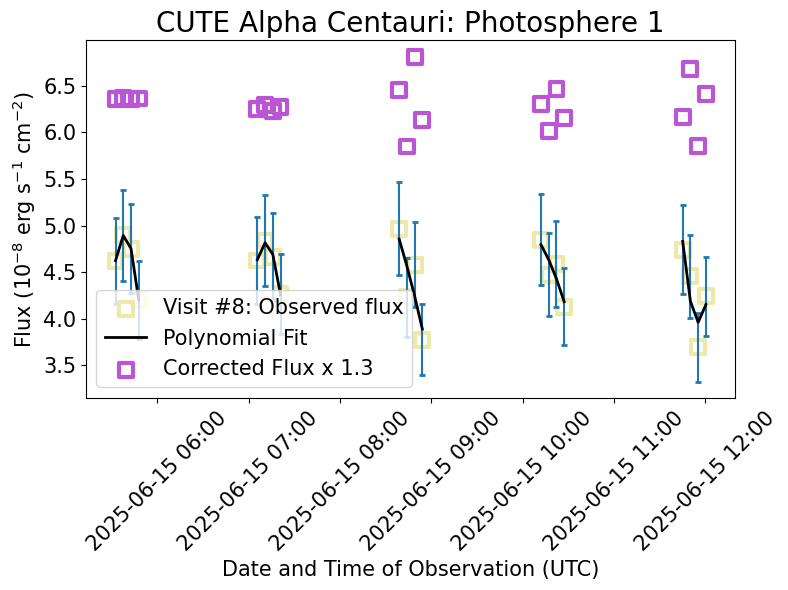

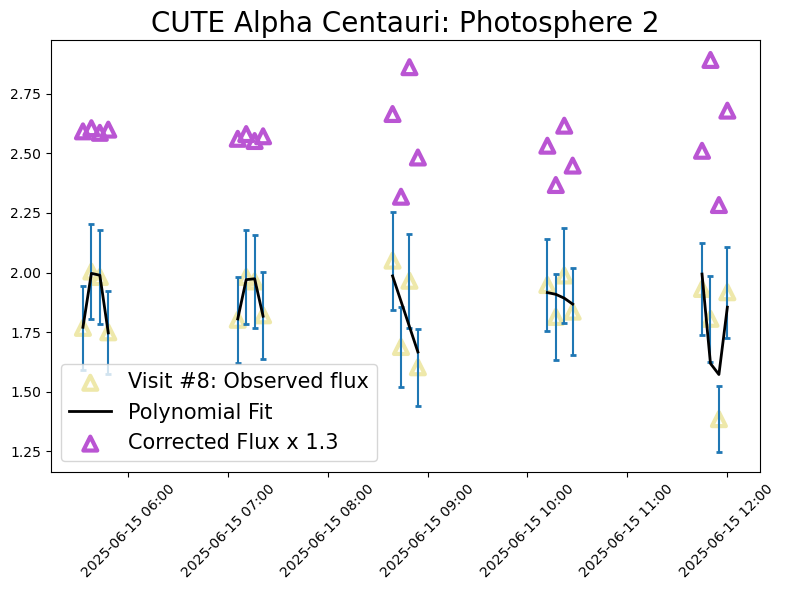

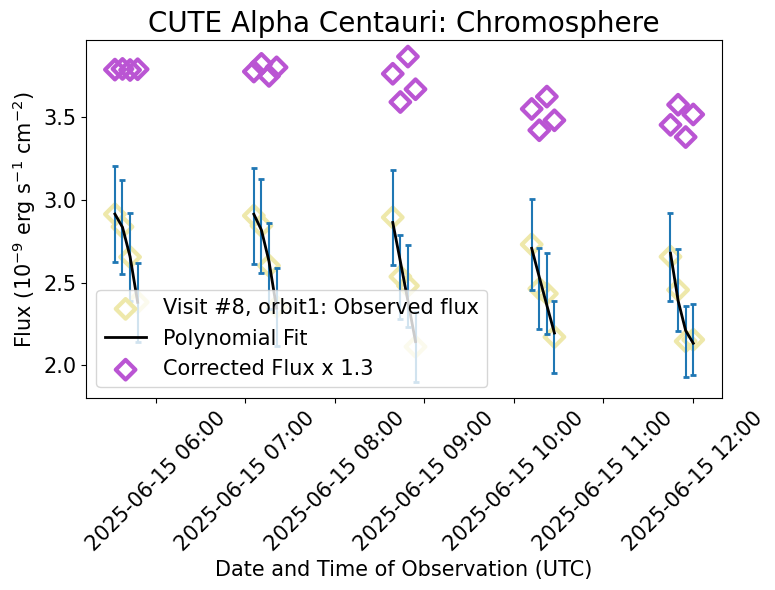

In [20]:
#Visit 8    
#Try polyfit for each visit at a time

for i in range(nfiles8):
    flux        = cute_ff8[:,i]
    ww          = cute_wavesol - 2
    ind         = np.where((ww >= 2550) & (ww <= 3255))
    fluxtot     = integrate.simpson(flux[ind],ww[ind])
    totflux8[i] = fluxtot
    ind2        = np.where((ww >= 2550) & (ww < 2790))
    fluxtot     = integrate.simpson(flux[ind2],ww[ind2])
    phot1_8[i]  = fluxtot
    ind3        = np.where((ww >= 2790) & (ww <= 2805))
    fluxtot     = integrate.simpson(flux[ind3],ww[ind3])
    chrom8[i]   = fluxtot
    ind4        = np.where((ww > 2805) & (ww <= 3255))
    fluxtot     = integrate.simpson(flux[ind4],ww[ind4])
    phot2_8[i]  = fluxtot

#Refer to Visit 4 for an explanation of the arrays and the steps
tarr18   = timearr8[0:4]
farr18   = phot1_8[0:4] 
farr182  = phot2_8[0:4]
farr183  = chrom8[0:4]
result11 = np.polyfit(tarr18,farr18,2) 
result21 = np.polyfit(tarr18,farr182,2)
result31 = np.polyfit(tarr18,farr183,2)
poly18   = result11[0]*tarr18**2 + result11[1]*tarr18 + result11[2]
poly182  = result21[0]*tarr18**2 + result21[1]*tarr18 + result21[2]
poly183  = result31[0]*tarr18**2 + result31[1]*tarr18 + result31[2]
norm18   = poly18.max()
norm182  = poly182.max()
norm183  = poly183.max()
poly18   = poly18/norm18 
poly182  = poly182/norm182 
poly183  = poly183/norm183 
corr18   = farr18/poly18
corr182  = farr182/poly182
corr183  = farr183/poly183

tarr28   = timearr8[4:8]
farr28   = phot1_8[4:8] 
farr282  = phot2_8[4:8]
farr283  = chrom8[4:8]
result12 = np.polyfit(tarr28,farr28,2) 
result22 = np.polyfit(tarr28,farr282,2)
result32 = np.polyfit(tarr28,farr283,2)
poly28   = result12[0]*tarr28**2 + result12[1]*tarr28 + result12[2]
poly282  = result22[0]*tarr28**2 + result22[1]*tarr28 + result22[2]
poly283  = result32[0]*tarr28**2 + result32[1]*tarr28 + result32[2]
norm28   = poly28.max()
norm282  = poly282.max()
norm283  = poly283.max()
poly28   = poly28/norm28
poly282  = poly282/norm282 
poly283  = poly283/norm283 
corr28   = farr28/poly28
corr282  = farr282/poly282
corr283  = farr283/poly283

tarr38   = timearr8[8:12]
farr38   = phot1_8[8:12] 
farr382  = phot2_8[8:12]
farr383  = chrom8[8:12]
result13 = np.polyfit(tarr38,farr38,2)
result23 = np.polyfit(tarr38,farr382,2)
result33 = np.polyfit(tarr38,farr383,2) 
poly38   = result13[0]*tarr38**2 + result13[1]*tarr38 + result13[2]
poly382  = result23[0]*tarr38**2 + result23[1]*tarr38 + result23[2]
poly383  = result33[0]*tarr38**2 + result33[1]*tarr38 + result33[2]
norm38   = poly38.max()
norm382  = poly382.max()
norm383  = poly383.max()
poly38   = poly38/norm38
poly382  = poly382/norm382 
poly383  = poly383/norm383 
corr38   = farr38/poly38
corr382  = farr382/poly382
corr383  = farr383/poly383

tarr48   = timearr8[12:16]
farr48   = phot1_8[12:16] 
farr482  = phot2_8[12:16]
farr483  = chrom8[12:16]
result14 = np.polyfit(tarr48,farr48,2) 
result24 = np.polyfit(tarr48,farr482,2)
result34 = np.polyfit(tarr48,farr483,2)
poly48   = result14[0]*tarr48**2 + result14[1]*tarr48 + result14[2]
poly482  = result24[0]*tarr48**2 + result24[1]*tarr48 + result24[2]
poly483  = result34[0]*tarr48**2 + result34[1]*tarr48 + result34[2]
norm48   = poly48.max()
norm482  = poly482.max()
norm483  = poly483.max()
poly48   = poly48/norm48
poly482  = poly482/norm482 
poly483  = poly483/norm483 
corr48   = farr48/poly48
corr482  = farr482/poly482
corr483  = farr483/poly483

tarr58    = timearr8[16:20]
farr58   = phot1_8[16:20]
farr582  = phot2_8[16:20]
farr583  = chrom8[16:20]
result15 = np.polyfit(tarr58,farr58,2)
result25 = np.polyfit(tarr58,farr582,2)
result35 = np.polyfit(tarr58,farr583,2) 
poly58   = result15[0]*tarr58**2 + result15[1]*tarr58 + result15[2]
poly582  = result25[0]*tarr58**2 + result25[1]*tarr58 + result25[2]
poly583  = result35[0]*tarr58**2 + result35[1]*tarr58 + result35[2]
norm58   = poly58.max()
norm582  = poly582.max()
norm583  = poly583.max()
poly58   = poly58/norm58
poly582  = poly582/norm582 
poly583  = poly583/norm583 
corr58   = farr58/poly58
corr582  = farr582/poly582
corr583  = farr583/poly583

# corflux8  = np.concatenate((corr18,corr28,corr38))
# corflux82 = np.concatenate((corr182,corr282,corr382))
# corflux83 = np.concatenate((corr183,corr283,corr383))
# corflux8  = np.append(corflux8,corr48) 
# corflux82 = np.append(corflux82,corr482)
# corflux83 = np.append(corflux83,corr483) 
# corflux8  = np.append(corflux8,corr58) 
# corflux82 = np.append(corflux82,corr582)
# corflux83 = np.append(corflux83,corr583) 

corflux8  = np.concatenate((corr18,corr28,corr38))
corflux82 = np.concatenate((corr182,corr282,corr382))
corflux83 = np.concatenate((corr183,corr283,corr383))
corflux8  = np.append(corflux8,corr48) 
corflux82 = np.append(corflux82,corr482)
corflux83 = np.append(corflux83,corr483) 
corflux8  = np.append(corflux8,corr58) 
corflux82 = np.append(corflux82,corr582)
corflux83 = np.append(corflux83,corr583) 

#Photosphere 1
#Plot the uncorrected vs corrected flux for all orbits in visit 8
fig,ax = plt.subplots(figsize=(8,6))
title  = 'CUTE Alpha Centauri: Photosphere 1'
ax.set_title(title,fontsize=20)
ax.tick_params(axis='both', which='major', labelsize=15) 
ax.set_xlabel('Date and Time of Observation (UTC)',fontsize=15)
ax.set_ylabel('Flux (10$^{-8}$ erg s$^{-1}$ cm$^{-2}$)',fontsize=15)
# ax.set_ylim(0,6)
ax.scatter(dates8,phot1_8*1.e8, label='Visit #8: Observed flux', marker='s',edgecolors='palegoldenrod',s=100,facecolors='none',linewidths=3)
ax.errorbar(dates8,phot1_8*1.e8, yerr=0.1*phot1_8*1.e8,linestyle='none',capthick=2,capsize=2)
ax.plot(dates8[0:4], poly18*norm18*1.e8, color='black', label='Polynomial Fit',lw=2)
ax.plot(dates8[4:8], poly28*norm28*1.e8, color='black',lw=2)
ax.plot(dates8[8:12], poly38*norm38*1.e8, color='black',lw=2)
ax.plot(dates8[12:16], poly48*norm48*1.e8, color='black',lw=2)
ax.plot(dates8[16:20], poly58*norm58*1.e8, color='black',lw=2)
ax.scatter(dates8,corflux8*1.3*1.e8, label='Corrected Flux x 1.3', marker='s',edgecolors='mediumorchid',s=100,facecolors='none',linewidths=3)
# ax.errorbar(dates8,corflux8*1.3*1.e8, yerr=0.1*corflux8*1.3*1.e8,linestyle='none',capthick=2,capsize=2)
# Format x-axis
date_format = mdates.DateFormatter("%Y-%m-%d %H:%M")  # Customize format as needed
ax.xaxis.set_major_formatter(date_format)
plt.xticks(rotation=45)  # Rotate labels if needed
ax.legend(fontsize=15,loc=3)
fig.tight_layout()

plt.show()

#Photosphere 2
#Plot the uncorrected vs corrected flux for all orbits in visit 8
fig,ax = plt.subplots(figsize=(8,6))
title  = 'CUTE Alpha Centauri: Photosphere 2'
ax.set_title(title,fontsize=20)
ax.tick_params
ax.scatter(dates8,phot2_8*1.e7, label='Visit #8: Observed flux', marker='^',edgecolors='palegoldenrod',s=100,facecolors='none',linewidths=3)
ax.errorbar(dates8,phot2_8*1.e7, yerr=0.1*phot2_8*1.e7,linestyle='none',capthick=2,capsize=2)
ax.plot(dates8[0:4], poly182*norm182*1.e7, color='black', label='Polynomial Fit',lw=2)
ax.plot(dates8[4:8], poly282*norm282*1.e7, color='black',lw=2)
ax.plot(dates8[8:12], poly382*norm382*1.e7, color='black',lw=2)
ax.plot(dates8[12:16], poly482*norm482*1.e7, color='black',lw=2)
ax.plot(dates8[16:20], poly582*norm582*1.e7, color='black',lw=2)
ax.scatter(dates8,corflux82*1.3*1.e7, label='Corrected Flux x 1.3', marker='^',edgecolors='mediumorchid',s=100,facecolors='none',linewidths=3)
# ax.errorbar(dates8,corflux82*1.3*1.e7, yerr=0.1*corflux82*1.3*1.e7,linestyle='none',capthick=2,capsize=2)
# Format x-axis
date_format = mdates.DateFormatter("%Y-%m-%d %H:%M")  # Customize format as needed
ax.xaxis.set_major_formatter(date_format)
plt.xticks(rotation=45)  # Rotate labels if needed
ax.legend(fontsize=15,loc=3)
fig.tight_layout()

plt.show()

#Chromosphere
fig,ax = plt.subplots(figsize=(8,6))
title  = 'CUTE Alpha Centauri: Chromosphere'
ax.set_title(title,fontsize=20)
ax.tick_params(axis='both', which='major', labelsize=15) 
ax.set_xlabel('Date and Time of Observation (UTC)',fontsize=15)
ax.set_ylabel('Flux (10$^{-9}$ erg s$^{-1}$ cm$^{-2}$)',fontsize=15)
# ax.set_ylim(0,3.0)
ax.scatter(dates8,chrom8*1.e9, label='Visit #8, orbit1: Observed flux', marker='D',edgecolors='palegoldenrod',s=100,facecolors='none',linewidths=3)
ax.errorbar(dates8,chrom8*1.e9, yerr=0.1*chrom8*1.e9,linestyle='none',capthick=2,capsize=2)
ax.plot(dates8[0:4], poly183*norm183*1.e9, color='black', label='Polynomial Fit',lw=2)
ax.plot(dates8[4:8], poly283*norm283*1.e9, color='black',lw=2)
ax.plot(dates8[8:12], poly383*norm383*1.e9, color='black',lw=2)
ax.plot(dates8[12:16], poly483*norm483*1.e9, color='black',lw=2)
ax.plot(dates8[16:20], poly583*norm583*1.e9, color='black',lw=2)
ax.scatter(dates8,corflux83*1.3*1.e9, label='Corrected Flux x 1.3', marker='D',edgecolors='mediumorchid',s=100,facecolors='none',linewidths=3)
# ax.errorbar(dates8,corflux83*1.3*1.e9, yerr=0.1*corflux83*1.3*1.e9,linestyle='none',capthick=2,capsize=2)
# Format x-axis
date_format = mdates.DateFormatter("%Y-%m-%d %H:%M")  # Customize format as needed
ax.xaxis.set_major_formatter(date_format)
plt.xticks(rotation=45)  # Rotate labels if needed
ax.legend(fontsize=15,loc=3)
fig.tight_layout()

plt.show()

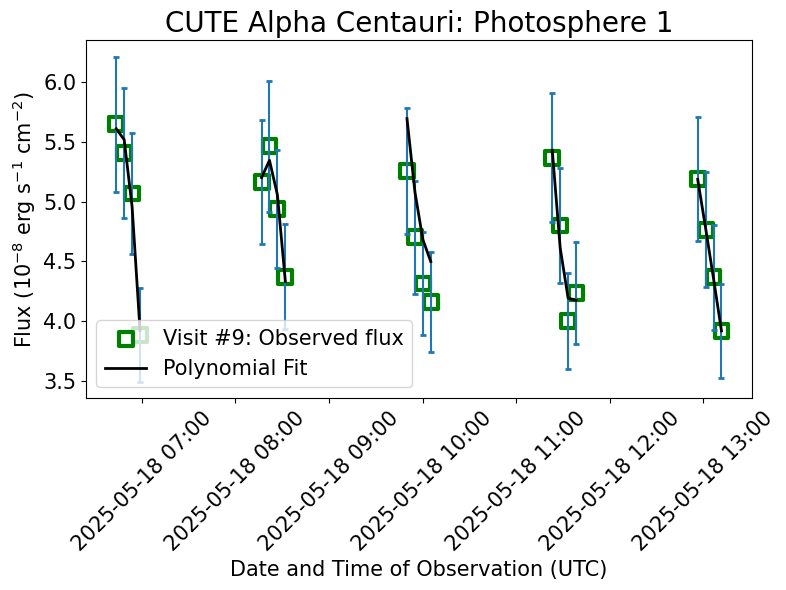

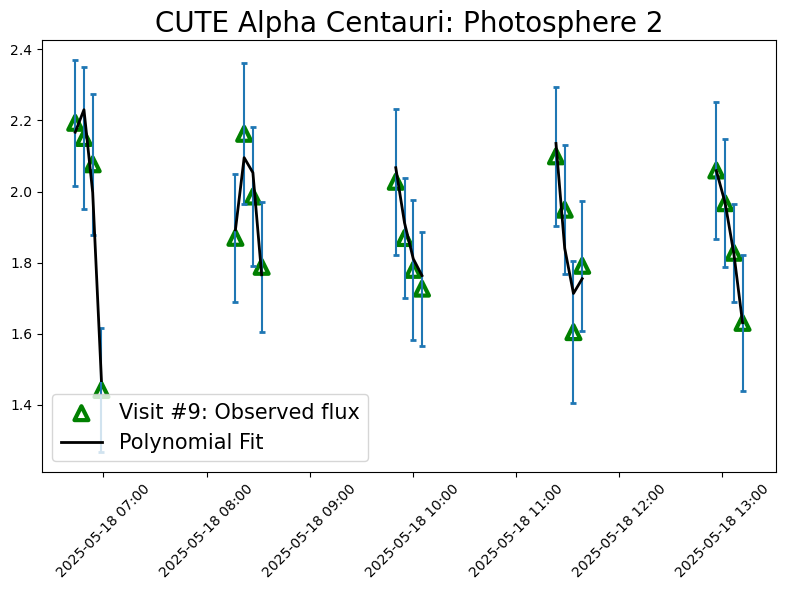

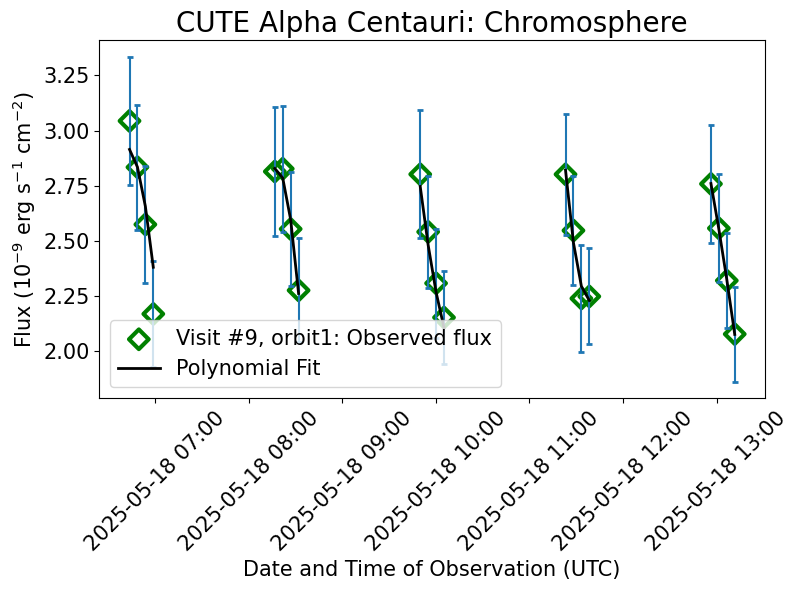

In [21]:
#Visit 8    
#Try polyfit for each visit at a time

for i in range(nfiles9):
    flux        = cute_ff9[:,i]
    ww          = cute_wavesol - 9
    ind         = np.where((ww >= 2550) & (ww <= 3255))
    fluxtot     = integrate.simpson(flux[ind],ww[ind])
    totflux9[i] = fluxtot
    ind2        = np.where((ww >= 2550) & (ww < 2790))
    fluxtot     = integrate.simpson(flux[ind2],ww[ind2])
    phot1_9[i]  = fluxtot
    ind3        = np.where((ww >= 2790) & (ww <= 2805))
    fluxtot     = integrate.simpson(flux[ind3],ww[ind3])
    chrom9[i]   = fluxtot
    ind4        = np.where((ww > 2805) & (ww <= 3255))
    fluxtot     = integrate.simpson(flux[ind4],ww[ind4])
    phot2_9[i]  = fluxtot

#Refer to Visit 4 for an explanation of the arrays and the steps
tarr19   = timearr9[0:4]
farr19   = phot1_9[0:4] 
farr192  = phot2_9[0:4]
farr193  = chrom8[0:4]
result11 = np.polyfit(tarr19,farr19,2) 
result21 = np.polyfit(tarr19,farr192,2)
result31 = np.polyfit(tarr19,farr193,2)
poly19   = result11[0]*tarr19**2 + result11[1]*tarr19 + result11[2]
poly192  = result21[0]*tarr19**2 + result21[1]*tarr19 + result21[2]
poly193  = result31[0]*tarr19**2 + result31[1]*tarr19 + result31[2]
norm19   = poly19.max()
norm192  = poly192.max()
norm193  = poly193.max()
poly19   = poly19/norm19 
poly192  = poly192/norm192 
poly193  = poly193/norm193 
corr19   = farr19/poly19
corr192  = farr192/poly192
corr193  = farr193/poly193

tarr29   = timearr9[4:8]
farr29   = phot1_9[4:8] 
farr292  = phot2_9[4:8]
farr293  = chrom9[4:8]
result12 = np.polyfit(tarr29,farr29,2) 
result22 = np.polyfit(tarr29,farr292,2)
result32 = np.polyfit(tarr29,farr293,2)
poly29   = result12[0]*tarr29**2 + result12[1]*tarr29 + result12[2]
poly292  = result22[0]*tarr29**2 + result22[1]*tarr29 + result22[2]
poly293  = result32[0]*tarr29**2 + result32[1]*tarr29 + result32[2]
norm29   = poly29.max()
norm292  = poly292.max()
norm293  = poly293.max()
poly29   = poly29/norm29
poly292  = poly292/norm292 
poly293  = poly293/norm293 
corr29   = farr29/poly29
corr292  = farr292/poly292
corr293  = farr293/poly293

tarr39   = timearr9[8:12]
farr39   = phot1_9[8:12] 
farr392  = phot2_9[8:12]
farr393  = chrom9[8:12]
result13 = np.polyfit(tarr39,farr39,2)
result23 = np.polyfit(tarr39,farr392,2)
result33 = np.polyfit(tarr39,farr393,2) 
poly39   = result13[0]*tarr39**2 + result13[1]*tarr39 + result13[2]
poly392  = result23[0]*tarr39**2 + result23[1]*tarr39 + result23[2]
poly393  = result33[0]*tarr39**2 + result33[1]*tarr39 + result33[2]
norm39   = poly39.max()
norm392  = poly392.max()
norm393  = poly393.max()
poly39   = poly39/norm38
poly392  = poly392/norm382 
poly393  = poly393/norm383 
corr39   = farr39/poly38
corr392  = farr382/poly382
corr393  = farr383/poly383

tarr49   = timearr9[12:16]
farr49   = phot1_9[12:16] 
farr492  = phot2_9[12:16]
farr493  = chrom9[12:16]
result14 = np.polyfit(tarr49,farr49,2) 
result24 = np.polyfit(tarr49,farr492,2)
result34 = np.polyfit(tarr49,farr493,2)
poly49   = result14[0]*tarr49**2 + result14[1]*tarr49 + result14[2]
poly492  = result24[0]*tarr49**2 + result24[1]*tarr49 + result24[2]
poly493  = result34[0]*tarr49**2 + result34[1]*tarr49 + result34[2]
norm49   = poly49.max()
norm492  = poly492.max()
norm493  = poly493.max()
poly49   = poly49/norm49
poly492  = poly492/norm492 
poly493  = poly493/norm493 
corr49   = farr49/poly49
corr492  = farr492/poly492
corr493  = farr493/poly493

tarr59    = timearr9[16:20]
farr59   = phot1_9[16:20]
farr592  = phot2_9[16:20]
farr593  = chrom9[16:20]
result15 = np.polyfit(tarr59,farr59,2)
result25 = np.polyfit(tarr59,farr592,2)
result35 = np.polyfit(tarr59,farr593,2) 
poly59   = result15[0]*tarr59**2 + result15[1]*tarr59 + result15[2]
poly592  = result25[0]*tarr59**2 + result25[1]*tarr59 + result25[2]
poly593  = result35[0]*tarr59**2 + result35[1]*tarr59 + result35[2]
norm59   = poly59.max()
norm592  = poly592.max()
norm593  = poly593.max()
poly59   = poly59/norm59
poly592  = poly592/norm592 
poly593  = poly593/norm593 
corr59   = farr59/poly59
corr592  = farr592/poly592
corr593  = farr593/poly593

corflux9  = np.concatenate((corr19,corr29,corr39))
corflux92 = np.concatenate((corr192,corr292,corr392))
corflux93 = np.concatenate((corr193,corr293,corr393))
corflux9  = np.append(corflux9,corr49) 
corflux92 = np.append(corflux92,corr492)
corflux93 = np.append(corflux93,corr493) 
corflux9  = np.append(corflux9,corr59) 
corflux92 = np.append(corflux92,corr592)
corflux93 = np.append(corflux93,corr593) 

#Photosphere 1
#Plot the uncorrected vs corrected flux for all orbits in visit 8
fig,ax = plt.subplots(figsize=(8,6))
title  = 'CUTE Alpha Centauri: Photosphere 1'
ax.set_title(title,fontsize=20)
ax.tick_params(axis='both', which='major', labelsize=15) 
ax.set_xlabel('Date and Time of Observation (UTC)',fontsize=15)
ax.set_ylabel('Flux (10$^{-8}$ erg s$^{-1}$ cm$^{-2}$)',fontsize=15)
# ax.set_ylim(0,6)
ax.scatter(dates9,phot1_9*1.e8, label='Visit #9: Observed flux', marker='s',edgecolors='green',s=100,facecolors='none',linewidths=3)
ax.errorbar(dates9,phot1_9*1.e8, yerr=0.1*phot1_9*1.e8,linestyle='none',capthick=2,capsize=2)
ax.plot(dates9[0:4], poly19*norm19*1.e8, color='black', label='Polynomial Fit',lw=2)
ax.plot(dates9[4:8], poly29*norm29*1.e8, color='black',lw=2)
ax.plot(dates9[8:12], poly39*norm39*1.e8, color='black',lw=2)
ax.plot(dates9[12:16], poly49*norm49*1.e8, color='black',lw=2)
ax.plot(dates9[16:20], poly59*norm59*1.e8, color='black',lw=2)
# ax.scatter(dates8,corflux8*1.3*1.e8, label='Corrected Flux x 1.3', marker='s',edgecolors='mediumorchid',s=100,facecolors='none',linewidths=3)
# ax.errorbar(dates8,corflux8*1.3*1.e8, yerr=0.1*corflux8*1.3*1.e8,linestyle='none',capthick=2,capsize=2)
# Format x-axis
date_format = mdates.DateFormatter("%Y-%m-%d %H:%M")  # Customize format as needed
ax.xaxis.set_major_formatter(date_format)
plt.xticks(rotation=45)  # Rotate labels if needed
ax.legend(fontsize=15,loc=3)
fig.tight_layout()

plt.show()

#Photosphere 2
#Plot the uncorrected vs corrected flux for all orbits in visit 8
fig,ax = plt.subplots(figsize=(8,6))
title  = 'CUTE Alpha Centauri: Photosphere 2'
ax.set_title(title,fontsize=20)
ax.tick_params
ax.scatter(dates9,phot2_9*1.e7, label='Visit #9: Observed flux', marker='^',edgecolors='green',s=100,facecolors='none',linewidths=3)
ax.errorbar(dates9,phot2_9*1.e7, yerr=0.1*phot2_8*1.e7,linestyle='none',capthick=2,capsize=2)
ax.plot(dates9[0:4], poly192*norm192*1.e7, color='black', label='Polynomial Fit',lw=2)
ax.plot(dates9[4:8], poly292*norm292*1.e7, color='black',lw=2)
ax.plot(dates9[8:12], poly392*norm392*1.e7, color='black',lw=2)
ax.plot(dates9[12:16], poly492*norm492*1.e7, color='black',lw=2)
ax.plot(dates9[16:20], poly592*norm592*1.e7, color='black',lw=2)
# ax.scatter(dates8,corflux82*1.3*1.e7, label='Corrected Flux x 1.3', marker='^',edgecolors='mediumorchid',s=100,facecolors='none',linewidths=3)
# ax.errorbar(dates8,corflux82*1.3*1.e7, yerr=0.1*corflux82*1.3*1.e7,linestyle='none',capthick=2,capsize=2)
# Format x-axis
date_format = mdates.DateFormatter("%Y-%m-%d %H:%M")  # Customize format as needed
ax.xaxis.set_major_formatter(date_format)
plt.xticks(rotation=45)  # Rotate labels if needed
ax.legend(fontsize=15,loc=3)
fig.tight_layout()

plt.show()

#Chromosphere
fig,ax = plt.subplots(figsize=(8,6))
title  = 'CUTE Alpha Centauri: Chromosphere'
ax.set_title(title,fontsize=20)
ax.tick_params(axis='both', which='major', labelsize=15) 
ax.set_xlabel('Date and Time of Observation (UTC)',fontsize=15)
ax.set_ylabel('Flux (10$^{-9}$ erg s$^{-1}$ cm$^{-2}$)',fontsize=15)
# ax.set_ylim(0,3.0)
ax.scatter(dates9,chrom9*1.e9, label='Visit #9, orbit1: Observed flux', marker='D',edgecolors='green',s=100,facecolors='none',linewidths=3)
ax.errorbar(dates9,chrom9*1.e9, yerr=0.1*chrom8*1.e9,linestyle='none',capthick=2,capsize=2)
ax.plot(dates9[0:4], poly193*norm193*1.e9, color='black', label='Polynomial Fit',lw=2)
ax.plot(dates9[4:8], poly293*norm293*1.e9, color='black',lw=2)
ax.plot(dates9[8:12], poly393*norm393*1.e9, color='black',lw=2)
ax.plot(dates9[12:16], poly493*norm493*1.e9, color='black',lw=2)
ax.plot(dates9[16:20], poly593*norm593*1.e9, color='black',lw=2)
# ax.scatter(dates8,corflux83*1.3*1.e9, label='Corrected Flux x 1.3', marker='D',edgecolors='mediumorchid',s=100,facecolors='none',linewidths=3)
# ax.errorbar(dates8,corflux83*1.3*1.e9, yerr=0.1*corflux83*1.3*1.e9,linestyle='none',capthick=2,capsize=2)
# Format x-axis
date_format = mdates.DateFormatter("%Y-%m-%d %H:%M")  # Customize format as needed
ax.xaxis.set_major_formatter(date_format)
plt.xticks(rotation=45)  # Rotate labels if needed
ax.legend(fontsize=15,loc=3)
fig.tight_layout()

plt.show()

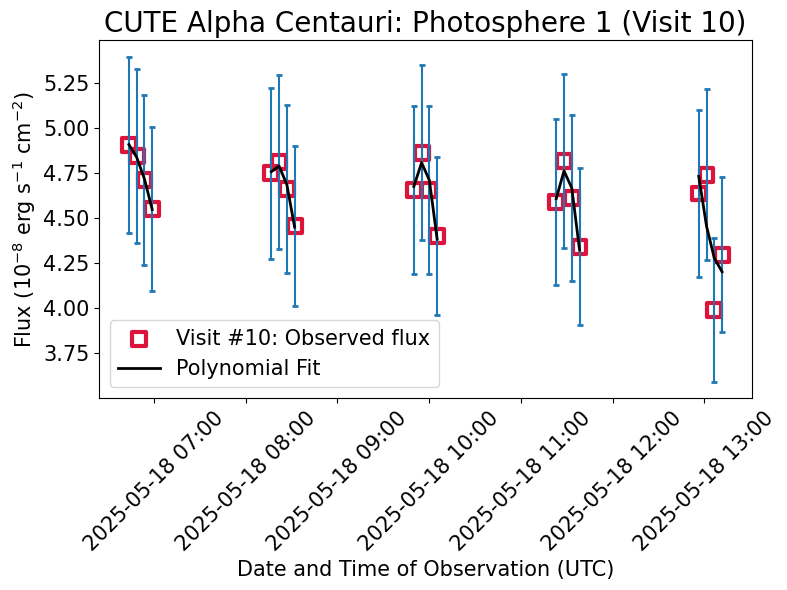

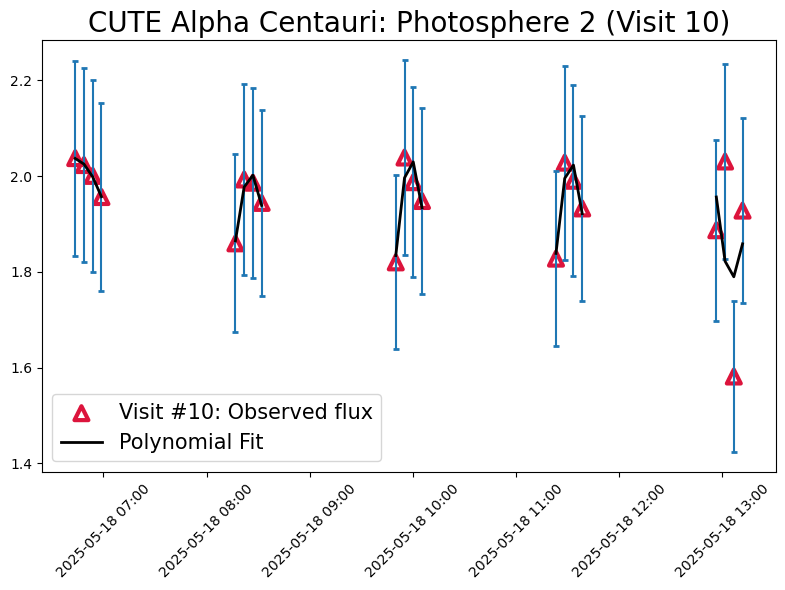

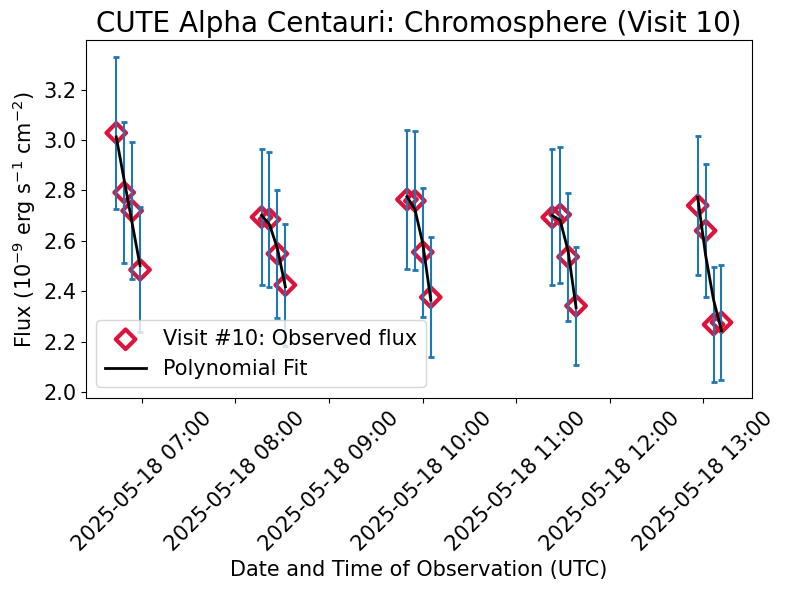

In [22]:
#Visit 10    
#Try polyfit for each visit at a time

for i in range(nfiles10):
    flux        = cute_ff10[:, i]
    ww          = cute_wavesol - 2
    ind         = np.where((ww >= 2550) & (ww <= 3255))
    fluxtot     = integrate.simpson(flux[ind], ww[ind])
    totflux10[i] = fluxtot

    ind2        = np.where((ww >= 2550) & (ww < 2790))
    fluxtot     = integrate.simpson(flux[ind2], ww[ind2])
    phot1_10[i]  = fluxtot

    ind3        = np.where((ww >= 2790) & (ww <= 2805))
    fluxtot     = integrate.simpson(flux[ind3], ww[ind3])
    chrom10[i]   = fluxtot

    ind4        = np.where((ww > 2805) & (ww <= 3255))
    fluxtot     = integrate.simpson(flux[ind4], ww[ind4])
    phot2_10[i]  = fluxtot

#Refer to Visit 4 for an explanation of the arrays and the steps
tarr110   = timearr10[0:4]
farr110   = phot1_10[0:4] 
farr1102  = phot2_10[0:4]
farr1103  = chrom10[0:4]
result110 = np.polyfit(tarr110, farr110, 2) 
result210 = np.polyfit(tarr110, farr1102, 2)
result310 = np.polyfit(tarr110, farr1103, 2)
poly110   = result110[0]*tarr110**2 + result110[1]*tarr110 + result110[2]
poly1102  = result210[0]*tarr110**2 + result210[1]*tarr110 + result210[2]
poly1103  = result310[0]*tarr110**2 + result310[1]*tarr110 + result310[2]
norm110   = poly110.max()
norm1102  = poly1102.max()
norm1103  = poly1103.max()
poly110   = poly110 / norm110 
poly1102  = poly1102 / norm1102 
poly1103  = poly1103 / norm1103 
corr110   = farr110 / poly110
corr1102  = farr1102 / poly1102
corr1103  = farr1103 / poly1103

tarr210   = timearr10[4:8]
farr210   = phot1_10[4:8] 
farr2102  = phot2_10[4:8]
farr2103  = chrom10[4:8]
result120 = np.polyfit(tarr210, farr210, 2) 
result220 = np.polyfit(tarr210, farr2102, 2)
result320 = np.polyfit(tarr210, farr2103, 2)
poly210   = result120[0]*tarr210**2 + result120[1]*tarr210 + result120[2]
poly2102  = result220[0]*tarr210**2 + result220[1]*tarr210 + result220[2]
poly2103  = result320[0]*tarr210**2 + result320[1]*tarr210 + result320[2]
norm210   = poly210.max()
norm2102  = poly2102.max()
norm2103  = poly2103.max()
poly210   = poly210 / norm210
poly2102  = poly2102 / norm2102 
poly2103  = poly2103 / norm2103 
corr210   = farr210 / poly210
corr2102  = farr2102 / poly2102
corr2103  = farr2103 / poly2103

tarr310   = timearr10[8:12]
farr310   = phot1_10[8:12] 
farr3102  = phot2_10[8:12]
farr3103  = chrom10[8:12]
result130 = np.polyfit(tarr310, farr310, 2)
result230 = np.polyfit(tarr310, farr3102, 2)
result330 = np.polyfit(tarr310, farr3103, 2) 
poly310   = result130[0]*tarr310**2 + result130[1]*tarr310 + result130[2]
poly3102  = result230[0]*tarr310**2 + result230[1]*tarr310 + result230[2]
poly3103  = result330[0]*tarr310**2 + result330[1]*tarr310 + result330[2]
norm310   = poly310.max()
norm3102  = poly3102.max()
norm3103  = poly3103.max()
poly310   = poly310 / norm310
poly3102  = poly3102 / norm3102 
poly3103  = poly3103 / norm3103 
corr310   = farr310 / poly310
corr3102  = farr3102 / poly3102
corr3103  = farr3103 / poly3103

tarr410   = timearr10[12:16]
farr410   = phot1_10[12:16] 
farr4102  = phot2_10[12:16]
farr4103  = chrom10[12:16]
result140 = np.polyfit(tarr410, farr410, 2) 
result240 = np.polyfit(tarr410, farr4102, 2)
result340 = np.polyfit(tarr410, farr4103, 2)
poly410   = result140[0]*tarr410**2 + result140[1]*tarr410 + result140[2]
poly4102  = result240[0]*tarr410**2 + result240[1]*tarr410 + result240[2]
poly4103  = result340[0]*tarr410**2 + result340[1]*tarr410 + result340[2]
norm410   = poly410.max()
norm4102  = poly4102.max()
norm4103  = poly4103.max()
poly410   = poly410 / norm410
poly4102  = poly4102 / norm4102 
poly4103  = poly4103 / norm4103 
corr410   = farr410 / poly410
corr4102  = farr4102 / poly4102
corr4103  = farr4103 / poly4103

tarr510   = timearr10[16:20]
farr510   = phot1_10[16:20]
farr5102  = phot2_10[16:20]
farr5103  = chrom10[16:20]
result150 = np.polyfit(tarr510, farr510, 2)
result250 = np.polyfit(tarr510, farr5102, 2)
result350 = np.polyfit(tarr510, farr5103, 2) 
poly510   = result150[0]*tarr510**2 + result150[1]*tarr510 + result150[2]
poly5102  = result250[0]*tarr510**2 + result250[1]*tarr510 + result250[2]
poly5103  = result350[0]*tarr510**2 + result350[1]*tarr510 + result350[2]
norm510   = poly510.max()
norm5102  = poly5102.max()
norm5103  = poly5103.max()
poly510   = poly510 / norm510
poly5102  = poly5102 / norm5102 
poly5103  = poly5103 / norm5103 
corr510   = farr510 / poly510
corr5102  = farr5102 / poly5102
corr5103  = farr5103 / poly5103

corflux10  = np.concatenate((corr110, corr210, corr310))
corflux102 = np.concatenate((corr1102, corr2102, corr3102))
corflux103 = np.concatenate((corr1103, corr2103, corr3103))
corflux10  = np.append(corflux10, corr410) 
corflux102 = np.append(corflux102, corr4102)
corflux103 = np.append(corflux103, corr4103) 
corflux10  = np.append(corflux10, corr510) 
corflux102 = np.append(corflux102, corr5102)
corflux103 = np.append(corflux103, corr5103) 

#Photosphere 1
fig, ax = plt.subplots(figsize=(8,6))
title  = 'CUTE Alpha Centauri: Photosphere 1 (Visit 10)'
ax.set_title(title, fontsize=20)
ax.tick_params(axis='both', which='major', labelsize=15) 
ax.set_xlabel('Date and Time of Observation (UTC)', fontsize=15)
ax.set_ylabel('Flux (10$^{-8}$ erg s$^{-1}$ cm$^{-2}$)', fontsize=15)
ax.scatter(dates10, phot1_10*1.e8, label='Visit #10: Observed flux', marker='s', edgecolors='crimson', s=100, facecolors='none', linewidths=3)
ax.errorbar(dates10, phot1_10*1.e8, yerr=0.1*phot1_10*1.e8, linestyle='none', capthick=2, capsize=2)
ax.plot(dates10[0:4], poly110*norm110*1.e8, color='black', label='Polynomial Fit', lw=2)
ax.plot(dates10[4:8], poly210*norm210*1.e8, color='black', lw=2)
ax.plot(dates10[8:12], poly310*norm310*1.e8, color='black', lw=2)
ax.plot(dates10[12:16], poly410*norm410*1.e8, color='black', lw=2)
ax.plot(dates10[16:20], poly510*norm510*1.e8, color='black', lw=2)
date_format = mdates.DateFormatter("%Y-%m-%d %H:%M")
ax.xaxis.set_major_formatter(date_format)
plt.xticks(rotation=45)
ax.legend(fontsize=15, loc=3)
fig.tight_layout()
plt.show()

#Photosphere 2
fig, ax = plt.subplots(figsize=(8,6))
title  = 'CUTE Alpha Centauri: Photosphere 2 (Visit 10)'
ax.set_title(title, fontsize=20)
ax.scatter(dates10, phot2_10*1.e7, label='Visit #10: Observed flux', marker='^', edgecolors='crimson', s=100, facecolors='none', linewidths=3)
ax.errorbar(dates10, phot2_10*1.e7, yerr=0.1*phot2_10*1.e7, linestyle='none', capthick=2, capsize=2)
ax.plot(dates10[0:4], poly1102*norm1102*1.e7, color='black', label='Polynomial Fit', lw=2)
ax.plot(dates10[4:8], poly2102*norm2102*1.e7, color='black', lw=2)
ax.plot(dates10[8:12], poly3102*norm3102*1.e7, color='black', lw=2)
ax.plot(dates10[12:16], poly4102*norm4102*1.e7, color='black', lw=2)
ax.plot(dates10[16:20], poly5102*norm5102*1.e7, color='black', lw=2)
ax.xaxis.set_major_formatter(date_format)
plt.xticks(rotation=45)
ax.legend(fontsize=15, loc=3)
fig.tight_layout()
plt.show()

#Chromosphere
fig, ax = plt.subplots(figsize=(8,6))
title  = 'CUTE Alpha Centauri: Chromosphere (Visit 10)'
ax.set_title(title, fontsize=20)
ax.tick_params(axis='both', which='major', labelsize=15) 
ax.set_xlabel('Date and Time of Observation (UTC)', fontsize=15)
ax.set_ylabel('Flux (10$^{-9}$ erg s$^{-1}$ cm$^{-2}$)', fontsize=15)
ax.scatter(dates10, chrom10*1.e9, label='Visit #10: Observed flux', marker='D', edgecolors='crimson', s=100, facecolors='none', linewidths=3)
ax.errorbar(dates10, chrom10*1.e9, yerr=0.1*chrom10*1.e9, linestyle='none', capthick=2, capsize=2)
ax.plot(dates10[0:4], poly1103*norm1103*1.e9, color='black', label='Polynomial Fit', lw=2)
ax.plot(dates10[4:8], poly2103*norm2103*1.e9, color='black', lw=2)
ax.plot(dates10[8:12], poly3103*norm3103*1.e9, color='black', lw=2)
ax.plot(dates10[12:16], poly4103*norm4103*1.e9, color='black', lw=2)
ax.plot(dates10[16:20], poly5103*norm5103*1.e9, color='black', lw=2)
ax.xaxis.set_major_formatter(date_format)
plt.xticks(rotation=45)
ax.legend(fontsize=15, loc=3)
fig.tight_layout()
plt.show()


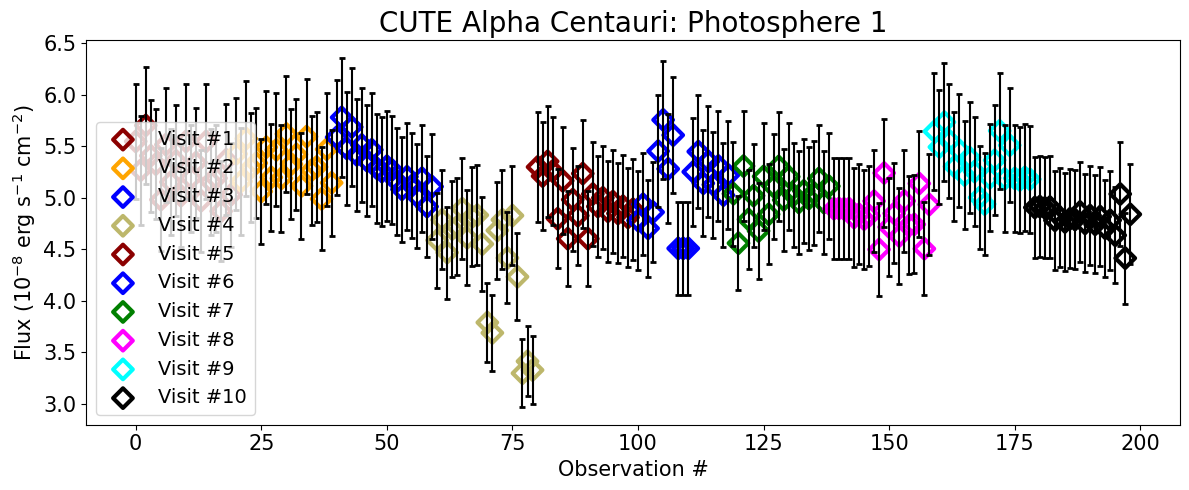

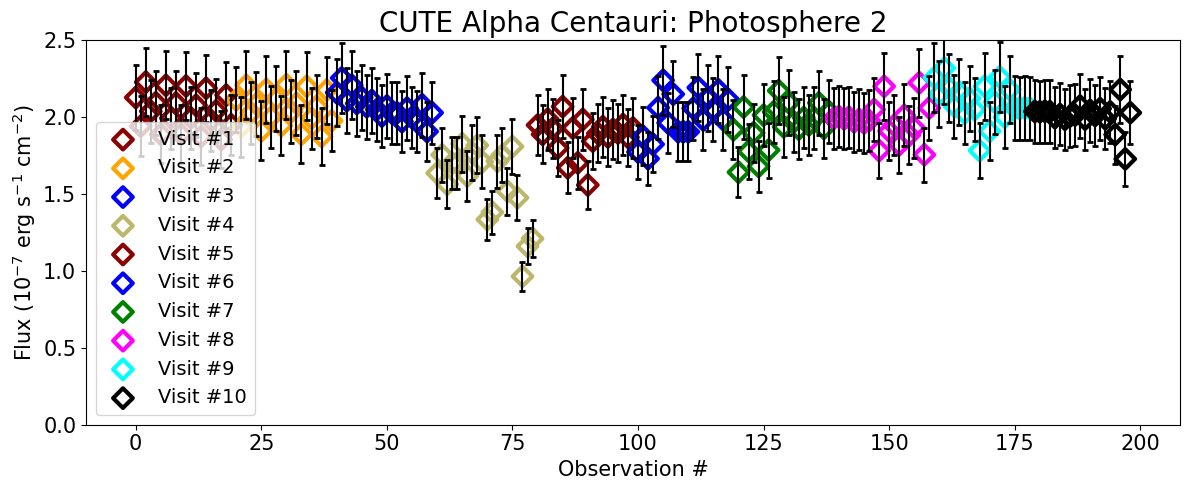

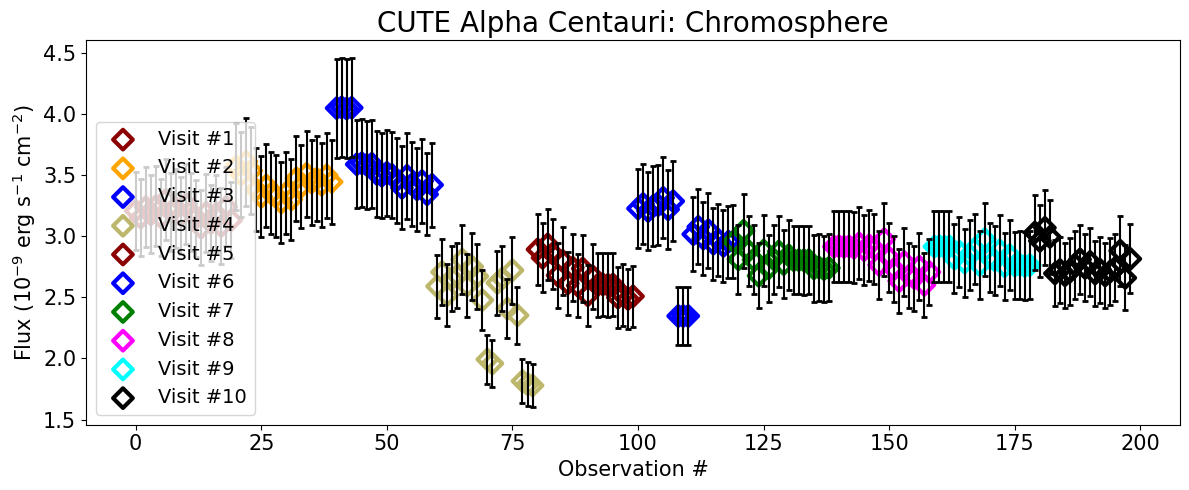

In [23]:
# Combine all dates
alldtstr = np.array([])
alldtstr = np.append(alldtstr, dt1str)
alldtstr = np.append(alldtstr, dt2str)
alldtstr = np.append(alldtstr, dt3str)
alldtstr = np.append(alldtstr, dt4str)
alldtstr = np.append(alldtstr, dt5str)
alldtstr = np.append(alldtstr, dt6str)
alldtstr = np.append(alldtstr, dt7str)
alldtstr = np.append(alldtstr, dt8str)
alldtstr = np.append(alldtstr, dt9str)
alldtstr = np.append(alldtstr, dt10str)

# Combine Photosphere 1 fluxes
allphot1 = np.concatenate((corflux1, corflux2, corflux3, corflux4, corflux5,
                           corflux6, corflux7, corflux8, corflux9, corflux10))
xnum = np.arange(len(allphot1))

nf1, nf2, nf3, nf4, nf5 = nfiles1, nfiles2, nfiles3, nfiles4, nfiles5
nf6, nf7, nf8, nf9, nf10 = nfiles6, nfiles7, nfiles8, nfiles9, nfiles10

# Photosphere 1 plot
fig, ax = plt.subplots(figsize=(12,5))
ax.set_title('CUTE Alpha Centauri: Photosphere 1', fontsize=20)
ax.tick_params(axis='both', which='major', labelsize=15)
ax.set_xlabel('Observation #', fontsize=15)
ax.set_ylabel('Flux (10$^{-8}$ erg s$^{-1}$ cm$^{-2}$)', fontsize=15)
# ax.set_ylim(0,6)

# Scatter & error bars for each visit
visit_colors = ['darkred','orange','blue','darkkhaki','darkred','blue','green','magenta','cyan','black']
visit_offsets = np.cumsum([0, nf1, nf2, nf3, nf4, nf5, nf6, nf7, nf8, nf9])
for i, nf in enumerate([nf1,nf2,nf3,nf4,nf5,nf6,nf7,nf8,nf9,nf10]):
    start = visit_offsets[i]
    end   = visit_offsets[i]+nf
    ax.scatter(xnum[start:end], allphot1[start:end]*1.e8, label=f'Visit #{i+1}',
               marker='D', edgecolors=visit_colors[i], s=100, facecolors='none', linewidths=3)
    ax.errorbar(xnum[start:end], allphot1[start:end]*1.e8, yerr=0.1*allphot1[start:end]*1.e8,
                linestyle='none', capthick=2, capsize=2, color='black')

ax.legend(fontsize=14, loc=3)
fig.tight_layout()
# plt.savefig('/path/to/save/Phot1_fluxCUTE_correctedall_werr_allvisits.jpeg', format='jpeg', dpi=200)
plt.show()

# Similarly, combine and plot Photosphere 2
allphot2 = np.concatenate((corflux12, corflux22, corflux32, corflux42, corflux52,
                           corflux62, corflux72, corflux82, corflux92, corflux102))
xnum = np.arange(len(allphot2))

fig, ax = plt.subplots(figsize=(12,5))
ax.set_title('CUTE Alpha Centauri: Photosphere 2', fontsize=20)
ax.tick_params(axis='both', which='major', labelsize=15)
ax.set_xlabel('Observation #', fontsize=15)
ax.set_ylabel('Flux (10$^{-7}$ erg s$^{-1}$ cm$^{-2}$)', fontsize=15)
ax.set_ylim(0,2.5)

for i, nf in enumerate([nf1,nf2,nf3,nf4,nf5,nf6,nf7,nf8,nf9,nf10]):
    start = visit_offsets[i]
    end   = visit_offsets[i]+nf
    ax.scatter(xnum[start:end], allphot2[start:end]*1.e7, label=f'Visit #{i+1}',
               marker='D', edgecolors=visit_colors[i], s=100, facecolors='none', linewidths=3)
    ax.errorbar(xnum[start:end], allphot2[start:end]*1.e7, yerr=0.1*allphot2[start:end]*1.e7,
                linestyle='none', capthick=2, capsize=2, color='black')

ax.legend(fontsize=14, loc=3)
fig.tight_layout()
# plt.savefig('/path/to/save/Phot2_fluxCUTE_correctedall_werr_allvisits.jpeg', format='jpeg', dpi=200)
plt.show()

# Chromosphere
allchrom = np.concatenate((corflux13, corflux23, corflux33, corflux43, corflux53,
                           corflux63, corflux73, corflux83, corflux93, corflux103))
xnum = np.arange(len(allchrom))

fig, ax = plt.subplots(figsize=(12,5))
ax.set_title('CUTE Alpha Centauri: Chromosphere', fontsize=20)
ax.tick_params(axis='both', which='major', labelsize=15)
ax.set_xlabel('Observation #', fontsize=15)
ax.set_ylabel('Flux (10$^{-9}$ erg s$^{-1}$ cm$^{-2}$)', fontsize=15)
# ax.set_ylim(0,2.5)

for i, nf in enumerate([nf1,nf2,nf3,nf4,nf5,nf6,nf7,nf8,nf9,nf10]):
    start = visit_offsets[i]
    end   = visit_offsets[i]+nf
    ax.scatter(xnum[start:end], allchrom[start:end]*1.e9, label=f'Visit #{i+1}',
               marker='D', edgecolors=visit_colors[i], s=100, facecolors='none', linewidths=3)
    ax.errorbar(xnum[start:end], allchrom[start:end]*1.e9, yerr=0.1*allchrom[start:end]*1.e9,
                linestyle='none', capthick=2, capsize=2, color='black')

ax.legend(fontsize=14, loc=3)
fig.tight_layout()
# plt.savefig('/path/to/save/Chrom_fluxCUTE_correctedall_werr_allvisits.jpeg', format='jpeg', dpi=200)
plt.show()


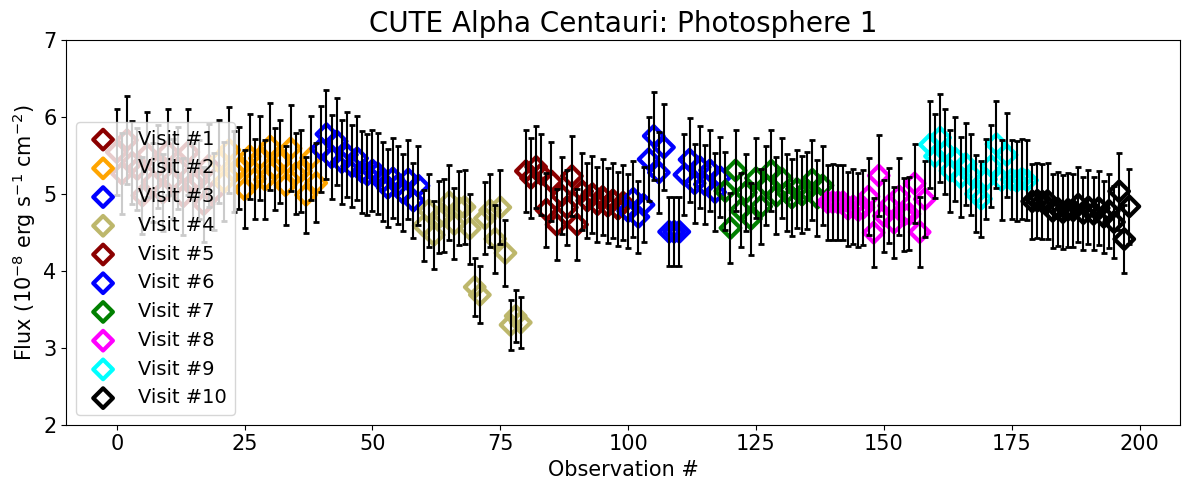

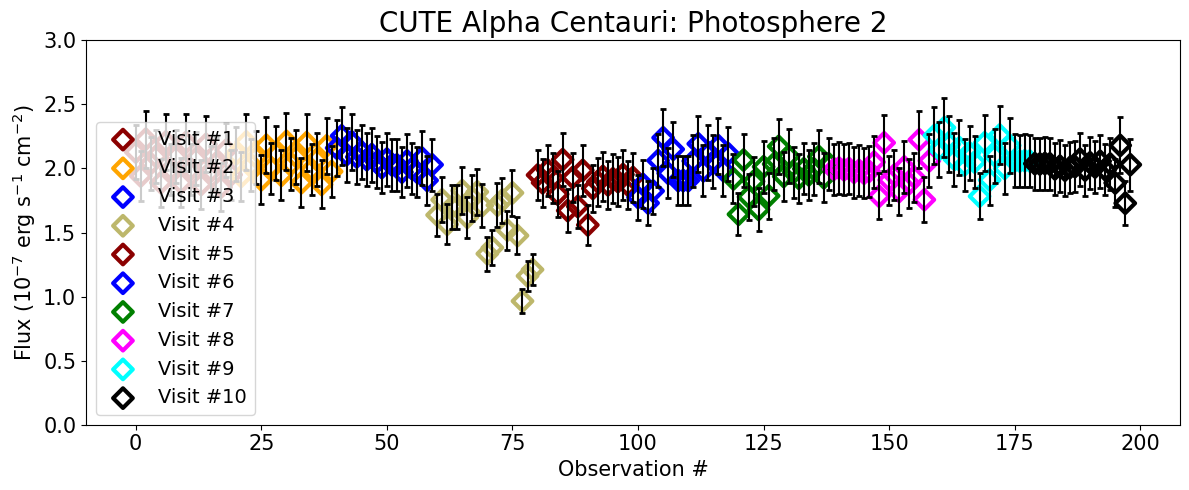

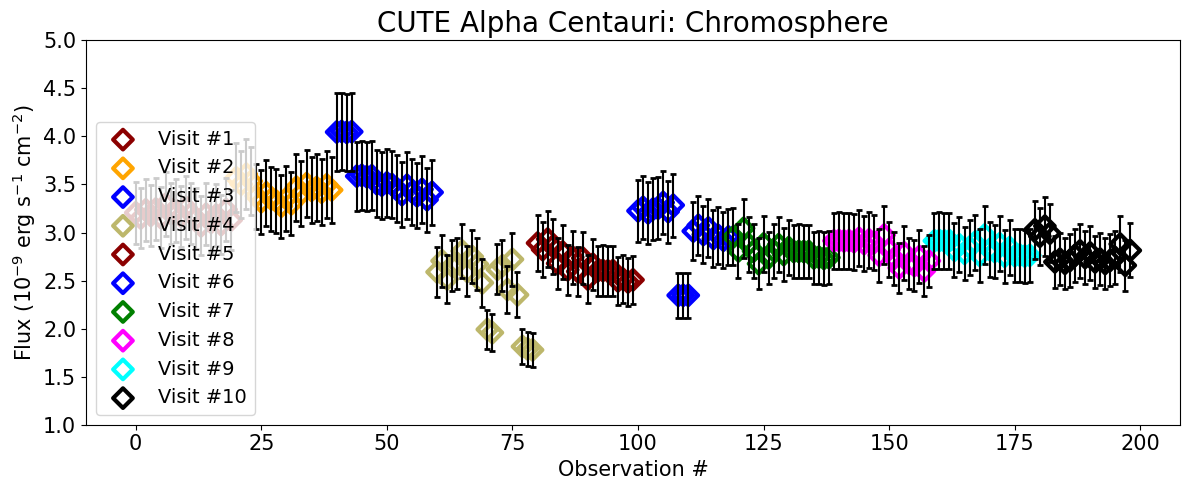

In [24]:
# Combine all dates
alldtstr = []
for dt in [dt1str, dt2str, dt3str, dt4str, dt5str, dt6str, dt7str, dt8str, dt9str, dt10str]:
    alldtstr = np.append(alldtstr, dt)
alldtstr = np.array(alldtstr)

# Combine Photosphere 1 flux
allphot1 = np.concatenate([corflux1, corflux2, corflux3, corflux4, corflux5,
                           corflux6, corflux7, corflux8, corflux9, corflux10])
xnum = np.arange(len(allphot1))

nf = [nfiles1, nfiles2, nfiles3, nfiles4, nfiles5, nfiles6, nfiles7, nfiles8, nfiles9, nfiles10]
visit_colors = ['darkred','orange','blue','darkkhaki','darkred','blue','green','magenta','cyan','black']

# Photosphere 1 plot
fig, ax = plt.subplots(figsize=(12,5))
ax.set_title('CUTE Alpha Centauri: Photosphere 1', fontsize=20)
ax.tick_params(axis='both', which='major', labelsize=15)
ax.set_xlabel('Observation #', fontsize=15)
ax.set_ylabel('Flux (10$^{-8}$ erg s$^{-1}$ cm$^{-2}$)', fontsize=15)
ax.set_ylim(2,7)

offset = 0
for i in range(10):
    ax.scatter(xnum[offset:offset+nf[i]], allphot1[offset:offset+nf[i]]*1e8, label=f'Visit #{i+1}',
               marker='D', edgecolors=visit_colors[i], s=100, facecolors='none', linewidths=3)
    ax.errorbar(xnum[offset:offset+nf[i]], allphot1[offset:offset+nf[i]]*1e8,
                yerr=0.1*allphot1[offset:offset+nf[i]]*1e8, linestyle='none', capthick=2,
                capsize=2, color='black')
    offset += nf[i]

ax.legend(fontsize=14, loc=3)
fig.tight_layout()
# plt.savefig('Phot1_fluxCUTE_correctedall_werr_1to10.jpeg', format='jpeg', dpi=200)
plt.show()

# Photosphere 2 flux
allphot2 = np.concatenate([corflux12, corflux22, corflux32, corflux42, corflux52,
                           corflux62, corflux72, corflux82, corflux92, corflux102])
xnum = np.arange(len(allphot2))

fig, ax = plt.subplots(figsize=(12,5))
ax.set_title('CUTE Alpha Centauri: Photosphere 2', fontsize=20)
ax.tick_params(axis='both', which='major', labelsize=15)
ax.set_xlabel('Observation #', fontsize=15)
ax.set_ylabel('Flux (10$^{-7}$ erg s$^{-1}$ cm$^{-2}$)', fontsize=15)
ax.set_ylim(0,3)

offset = 0
for i in range(10):
    ax.scatter(xnum[offset:offset+nf[i]], allphot2[offset:offset+nf[i]]*1e7, label=f'Visit #{i+1}',
               marker='D', edgecolors=visit_colors[i], s=100, facecolors='none', linewidths=3)
    ax.errorbar(xnum[offset:offset+nf[i]], allphot2[offset:offset+nf[i]]*1e7,
                yerr=0.1*allphot2[offset:offset+nf[i]]*1e7, linestyle='none', capthick=2,
                capsize=2, color='black')
    offset += nf[i]

ax.legend(fontsize=14, loc=3)
fig.tight_layout()
# plt.savefig('Phot2_fluxCUTE_correctedall_werr_1to10.jpeg', format='jpeg', dpi=200)
plt.show()

# Chromosphere flux
allchrom = np.concatenate([corflux13, corflux23, corflux33, corflux43, corflux53,
                           corflux63, corflux73, corflux83, corflux93, corflux103])
xnum = np.arange(len(allchrom))

fig, ax = plt.subplots(figsize=(12,5))
ax.set_title('CUTE Alpha Centauri: Chromosphere', fontsize=20)
ax.tick_params(axis='both', which='major', labelsize=15)
ax.set_xlabel('Observation #', fontsize=15)
ax.set_ylabel('Flux (10$^{-9}$ erg s$^{-1}$ cm$^{-2}$)', fontsize=15)
ax.set_ylim(1,5)

offset = 0
for i in range(10):
    ax.scatter(xnum[offset:offset+nf[i]], allchrom[offset:offset+nf[i]]*1e9, label=f'Visit #{i+1}',
               marker='D', edgecolors=visit_colors[i], s=100, facecolors='none', linewidths=3)
    ax.errorbar(xnum[offset:offset+nf[i]], allchrom[offset:offset+nf[i]]*1e9,
                yerr=0.1*allchrom[offset:offset+nf[i]]*1e9, linestyle='none', capthick=2,
                capsize=2, color='black')
    offset += nf[i]

ax.legend(fontsize=14, loc=3)
fig.tight_layout()
# plt.savefig('Chrom_fluxCUTE_correctedall_werr_1to10.jpeg', format='jpeg', dpi=200)
plt.show()


In [28]:
# from astropy.time import Time
# from astropy.timeseries import LombScargle
# import matplotlib.pyplot as plt
# import numpy as np

# # Combine observation times for all visits (1-10)
# # Combine all dates correctly
# # Make sure all dtXstr are numpy arrays of strings
# all_times = np.concatenate([np.array(dt1str), np.array(dt2str), np.array(dt3str), np.array(dt4str),
#                             np.array(dt5str), np.array(dt6str), np.array(dt7str), np.array(dt8str),
#                             np.array(dt9str), np.array(dt10str)])
# time_mjd = Time(all_times, format='iso').mjd


# # Combine flux arrays for all visits (1-10)
# phot1_flux = np.concatenate([corflux1, corflux2, corflux3, corflux4, corflux5, corflux6, corflux7, corflux8, corflux9, corflux10])
# phot2_flux = np.concatenate([corflux12, corflux22, corflux32, corflux42, corflux52, corflux62, corflux72, corflux82, corflux92, corflux102])
# chrom_flux = np.concatenate([corflux13, corflux23, corflux33, corflux43, corflux53, corflux63, corflux73, corflux83, corflux93, corflux103])

# # Function to plot Lomb-Scargle
# def plot_lomb_scargle(time_mjd, flux, title, yscale=1e8, xmax=40):
#     ls = LombScargle(time_mjd, flux)
#     freq, power = ls.autopower(method='slow')
#     best_period = 1 / freq[np.argmax(power)]

#     plt.figure(figsize=(10,5))
#     plt.plot(1/freq, power, color='blue', lw=2)
#     plt.axvline(best_period, color='red', linestyle='--', label=f'Best Period = {best_period:.2f} days')
#     plt.xlabel('Period [days]', fontsize=15)
#     plt.ylabel('Lomb-Scargle Power', fontsize=15)
#     plt.title(title, fontsize=20)
#     plt.xlim(0, xmax)
#     plt.legend(fontsize=14)
#     plt.grid(True, alpha=0.3)
#     plt.tight_layout()
#     plt.show()
#     return best_period

# # Photosphere 1
# best_period_phot1 = plot_lomb_scargle(time_mjd, phot1_flux, 'Lomb-Scargle: Photosphere 1')

# # Photosphere 2
# best_period_phot2 = plot_lomb_scargle(time_mjd, phot2_flux, 'Lomb-Scargle: Photosphere 2')

# # Chromosphere
# best_period_chrom = plot_lomb_scargle(time_mjd, chrom_flux, 'Lomb-Scargle: Chromosphere')


In [29]:
for i, (dt, flux) in enumerate(zip(
        [dt1str, dt2str, dt3str, dt4str, dt5str, dt6str, dt7str, dt8str, dt9str, dt10str],
        [corflux13, corflux23, corflux33, corflux43, corflux53, corflux63, corflux73, corflux83, corflux93, corflux103]
    )):
    print(f"Visit {i+1}: len(dt)={len(dt)}, len(flux)={len(flux)}")


Visit 1: len(dt)=20, len(flux)=20
Visit 2: len(dt)=20, len(flux)=20
Visit 3: len(dt)=20, len(flux)=20
Visit 4: len(dt)=20, len(flux)=20
Visit 5: len(dt)=20, len(flux)=20
Visit 6: len(dt)=19, len(flux)=19
Visit 7: len(dt)=20, len(flux)=20
Visit 8: len(dt)=20, len(flux)=20
Visit 9: len(dt)=20, len(flux)=20
Visit 10: len(dt)=20, len(flux)=20


In [30]:

]

SyntaxError: unmatched ']' (979061554.py, line 1)

# Plotting my own stuff

In [31]:
from astropy.time import Time

nf1 = nfiles1
nf2 = nfiles2
nf3 = nfiles3
nf4 = nfiles4
nf5 = nfiles5
nf6 = nfiles6
nf7 = nfiles7
nf8 = nfiles8
nf9 = nfiles9
nf10 = nfiles10


alldtstr = []
alldtstr = np.append(alldtstr,dt1str)
alldtstr = np.append(alldtstr,dt2str)
alldtstr = np.append(alldtstr,dt3str)
alldtstr = np.append(alldtstr,dt4str)
alldtstr = np.append(alldtstr,dt5str)
alldtstr = np.append(alldtstr,dt6str)
alldtstr = np.append(alldtstr,dt7str)
alldtstr = np.append(alldtstr,dt8str)
alldtstr = np.append(alldtstr,dt9str)
alldtstr = np.append(alldtstr,dt10str)
alldtstr = np.array(alldtstr)

time_mjd = Time(alldtstr, format='iso').mjd

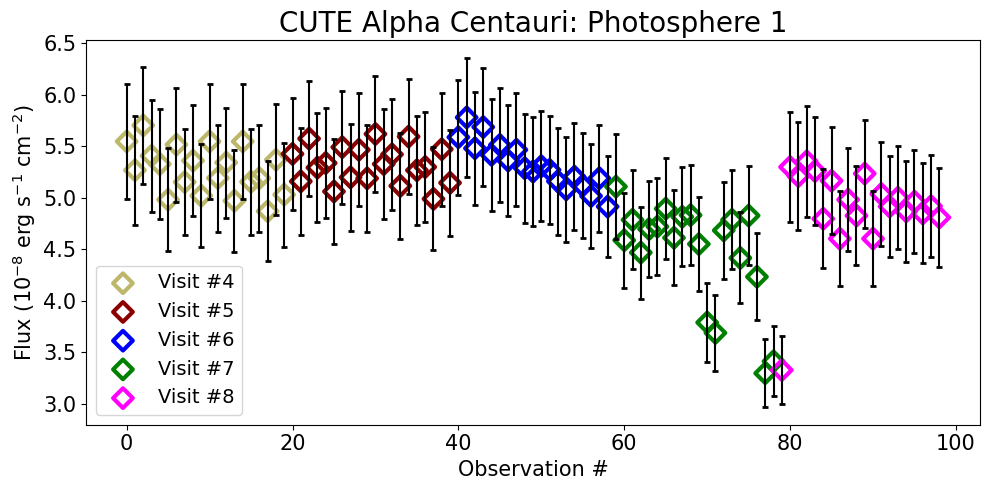

In [32]:
#Photosphere1
fig,ax = plt.subplots(figsize=(10,5))
title  = 'CUTE Alpha Centauri: Photosphere 1'
ax.set_title(title,fontsize=20)
ax.tick_params(axis='both', which='major', labelsize=15)
ax.set_xlabel('Observation #',fontsize=15)
ax.set_ylabel('Flux (10$^{-8}$ erg s$^{-1}$ cm$^{-2}$)',fontsize=15)
# ax.set_ylim(0,6)
ax.scatter(xnum[0:nf4],allphot1[0:nf4]*1.e8, label = 'Visit #4',marker='D',edgecolors='darkkhaki',s=100,facecolors='none',linewidths=3)
ax.errorbar(xnum[0:nf4],allphot1[0:nf4]*1.e8, yerr=0.1*allphot1[0:nf4]*1.e8,linestyle='none',capthick=2,capsize=2,color='black')
ax.scatter(xnum[nf4:nf4+nf5],allphot1[nf4:nf4+nf5]*1.e8, label = 'Visit #5',marker='D',edgecolors='darkred',s=100,facecolors='none',linewidths=3)
ax.errorbar(xnum[nf4:nf4+nf5],allphot1[nf4:nf4+nf5]*1.e8, yerr=0.1*allphot1[nf4:nf4+nf5]*1.e8,linestyle='none',capthick=2,capsize=2,color='black')
ax.scatter(xnum[nf4+nf5:nf4+nf5+nf6],allphot1[nf4+nf5:nf4+nf5+nf6]*1.E8, label = 'Visit #6',marker='D',edgecolors='blue',s=100,facecolors='none',linewidths=3)
ax.errorbar(xnum[nf4+nf5:nf4+nf5+nf6],allphot1[nf4+nf5:nf4+nf5+nf6]*1.e8, yerr=0.1*allphot1[nf4+nf5:nf4+nf5+nf6]*1.e8,linestyle='none',capthick=2,capsize=2,color='black')
ax.scatter(xnum[nf4+nf5+nf6:nf4+nf5+nf6+nf7],allphot1[nf4+nf5+nf6:nf4+nf5+nf6+nf7]*1.E8, label='Visit #7',marker='D',edgecolors='green',s=100,facecolors='none',linewidths=3)
ax.errorbar(xnum[nf4+nf5+nf6:nf4+nf5+nf6+nf7],allphot1[nf4+nf5+nf6:nf4+nf5+nf6+nf7]*1.e8, yerr=0.1*allphot1[nf4+nf5+nf6:nf4+nf5+nf6+nf7]*1.e8,linestyle='none',capthick=2,capsize=2,color='black')
ax.scatter(xnum[nf4+nf5+nf6+nf7:nf4+nf5+nf6+nf7+nf8],allphot1[nf4+nf5+nf6+nf7:nf4+nf5+nf6+nf7+nf8]*1.E8, label='Visit #8',marker='D',edgecolors='magenta',s=100,facecolors='none',linewidths=3)
ax.errorbar(xnum[nf4+nf5+nf6+nf7:nf4+nf5+nf6+nf7+nf8],allphot1[nf4+nf5+nf6+nf7:nf4+nf5+nf6+nf7+nf8]*1.e8, yerr=0.1*allphot1[nf4+nf5+nf6+nf7:nf4+nf5+nf6+nf7+nf8]*1.e8,linestyle='none',capthick=2,capsize=2,color='black')
legend = ax.legend(fontsize=14,loc=3)
fig.tight_layout()



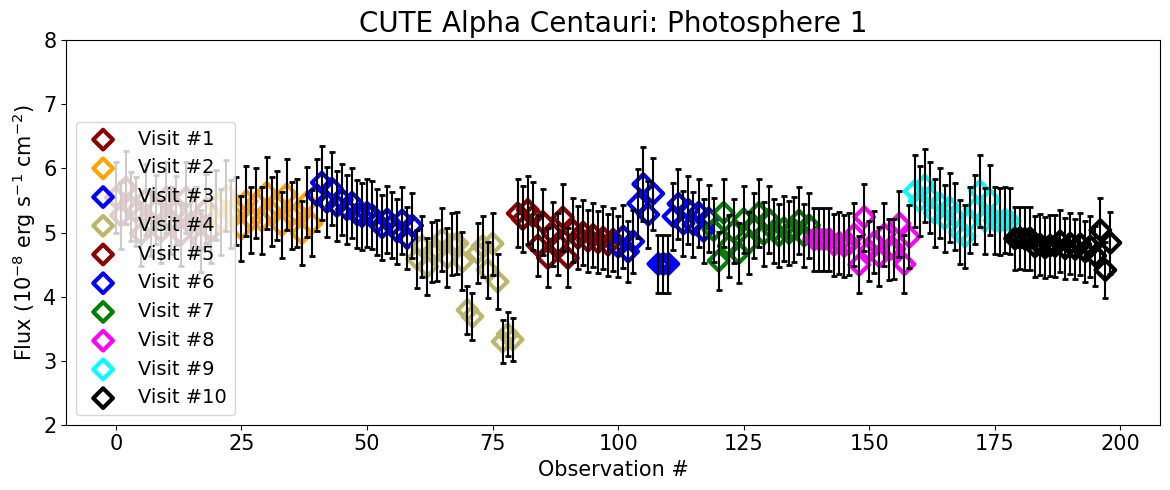

In [33]:
# Combine all phot1 flux if not already done
allphot1 = np.concatenate([corflux1, corflux2, corflux3, corflux4, corflux5,
                           corflux6, corflux7, corflux8, corflux9, corflux10])
xnum = np.arange(len(allphot1))

# Number of files per visit
nf = [nfiles1, nfiles2, nfiles3, nfiles4, nfiles5,
      nfiles6, nfiles7, nfiles8, nfiles9, nfiles10]

# Colors for visits
visit_colors = ['darkred','orange','blue','darkkhaki','darkred',
                'blue','green','magenta','cyan','black']

# Photosphere 1 plot for all visits
fig, ax = plt.subplots(figsize=(12,5))
ax.set_title('CUTE Alpha Centauri: Photosphere 1', fontsize=20)
ax.tick_params(axis='both', which='major', labelsize=15)
ax.set_xlabel('Observation #', fontsize=15)
ax.set_ylabel('Flux (10$^{-8}$ erg s$^{-1}$ cm$^{-2}$)', fontsize=15)
# ax.set_ylim(0,20)  # Uncomment and adjust if needed

offset = 0
for i in range(10):
    ax.scatter(xnum[offset:offset+nf[i]], allphot1[offset:offset+nf[i]]*1e8,
               label=f'Visit #{i+1}', marker='D', edgecolors=visit_colors[i],
               s=100, facecolors='none', linewidths=3)
    ax.errorbar(xnum[offset:offset+nf[i]], allphot1[offset:offset+nf[i]]*1e8,
                yerr=0.1*allphot1[offset:offset+nf[i]]*1e8, linestyle='none',
                capthick=2, capsize=2, color='black')
    offset += nf[i]

ax.legend(fontsize=14, loc=3)
fig.tight_layout()
plt.ylim(2,8)
plt.show()


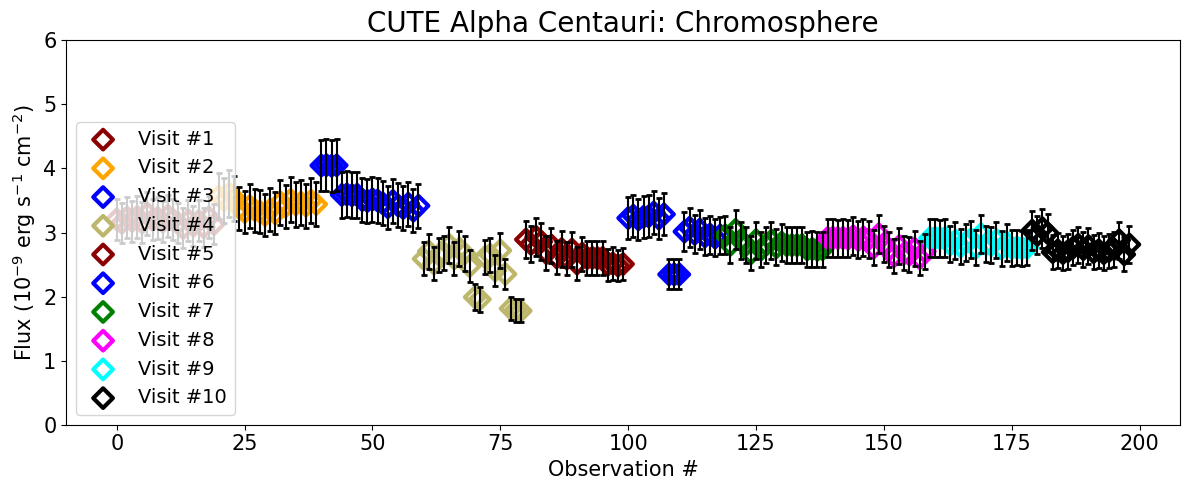

In [34]:
# Combine all chromosphere flux for 10 visits
allchrom = np.concatenate([corflux13, corflux23, corflux33, corflux43, corflux53,
                           corflux63, corflux73, corflux83, corflux93, corflux103])
xnum = np.arange(len(allchrom))

# Number of files per visit
nf = [nfiles1, nfiles2, nfiles3, nfiles4, nfiles5,
      nfiles6, nfiles7, nfiles8, nfiles9, nfiles10]

# Colors for each visit
visit_colors = ['darkred','orange','blue','darkkhaki','darkred',
                'blue','green','magenta','cyan','black']

# Chromosphere plot
fig, ax = plt.subplots(figsize=(12,5))
ax.set_title('CUTE Alpha Centauri: Chromosphere', fontsize=20)
ax.tick_params(axis='both', which='major', labelsize=15)
ax.set_xlabel('Observation #', fontsize=15)
ax.set_ylabel('Flux (10$^{-9}$ erg s$^{-1}$ cm$^{-2}$)', fontsize=15)
ax.set_ylim(0, 6)  # adjust if needed

offset = 0
for i in range(10):
    ax.scatter(xnum[offset:offset+nf[i]], allchrom[offset:offset+nf[i]]*1e9,
               label=f'Visit #{i+1}', marker='D', edgecolors=visit_colors[i],
               s=100, facecolors='none', linewidths=3)
    ax.errorbar(xnum[offset:offset+nf[i]], allchrom[offset:offset+nf[i]]*1e9,
                yerr=0.1*allchrom[offset:offset+nf[i]]*1e9, linestyle='none',
                capthick=2, capsize=2, color='black')
    offset += nf[i]

ax.legend(fontsize=14, loc=3)
fig.tight_layout()
# figname = '/Users/dobh6980/Projects/Kevin_projects/CUTE/Alpha_Cen/plots/Chrom_fluxCUTE_correctedall_werr2.jpeg'
# plt.savefig(figname, format='jpeg', dpi=200)
plt.show()


4.62625227686658


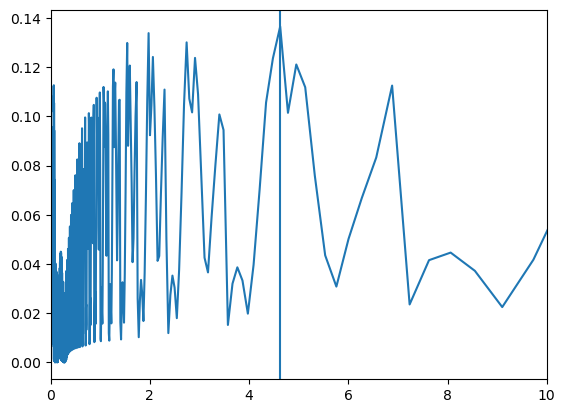

In [39]:
from astropy.timeseries import LombScargle

ls = LombScargle((time_mjd) , allchrom)
freq , power =ls.autopower(method='slow')

best_period = 1/freq[np.argmax(power)]
plt.axvline(best_period)
plt.plot(1/freq, power)
plt.xlim(0,10)

print(best_period)

In [43]:
from astropy.time import Time

def to_mjd(dt_array):
    """Convert byte-string datetime array from .sav into float MJD."""
    # decode bytes to regular strings
    decoded = [d.decode('utf-8') if isinstance(d, (bytes, bytearray)) else d for d in dt_array]
    # convert to MJD
    t = Time(decoded, format='isot', scale='utc')
    return t.mjd

# Convert all visits
t1 = to_mjd(dt_arr1)
t2 = to_mjd(dt_arr2)
t3 = to_mjd(dt_arr3)
t4 = to_mjd(dt_arr4)
t5 = to_mjd(dt_arr5)
t6 = to_mjd(dt_arr6)
t7 = to_mjd(dt_arr7)
t8 = to_mjd(dt_arr8)
t9 = to_mjd(dt_arr9)
t10 = to_mjd(dt_arr10)


In [44]:
import numpy as np

time_all = np.concatenate([t1, t2, t3, t4, t5, t6, t7, t8, t9, t10])

print("Combined array length:", len(time_all))
print("Is sorted:", np.all(np.diff(time_all) > 0))
print("Total time span:", np.min(time_all), "→", np.max(time_all),
      f"({np.max(time_all) - np.min(time_all):.1f} days)")

if not np.all(np.diff(time_all) > 0):
    disorder = np.where(np.diff(time_all) < 0)[0]
    print("⚠️ Disorder detected at indices:", disorder[:5])
    print("Values around first disorder:")
    print(time_all[disorder[0]-2:disorder[0]+3])






Combined array length: 199
Is sorted: True
Total time span: 60792.24086805555 → 60855.5327662037 (63.3 days)


(Filtered) Best period ALL visits: 31.93 days
(Filtered) Best period Visits 5–10: 15.46 days


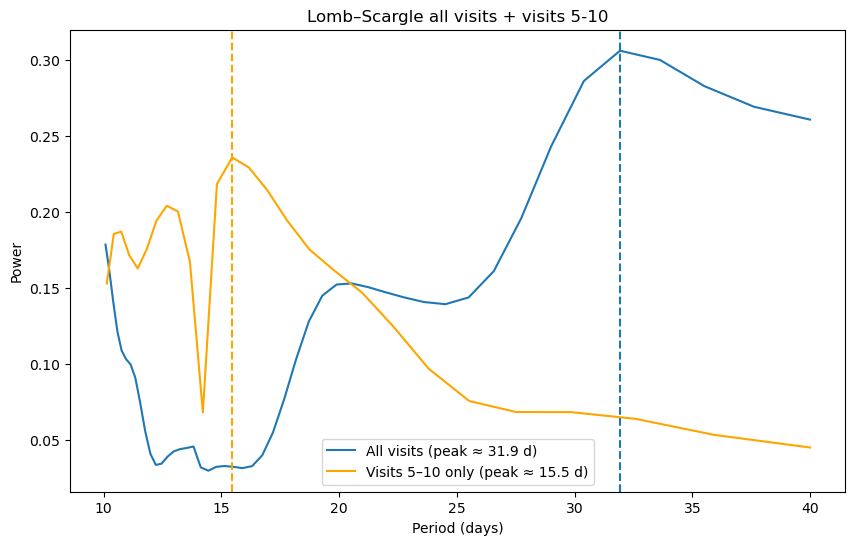

In [45]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.timeseries import LombScargle

# Arrays (same as before)
flux_all = np.array(allchrom)


# Trimmed arrays (Visits 5–10)
trim_start = 80
flux_trim = flux_all[trim_start:]
time_trim = time_all[trim_start:]

# New frequency limits (exclude 5–10 day region)
min_freq = 1/40     # 40 days
max_freq = 1/10     # 12 days

# LS on all data
ls_all = LombScargle(time_all, flux_all)
freq_all, power_all = ls_all.autopower(
    minimum_frequency=min_freq,
    maximum_frequency=max_freq,
    samples_per_peak=10
)
best_period_all = 1 / freq_all[np.argmax(power_all)]
print(f"(Filtered) Best period ALL visits: {best_period_all:.2f} days")

# LS on trimmed data
ls_trim = LombScargle(time_trim, flux_trim)
freq_trim, power_trim = ls_trim.autopower(
    minimum_frequency=min_freq,
    maximum_frequency=max_freq,
    samples_per_peak=10
)
best_period_trim = 1 / freq_trim[np.argmax(power_trim)]
print(f"(Filtered) Best period Visits 5–10: {best_period_trim:.2f} days")

# Plot comparison
plt.figure(figsize=(10,6))
plt.plot(1/freq_all, power_all, label=f"All visits (peak ≈ {best_period_all:.1f} d)")
plt.plot(1/freq_trim, power_trim,label=f"Visits 5–10 only (peak ≈ {best_period_trim:.1f} d)", color='orange')

plt.axvline(best_period_all, ls='--', alpha=1)
plt.axvline(best_period_trim, ls='--', alpha=1 , color='orange')

plt.xlabel("Period (days)")
plt.ylabel("Power")
plt.title("Lomb–Scargle all visits + visits 5-10")
plt.legend()
plt.show()
